# Advanced Feature Engineering for People Analytics

A comprehensive, production-grade guide to designing, implementing, and visualizing 50 advanced mathematical and machine learning features for workforce intelligence and People Analytics systems.

---

## Structure of this Tutorial

This tutorial organizes 50 advanced features across 11 problem-driven pillars:

1. **Handling High Cardinality & Hierarchical Impact**:
   - Feature 1: Bayesian Target Encoding (Empirical Bayes Shrinkage)
   - Feature 2: Grouped Leave-One-Out (LOO) Z-Scores
   - Feature 3: Leave-One-Out Expected Differential (LOO-ED)

2. **Preserving Memory, Lifecycles & Time Decay**:
   - Feature 4: Fractional Differencing
   - Feature 5: Weighted Weeks Since (Continuous Event-Decay Features)
   - Feature 6: Exponentially Weighted Moving Average (EWMA) & Moving Sum (EWMS for Count Data)
   - Feature 7: Double & Triple Exponential Smoothing (Holt-Winters Trend & Seasonality)
   - Feature 8: Kaplan-Meier & Nelson-Aalen Hazard Embeddings
   - Feature 9: Configuration-Driven Rolling Metrics (Multi-Horizon Cohort Pipelines)
   - Feature 10: Singular Spectrum Analysis (SVD Smoothing & Lag-Free Baselines)
   - Feature 11: Hierarchical Lag & Autoregressive Features
   - Feature 12: Multi-Horizon Differencing & Growth Rates (YoY, MoM, WoW & % Change)

3. **Capturing Chaos, Volatility & Regimes**:
   - Feature 13: Rolling Shannon Entropy (The Chaos Index)
   - Feature 14: GARCH(1,1) Dynamic Volatility Index
   - Feature 15: Hawkes Process Intensity (The Contagion Feature)
   - Feature 16: Hidden Markov Model (HMM) Latent States
   - Feature 17: The Bradford Factor (Absenteeism Friction Score & Schedule Disruption)

4. **Detecting Structural Anomalies, Density & Sequences**:
   - Feature 18: Autoencoder Reconstruction Error (The Weirdness Index)
   - Feature 19: Local Outlier Factor (LOF via PyOD)
   - Feature 20: Kullback-Leibler (KL) Divergence (The Drift Index)
   - Feature 21: Dynamic Time Warping (DTW) Distance
   - Feature 22: Longest Common Subsequence (LCSS) & Edit Distance on Real Sequences (EDR)
   - Feature 50: Multivariate Mahalanobis Distance (Covariance-Scaled Anomaly Detection & Chi-Squared Outliers)

5. **Attribution, Interactions & Accounting**:
   - Feature 23: Log-Mean Decomposition (LMDI-I)
   - Feature 24: SHAP Interaction Values (2D Non-Linear Feature Interactions)
   - Feature 25: Correlation Heatmap Table (Pearson, Spearman, Kendall with CIs & p-values)

6. **Career Mobility, Succession & Behavioral Tipping Points**:
   - Feature 26: Movement Embeddings (Career Trajectory & Graph Embeddings)
   - Feature 27: SHAP Inflection Thresholds for Term Rates (Zero-Crossing Behavioral Tipping Points)
   - Feature 28: Time-in-Position (The Stagnation Index & Flight Risk Surge)

7. **Compensation and Pay Equity Transformations**:
   - Feature 29: Compa-Ratio (Midpoint and Market Parity)
   - Feature 30: Range Penetration (Band Progression & Red/Green Circled Status)

8. **Relational Dynamics, Structural Capital & Organizational Network Analysis (ONA)**:
   - Feature 31: Betweenness Centrality (Cross-Functional Brokers)
   - Feature 32: Eigenvector Centrality (Informal Knowledge Hubs)
   - Feature 33: Ronald Burt's Network Constraint Index (Structural Holes & Redundancy)
   - Feature 34: Euler Centrality & Leinster Magnitude (Global Structural Capital)
   - Feature 35: Span of Control (Managerial Load & Reorganization Flight Risk)

9. **Algorithmic Equity, Pay Decomposition & Individual Fairness**:
   - Feature 36: Oaxaca-Blinder Pay Gap Decomposition (Explained vs Unexplained Returns)
   - Feature 37: Demographic Parity Difference & Ratio (Macro Selection Equality)
   - Feature 38: Equalized Odds Constraint via Exponentiated Gradient Reduction
   - Feature 39: Individual Fairness & Local Predictive Consistency (Lipschitz Concordance)

10. **Prescriptive Interventions: Causal Inference & Heterogeneous Uplift**:
   - Feature 40: Augmented Inverse Propensity Weighting (AIPW Doubly Robust ATE)
   - Feature 41: Synthetic Difference-in-Differences (SDiD Panel Policy Evaluation)
   - Feature 42: Causal Forest with Double Machine Learning (CausalForestDML & Honest Splitting)
   - Feature 43: Prescriptive Uplift Evaluation (Qini Curve, AUUC, and Doubly Robust MSE_W)
   - Feature 44: Synthetic Control Weights (Synth-DiD Synthetic Twin & Causal Lift)
   - Feature 45: Directed Causal Edge Weights (DAG Discovery & Confounder Untangling)

11. **Continuous-Time Trajectories & Heterogeneous Graph Representation Learning**:
   - Feature 46: Continuous-Time Markov Chain (CTMC) Career Trajectories & Matrix Exponential
   - Feature 47: Meta-Path Biased Random Walks on Heterogeneous Multigraphs
   - Feature 48: Metapath2Vec Graph Representation Learning & Complementarity
   - Feature 49: Dynamic Entity & Trajectory Self-Attention Aggregator

---

## Global Setup and Imports

In [1]:
import sys
import os
from pathlib import Path

# Add project root to sys.path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Curated Enterprise Color Palette
PALETTE = {
    'lilac': '#8b7cbf',       # Medium soft purple/violet
    'light_blue': '#7db8f8',  # Crisp coastal sky blue
    'royal_blue': '#2b6cb0',  # Deep enterprise royal blue
    'light_orange': '#f89c25',# Warm golden amber
    'salmon': '#f4633a',      # Warm reddish-orange coral
    'sage_green': '#81a554',  # Earthy muted olive/green
    'dark_slate': '#2d3748',  # Deep neutral slate for text/benchmarks
    'muted_gray': '#718096',  # Subtle neutral gray
}
PALETTE_LIST = [PALETTE['light_blue'], PALETTE['salmon'], PALETTE['sage_green'], PALETTE['light_orange'], PALETTE['lilac']]

# Aesthetic formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.autolayout'] = True
sns.set_palette(PALETTE_LIST)

import warnings
warnings.filterwarnings('ignore')

# Import synthetic generators and custom feature modules
from data.synthetic_generators import (
    generate_store_roster_data,
    generate_cohort_timeseries_overtime,
    generate_shift_manager_performance,
    generate_headcount_timeseries,
    generate_rewards_timeseries,
    generate_labor_hours_traffic,
    generate_shift_schedules,
    generate_callout_events,
    generate_regime_workforce_timeseries,
    generate_store_profiles_multivariate,
    generate_compensation_velocity_data,
    generate_role_distributions,
    generate_seasonal_curves,
    generate_career_shift_sequences,
    generate_enterprise_turnover_breakdown,
    generate_safety_incident_dataset,
    generate_career_movement_dataset,
    generate_turnover_inflection_dataset,
    generate_compensation_equity_data,
    generate_seasonal_workforce_timeseries,
    generate_organizational_network_data,
    generate_algorithmic_equity_and_fairness_data,
    generate_causal_and_uplift_data,
    generate_panel_policy_data,
    generate_retail_scheduling_pilot_data,
    generate_overtime_turnover_causal_dag_data,
    generate_career_trajectory_event_log,
    generate_heterogeneous_hcm_multigraph,
    generate_reporting_hierarchy_with_reorg,
)

from people_analytics_toolkit.cardinality import BayesianTargetEncoder, GroupedLOOZScore
from people_analytics_toolkit.memory import (
    fractional_difference,
    scan_fractional_differencing,
    weighted_weeks_since,
    calculate_ewma,
    calculate_ewms,
    calculate_poisson_ewma,
    double_exponential_smoothing,
    triple_exponential_smoothing,
    fit_hazard_embeddings,
)
from people_analytics_toolkit.compensation import (
    calculate_compa_ratio,
    calculate_range_penetration,
    classify_pay_band_status,
    is_red_circled,
    is_green_circled,
)
from people_analytics_toolkit.ona import (
    calculate_betweenness_centrality,
    calculate_eigenvector_centrality,
    calculate_burt_constraint,
    calculate_euler_centrality,
    calculate_collaboration_overload,
    simulate_attrition_contagion,
    compute_complete_ona_profile,
    calculate_span_of_control,
    evaluate_span_reorganization_shock,
)
from people_analytics_toolkit.equity import (
    oaxaca_blinder_decomposition,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    ExponentiatedGradientFairness,
    calculate_individual_fairness_consistency,
)
from people_analytics_toolkit.prescriptive import (
    aipw_estimator,
    synthetic_difference_in_differences,
    HonestCausalTree,
    CausalForestDML,
    qini_curve,
    area_under_uplift_curve,
    doubly_robust_uplift_eval,
    compute_synthetic_control_weights,
    build_synthetic_control_twin,
    build_multi_pilot_synthetic_controls,
    notears_linear,
    compute_directed_causal_edge_weights,
    diagnose_causal_confounding,
)
from people_analytics_toolkit.trajectories import (
    ContinuousTimeMarkovChain,
    generate_metapath_walks,
    Metapath2Vec,
    DynamicEntitySelfAttention,
)
import networkx as nx
from people_analytics_toolkit.chaos import (
    calculate_shannon_entropy,
    rolling_shannon_entropy,
    fit_garch_volatility,
    HawkesProcessContagion,
    fit_workforce_hmm_regimes,
)
from people_analytics_toolkit.anomalies import (
    calculate_kl_divergence,
    calculate_jensen_shannon_divergence,
    compute_dtw_distance,
    compute_lcss_distance,
    compute_edr_distance,
    AutoencoderWeirdnessDetector,
    fit_pyod_local_outlier_factor,
    calculate_mahalanobis_distance,
)
from people_analytics_toolkit.attribution import (
    lmdi_rate_mix_decomposition,
    LeaveOneOutExpectedDifferential,
    compute_shap_interaction_matrix,
    extract_shap_inflection_thresholds,
    calculate_retained_vs_terminated_shap_contributions,
)
from people_analytics_toolkit.mobility import CareerMovementEmbeddings

print('System initialized successfully. All feature modules imported.')

System initialized successfully. All feature modules imported.


# Part 1: Handling High Cardinality & Hierarchical Impact

Enterprise workforces are deeply hierarchical: enterprise, region, store, department, shift, and employee. High-cardinality interaction terms (e.g. `STORE_ID x DEPT_CODE`) create sparse matrices and small sample sizes. Localized cohort evaluation suffers when extreme outliers distort their own benchmark statistics. Furthermore, judging managers on raw shift metrics conflates shift advantages (e.g. prime Saturday airport traffic) with true managerial impact.

---

### Feature 1: Bayesian Target Encoding (Empirical Bayes Shrinkage)

#### The Concept
Replaces high-cardinality labels with smoothed expected target values, shrinking small cohorts ($n_i \to 0$) toward the enterprise baseline $\bar{y}_{\text{global}}$ while allowing large cohorts ($n_i \to \infty$) to reflect their empirical rates:

$$\hat{S}_i = \frac{n_i \cdot \bar{y}_i + m \cdot \bar{y}_{\text{global}}}{n_i + m}$$

Out-of-fold (K-Fold) estimation prevents target leakage.

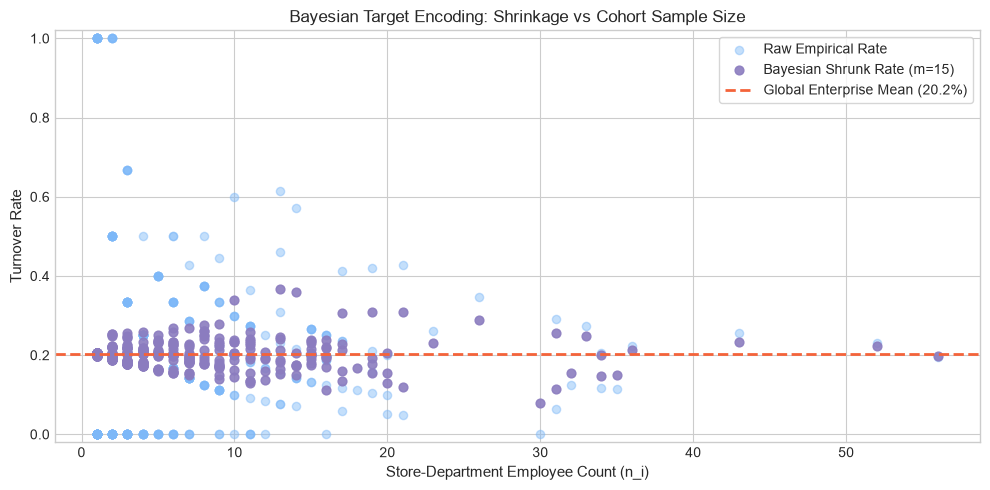

In [2]:
roster_df = generate_store_roster_data(n_employees=2500, n_stores=50, n_depts=8, seed=42)
bte = BayesianTargetEncoder(m=15.0, cv_folds=5, seed=42)
roster_df['turnover_encoded_oof'] = bte.fit_transform_oof(roster_df, group_col='store_dept', target_col='turnover_event')

cat_summary = roster_df.groupby('store_dept').agg(
    sample_size=('turnover_event', 'count'),
    raw_turnover_rate=('turnover_event', 'mean'),
    shrunk_turnover_rate=('turnover_encoded_oof', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(cat_summary['sample_size'], cat_summary['raw_turnover_rate'], alpha=0.45, color=PALETTE['light_blue'], label='Raw Empirical Rate', s=35)
ax.scatter(cat_summary['sample_size'], cat_summary['shrunk_turnover_rate'], alpha=0.90, color=PALETTE['lilac'], label='Bayesian Shrunk Rate (m=15)', s=40)
ax.axhline(bte.global_mean_, color=PALETTE['salmon'], linestyle='--', linewidth=2, label=f'Global Enterprise Mean ({bte.global_mean_:.1%})')
ax.set_title('Bayesian Target Encoding: Shrinkage vs Cohort Sample Size')
ax.set_xlabel('Store-Department Employee Count (n_i)')
ax.set_ylabel('Turnover Rate')
ax.set_ylim(-0.02, 1.02)
ax.legend(frameon=True)
plt.show()

### Feature 2: Grouped Leave-One-Out (LOO) Z-Scores

#### The Concept
A severe outlier inflates the cohort mean and standard deviation, masking its own severity in small teams. LOO Z-Scores calculate cohort statistics excluding the target observation:

$$\mu_{-i} = \frac{N \bar{x} - x_i}{N - 1}, \quad \sigma_{-i} = \sqrt{ \frac{\sum_{j \neq i} (x_j - \mu_{-i})^2}{N - 2} }, \quad Z_{\text{LOO}, i} = \frac{x_i - \mu_{-i}}{\max(\sigma_{-i}, \epsilon)}$$

We also compute a 4-week rolling average of the LOO Z-Score to isolate sustained high-fatigue trends from transient weekly fluctuations.

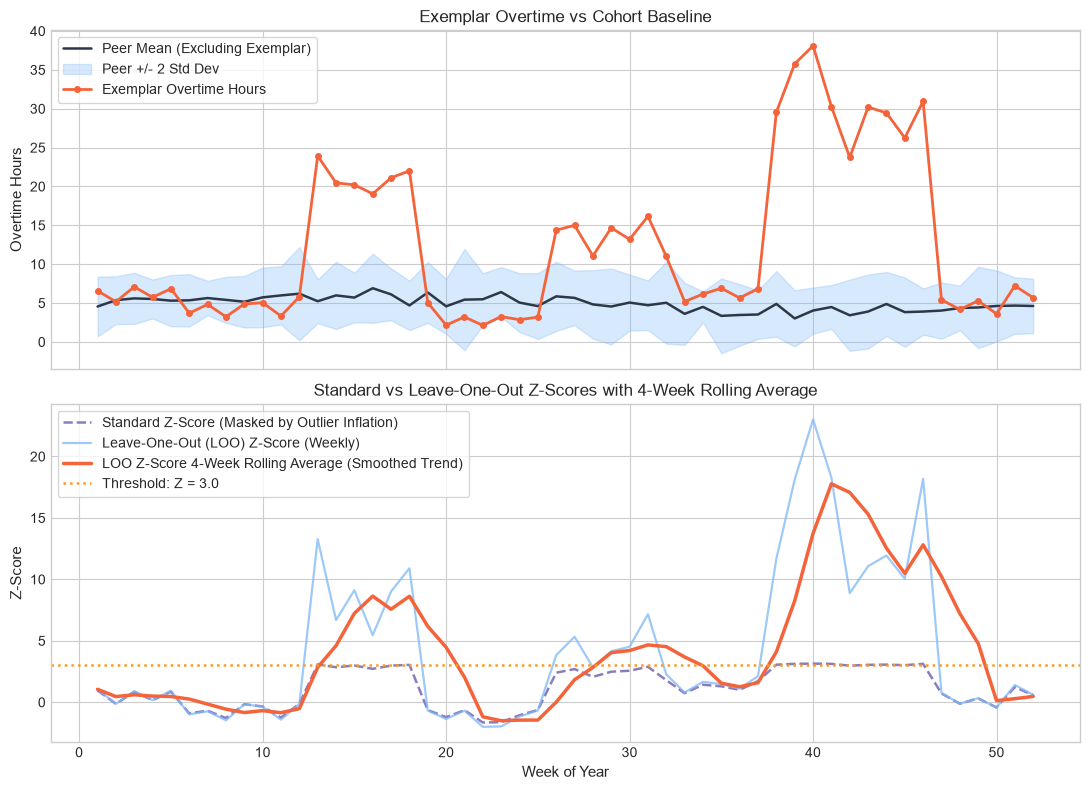

In [3]:
cohort_ts = generate_cohort_timeseries_overtime(n_weeks=52, cohort_size=12, seed=42)
scored_cohort = GroupedLOOZScore.compute(cohort_ts, group_col='week', val_col='overtime_hours', min_cohort_size=3)
exemplar_df = scored_cohort[scored_cohort['is_exemplar'] == 1].sort_values('week')
exemplar_df['loo_z_score_rolling4'] = exemplar_df['loo_z_score'].rolling(4, min_periods=1).mean()
peer_summary = scored_cohort[scored_cohort['is_exemplar'] == 0].groupby('week')['overtime_hours'].agg(['mean', 'std']).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8.0), sharex=True)
ax1.plot(peer_summary['week'], peer_summary['mean'], color=PALETTE['dark_slate'], label='Peer Mean (Excluding Exemplar)', linewidth=1.8)
ax1.fill_between(peer_summary['week'], peer_summary['mean'] - 2 * peer_summary['std'], peer_summary['mean'] + 2 * peer_summary['std'], color=PALETTE['light_blue'], alpha=0.30, label='Peer +/- 2 Std Dev')
ax1.plot(exemplar_df['week'], exemplar_df['overtime_hours'], color=PALETTE['salmon'], marker='o', markersize=4, label='Exemplar Overtime Hours', linewidth=2.0)
ax1.set_ylabel('Overtime Hours')
ax1.set_title('Exemplar Overtime vs Cohort Baseline')
ax1.legend(loc='upper left', frameon=True)

ax2.plot(exemplar_df['week'], exemplar_df['standard_z_score'], color=PALETTE['lilac'], linestyle='--', linewidth=1.8, label='Standard Z-Score (Masked by Outlier Inflation)')
ax2.plot(exemplar_df['week'], exemplar_df['loo_z_score'], color=PALETTE['light_blue'], linewidth=1.6, alpha=0.75, label='Leave-One-Out (LOO) Z-Score (Weekly)')
ax2.plot(exemplar_df['week'], exemplar_df['loo_z_score_rolling4'], color=PALETTE['salmon'], linewidth=2.5, label='LOO Z-Score 4-Week Rolling Average (Smoothed Trend)')
ax2.axhline(3.0, color=PALETTE['light_orange'], linestyle=':', linewidth=1.8, label='Threshold: Z = 3.0')
ax2.set_xlabel('Week of Year')
ax2.set_ylabel('Z-Score')
ax2.set_title('Standard vs Leave-One-Out Z-Scores with 4-Week Rolling Average')
ax2.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### Feature 3: Leave-One-Out Expected Differential (LOO-ED)

#### The Concept
Adapted from sports analytics (Expected Goal Differential / xGD). Raw manager metrics (e.g. shift throughput or turnover) conflate shift advantages (e.g. airport flagship locations or busy weekend foot traffic) with true managerial capability.

LOO-ED trains a counterfactual expectation model predicting output solely from external context (store type, staffing hours, day of week, foot traffic):

$$\text{LOO-ED}_{s, m} = y_s - \hat{y}_s^{\text{counterfactual}}$$

A manager's aggregate LOO-ED isolates pure 'on-floor vs off-floor' managerial alpha, stripping away systemic assignment noise.

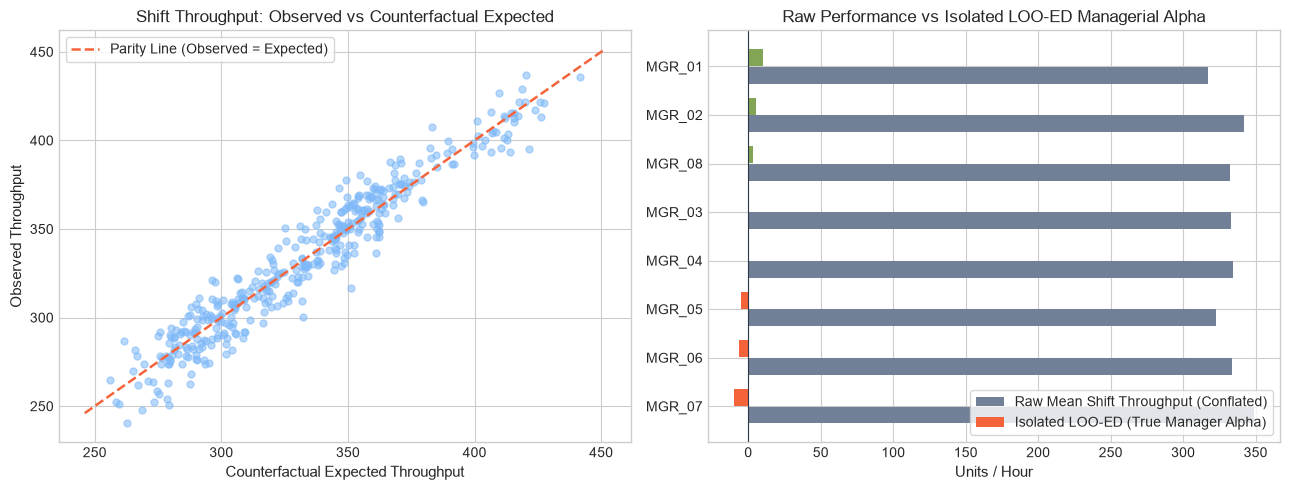

Manager Ranking by Pure Marginal Alpha (LOO-ED):
manager_id  shifts_managed  raw_mean_output  expected_mean_output  loo_expected_differential
    MGR_01              77       317.457143            307.603761                   9.853382
    MGR_02              42       341.809524            336.296878                   5.512646
    MGR_08              44       332.470455            329.232286                   3.238169
    MGR_03              46       333.332609            332.932155                   0.400454
    MGR_04              45       334.244444            334.122380                   0.122064
    MGR_05              31       322.990323            328.056551                  -5.066228
    MGR_06              45       333.960000            340.622604                  -6.662604
    MGR_07              70       348.867143            358.863778                  -9.996635


In [4]:
shift_data = generate_shift_manager_performance(n_shifts=400, n_managers=8, seed=42)
loo_ed_model = LeaveOneOutExpectedDifferential(ridge_alpha=1.0)
scored_shifts, mgr_summary = loo_ed_model.fit_transform(
    shift_data,
    entity_col='manager_id',
    target_col='observed_throughput',
    context_cols=['store_id', 'is_weekend', 'foot_traffic', 'staff_hours']
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Observed vs Counterfactual Expected Scatter
ax1.scatter(scored_shifts['expected_output_counterfactual'], scored_shifts['observed_throughput'], color=PALETTE['light_blue'], alpha=0.55, s=25)
lims = [scored_shifts['expected_output_counterfactual'].min() - 10, scored_shifts['expected_output_counterfactual'].max() + 10]
ax1.plot(lims, lims, color=PALETTE['salmon'], linestyle='--', linewidth=1.8, label='Parity Line (Observed = Expected)')
ax1.set_title('Shift Throughput: Observed vs Counterfactual Expected')
ax1.set_xlabel('Counterfactual Expected Throughput')
ax1.set_ylabel('Observed Throughput')
ax1.legend(frameon=True)

# Panel 2: Raw Output vs Isolated Manager Alpha (LOO-ED)
mgr_plot = mgr_summary.sort_values('loo_expected_differential')
y_pos = np.arange(len(mgr_plot))
ax2.barh(y_pos - 0.18, mgr_plot['raw_mean_output'], height=0.35, color=PALETTE['muted_gray'], label='Raw Mean Shift Throughput (Conflated)')
loo_colors = [PALETTE['salmon'] if x < 0 else PALETTE['sage_green'] for x in mgr_plot['loo_expected_differential']]
ax2.barh(y_pos + 0.18, mgr_plot['loo_expected_differential'], height=0.35, color=loo_colors, label='Isolated LOO-ED (True Manager Alpha)')
ax2.axvline(0, color=PALETTE['dark_slate'], linewidth=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(mgr_plot['manager_id'])
ax2.set_title('Raw Performance vs Isolated LOO-ED Managerial Alpha')
ax2.set_xlabel('Units / Hour')
ax2.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()
print('Manager Ranking by Pure Marginal Alpha (LOO-ED):')
print(mgr_summary[['manager_id', 'shifts_managed', 'raw_mean_output', 'expected_mean_output', 'loo_expected_differential']].to_string(index=False))

# Part 2: Preserving Memory, Lifecycles & Time Decay

Standard models treat time crudely: integer differencing ($d=1$) destroys historical memory, recognition awards are treated as flat static flags, rolling averages introduce ghost drop artifacts, and tenure is assumed to carry constant linear risk.

---

### Feature 4: Fractional Differencing

#### The Concept
Applies real-valued order $d \in (0, 1)$ via binomial expansion of $(1 - L)^d$:

$$(1 - L)^d = \sum_{k=0}^{\infty} w_k L^k, \quad w_0 = 1, \quad w_k = -w_{k-1} \frac{d - k + 1}{k}$$

Locates optimal $d^*$ achieving stationarity ($p < 0.05$) while maximizing memory retention.

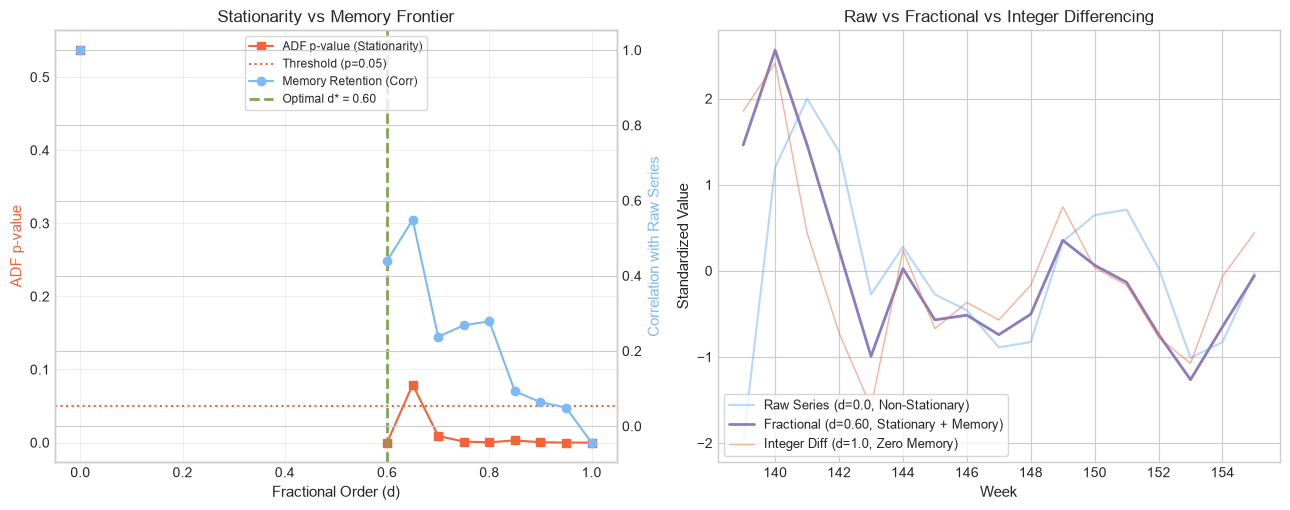

In [5]:
headcount_df = generate_headcount_timeseries(n_weeks=156, seed=42)
d_grid = np.linspace(0.0, 1.0, 21)
scan_results = scan_fractional_differencing(headcount_df['headcount'], d_values=d_grid)
stat_rows = scan_results[scan_results['is_stationary']]
opt_d = float(stat_rows.iloc[0]['d']) if len(stat_rows) > 0 else 0.45
headcount_df['frac_diff_opt'] = fractional_difference(headcount_df['headcount'], d=opt_d)
headcount_df['int_diff_1'] = headcount_df['headcount'].diff(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
line1 = ax1.plot(scan_results['d'], scan_results['p_value'], color=PALETTE['salmon'], marker='s', label='ADF p-value (Stationarity)')
line2 = ax1.axhline(0.05, color=PALETTE['salmon'], linestyle=':', label='Threshold (p=0.05)')
ax1.set_ylabel('ADF p-value', color=PALETTE['salmon'])
ax1.set_xlabel('Fractional Order (d)')
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
line3 = ax1_twin.plot(scan_results['d'], scan_results['correlation_with_raw'], color=PALETTE['light_blue'], marker='o', label='Memory Retention (Corr)')
ax1_twin.set_ylabel('Correlation with Raw Series', color=PALETTE['light_blue'])
line4 = ax1.axvline(opt_d, color=PALETTE['sage_green'], linestyle='--', linewidth=2, label=f'Optimal d* = {opt_d:.2f}')
ax1.set_title('Stationarity vs Memory Frontier')

# Unified legend for twin axes
lines = line1 + [line2] + line3 + [line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', frameon=True, fontsize=8.5)

# Normalized series comparison (dropping initial NaN burn-in for clean alignment)
valid_mask = headcount_df['frac_diff_opt'].notna()
norm_raw = (headcount_df.loc[valid_mask, 'headcount'] - headcount_df.loc[valid_mask, 'headcount'].mean()) / headcount_df.loc[valid_mask, 'headcount'].std()
norm_frac = (headcount_df.loc[valid_mask, 'frac_diff_opt'] - headcount_df.loc[valid_mask, 'frac_diff_opt'].mean()) / headcount_df.loc[valid_mask, 'frac_diff_opt'].std()
norm_int = (headcount_df.loc[valid_mask, 'int_diff_1'] - headcount_df.loc[valid_mask, 'int_diff_1'].mean()) / headcount_df.loc[valid_mask, 'int_diff_1'].std()

ax2.plot(headcount_df.loc[valid_mask, 'week_index'], norm_raw, label='Raw Series (d=0.0, Non-Stationary)', alpha=0.55, color=PALETTE['light_blue'], linewidth=1.5)
ax2.plot(headcount_df.loc[valid_mask, 'week_index'], norm_frac, label=f'Fractional (d={opt_d:.2f}, Stationary + Memory)', color=PALETTE['lilac'], linewidth=2.0)
ax2.plot(headcount_df.loc[valid_mask, 'week_index'], norm_int, label='Integer Diff (d=1.0, Zero Memory)', color=PALETTE['salmon'], alpha=0.50, linewidth=1.0)
ax2.set_title('Raw vs Fractional vs Integer Differencing')
ax2.set_xlabel('Week')
ax2.set_ylabel('Standardized Value')
ax2.legend(loc='lower left', frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

### Feature 5: Weighted Weeks Since (Continuous Event-Decay Features)

#### The Concept
Transforms tiered recognition events (Gold \$100 / 1.0, Silver \$50 / 0.5, Bronze \$25 / 0.25) into an exponentially decaying continuous pulse feature:

$$S(t) = \sum_{e} w_e \cdot \exp\left(-\frac{\ln(2)}{\tau} \cdot (t - t_e)\right) \cdot \mathbb{I}(t \ge t_e)$$

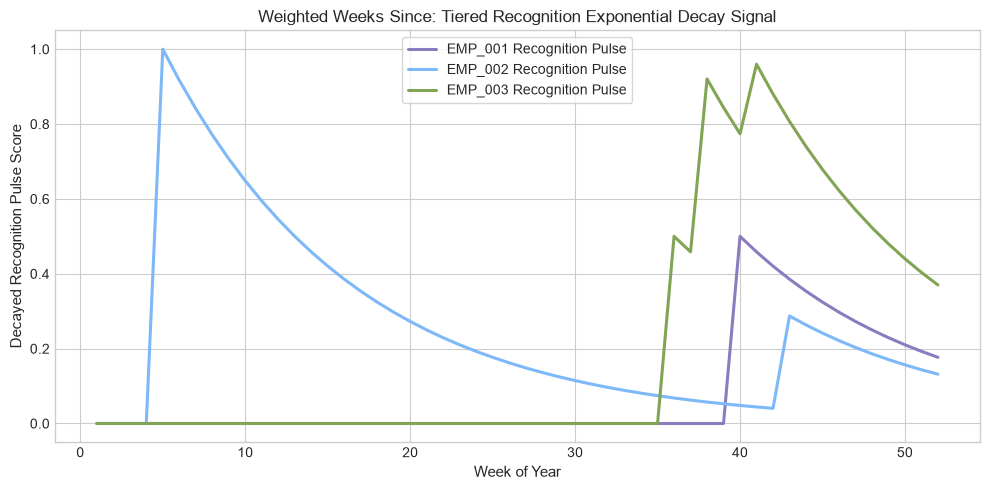

In [6]:
rewards_df = generate_rewards_timeseries(n_weeks=52, seed=42)
eval_weeks = np.arange(1, 53)
sample_employees = ['EMP_001', 'EMP_002', 'EMP_003']
pulse_trajectories = {emp: [] for emp in sample_employees}

for w in eval_weeks:
    w_res = weighted_weeks_since(rewards_df, current_week=w, half_life_weeks=8.0)
    for emp in sample_employees:
        emp_row = w_res[w_res['employee_id'] == emp]
        val = float(emp_row['total_decayed_recognition_pulse'].iloc[0]) if len(emp_row) > 0 else 0.0
        pulse_trajectories[emp].append(val)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE['lilac'], PALETTE['light_blue'], PALETTE['sage_green']]
for i, emp in enumerate(sample_employees):
    ax.plot(eval_weeks, pulse_trajectories[emp], label=f'{emp} Recognition Pulse', color=colors[i], linewidth=2.2)
ax.set_title('Weighted Weeks Since: Tiered Recognition Exponential Decay Signal')
ax.set_xlabel('Week of Year')
ax.set_ylabel('Decayed Recognition Pulse Score')
ax.legend(frameon=True)
plt.show()

### Feature 6: Exponentially Weighted Moving Average (EWMA)

#### The Concept
Smooths high-frequency noise while eliminating ghost drops caused by simple rolling windows and adapting rapidly to level shifts:

$$y_t = \alpha x_t + (1 - \alpha) y_{t-1}, \quad \alpha = \frac{2}{\text{span} + 1}$$

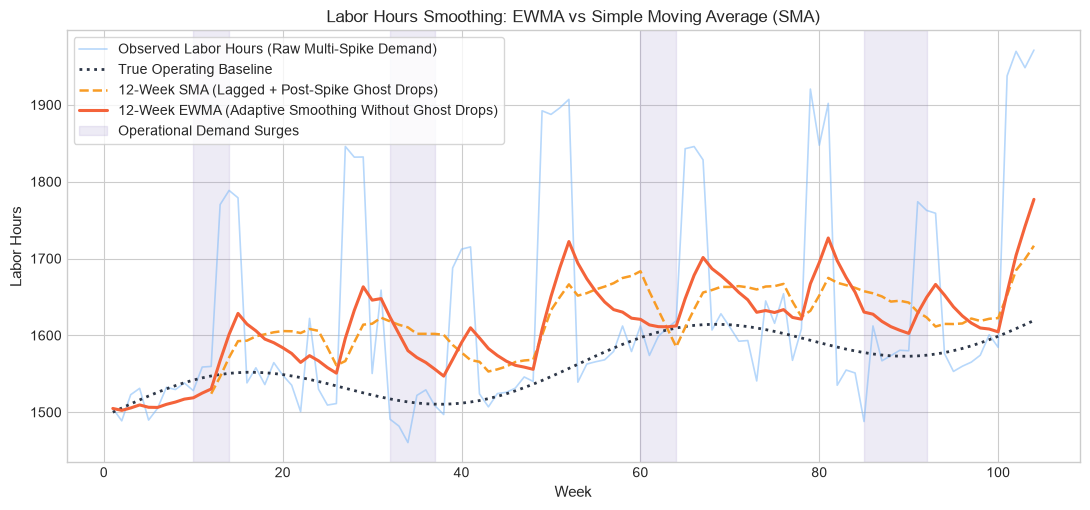

In [7]:
labor_df = generate_labor_hours_traffic(n_weeks=104, seed=42)
labor_df['sma_12'] = labor_df['labor_hours'].rolling(window=12).mean()
labor_df['ewma_12'] = calculate_ewma(labor_df['labor_hours'], span=12)

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(labor_df['week'], labor_df['labor_hours'], color=PALETTE['light_blue'], alpha=0.55, label='Observed Labor Hours (Raw Multi-Spike Demand)', linewidth=1.2)
ax.plot(labor_df['week'], labor_df['true_baseline'], color=PALETTE['dark_slate'], linestyle=':', label='True Operating Baseline', linewidth=2.0)
ax.plot(labor_df['week'], labor_df['sma_12'], color=PALETTE['light_orange'], linestyle='--', label='12-Week SMA (Lagged + Post-Spike Ghost Drops)', linewidth=1.8)
ax.plot(labor_df['week'], labor_df['ewma_12'], color=PALETTE['salmon'], label='12-Week EWMA (Adaptive Smoothing Without Ghost Drops)', linewidth=2.2)
# Annotate operational surge periods
ax.axvspan(10, 14, color=PALETTE['lilac'], alpha=0.15, label='Operational Demand Surges')
ax.axvspan(32, 37, color=PALETTE['lilac'], alpha=0.15)
ax.axvspan(60, 64, color=PALETTE['lilac'], alpha=0.15)
ax.axvspan(85, 92, color=PALETTE['lilac'], alpha=0.15)
ax.set_title('Labor Hours Smoothing: EWMA vs Simple Moving Average (SMA)')
ax.set_xlabel('Week')
ax.set_ylabel('Labor Hours')
ax.legend(loc='upper left', frameon=True)
plt.show()

### Feature 6b: Exponentially Weighted Moving Sum (EWMS) for Count Data

#### The Problem with EWMA on Event Counts
Standard **EWMA** divides by the sum of kernel weights, estimating an *average rate per period*. When tracking discrete workforce events (e.g. workplace safety incidents, disciplinary actions, attendance infractions, or customer escalations), EWMA dilutes isolated incidents into tiny fractions (e.g. 0.03 incidents/week), masking compound event momentum.

#### The Mathematical Solution: Leaky Accumulator (EWMS)
**EWMS (Exponentially Weighted Moving Sum)** operates as an event integrator with continuous exponential recency decay:

$$S_t = C_t + \lambda S_{t-1} = \sum_{k=0}^{t} \lambda^k C_{t-k}, \quad \lambda = \exp\left(-\frac{\ln(2)}{\text{half\_life}}\right)$$

When an incident occurs, the worker's active incident burden immediately jumps. In subsequent quiet weeks, the burden decays smoothly toward zero. If multiple incidents cluster together, the burden compounds super-linearly, signaling an acute risk escalation.

#### Statistical Process Monitoring: Poisson EWMA
To test whether count surges exceed expected baseline Poisson variation, **Poisson EWMA** tracks the smoothed rate $\hat{\mu}_t$ alongside its asymptotic standardized Z-score:

$$\sigma^2_{\hat{\mu}} = \left(\frac{\alpha}{2 - \alpha}\right) \mu_0, \quad Z_t = \frac{\hat{\mu}_t - \mu_0}{\sqrt{\sigma^2_{\hat{\mu}}}}$$

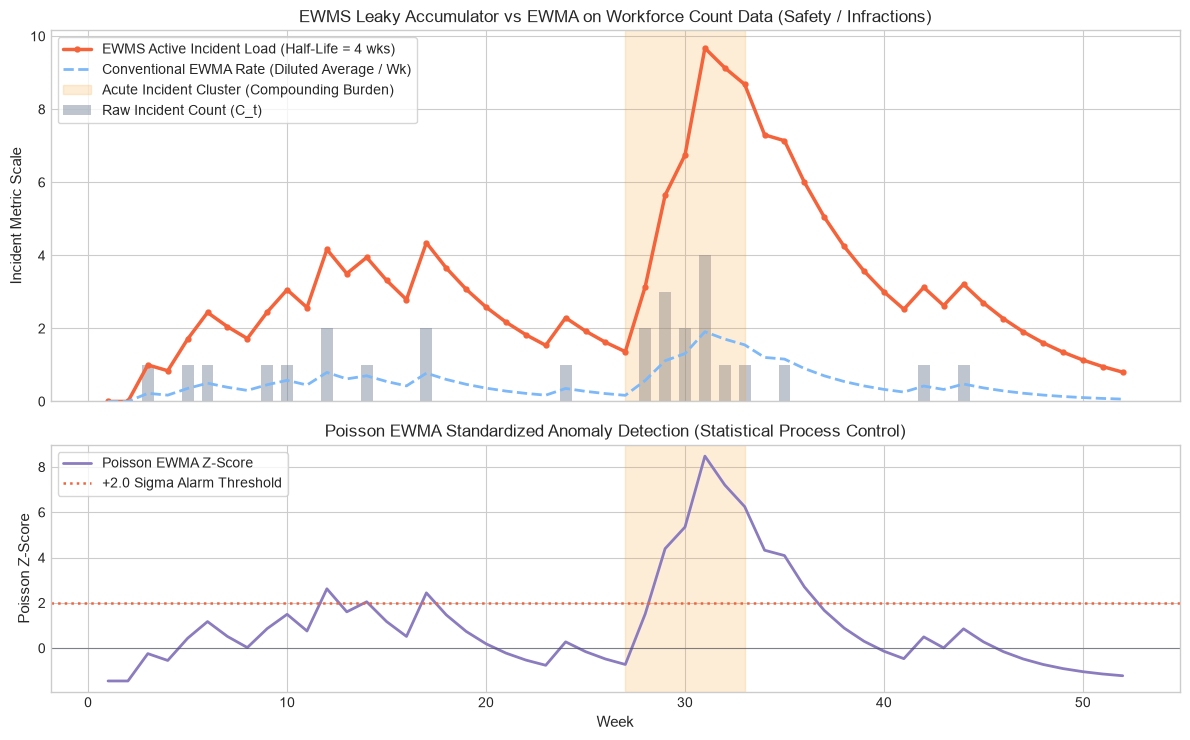

In [8]:
# Simulate 52-week incident stream for an operational department
rng = np.random.default_rng(42)
weeks = np.arange(1, 53)
# Background Poisson noise (rate = 0.25 incidents/wk), with acute fatigue surge at weeks 28-32
incidents = rng.poisson(lam=0.25, size=52)
incidents[27:32] = [2, 3, 2, 4, 1]  # Acute operational cluster
incidents[11] = 2  # Isolated dual incident

count_df = pd.DataFrame({'week': weeks, 'incident_count': incidents})

# 1. Calculate EWMS with 4-week half-life
count_df['ewms_4w'] = calculate_ewms(count_df['incident_count'], half_life=4.0)

# 2. Calculate conventional EWMA (span=8) for contrast
count_df['ewma_rate'] = calculate_ewma(count_df['incident_count'], span=8)

# 3. Calculate Poisson EWMA & standardized anomaly Z-score
count_df['poisson_rate'], count_df['poisson_z'] = calculate_poisson_ewma(count_df['incident_count'], alpha=0.25, baseline_mean=0.3)

# Visualization: 2-Panel Diagnostic
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw={'height_ratios': [1.8, 1.2]})

# Panel 1: Event Spikes vs EWMS Active Load vs Diluted EWMA
ax1.bar(count_df['week'], count_df['incident_count'], color=PALETTE['muted_gray'], alpha=0.45, label='Raw Incident Count (C_t)', width=0.6)
ax1.plot(count_df['week'], count_df['ewms_4w'], color=PALETTE['salmon'], linewidth=2.5, marker='o', markersize=3.5, label='EWMS Active Incident Load (Half-Life = 4 wks)')
ax1.plot(count_df['week'], count_df['ewma_rate'], color=PALETTE['light_blue'], linewidth=2.0, linestyle='--', label='Conventional EWMA Rate (Diluted Average / Wk)')
ax1.axvspan(27, 33, color=PALETTE['light_orange'], alpha=0.18, label='Acute Incident Cluster (Compounding Burden)')
ax1.set_ylabel('Incident Metric Scale')
ax1.set_title('EWMS Leaky Accumulator vs EWMA on Workforce Count Data (Safety / Infractions)')
ax1.legend(loc='upper left', frameon=True)

# Panel 2: Poisson Standardized Anomaly Z-Score
ax2.plot(count_df['week'], count_df['poisson_z'], color=PALETTE['lilac'], linewidth=2.0, label='Poisson EWMA Z-Score')
ax2.axhline(2.0, color=PALETTE['salmon'], linestyle=':', linewidth=1.8, label='+2.0 Sigma Alarm Threshold')
ax2.axhline(0.0, color=PALETTE['dark_slate'], linestyle='-', linewidth=0.8, alpha=0.5)
ax2.axvspan(27, 33, color=PALETTE['light_orange'], alpha=0.18)
ax2.set_xlabel('Week')
ax2.set_ylabel('Poisson Z-Score')
ax2.set_title('Poisson EWMA Standardized Anomaly Detection (Statistical Process Control)')
ax2.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

### Feature 7: Double and Triple Exponential Smoothing (Holt-Winters)

#### Moving Beyond Single EWMA
Standard **Single EWMA** relies on a solitary parameter ($\alpha$) tracking process level. However, workforce demand and labor hours typically exhibit both **systematic growth/contraction trends** and **cyclical seasonal waves** (e.g. annual retail holiday ramps, summer surges, or university graduation hiring cycles). Applying basic EWMA to trending or seasonal data introduces severe systematic lagging errors.

#### Double Exponential Smoothing (Holt's Linear Trend)
Adds a trend smoothing parameter $\beta$ to estimate the directional velocity of headcount growth, eliminating lagging bias:

$$\ell_t = \alpha y_t + (1 - \alpha)(\ell_{t-1} + b_{t-1}), \quad b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta) b_{t-1}$$

#### Triple Exponential Smoothing (Holt-Winters Multi-Component Decomposition)
Adds a seasonal smoothing parameter $\gamma$ across period $m$ (e.g. $m=52$ weeks) to decompose observed workforce metrics into three orthogonal operational components:

$$\ell_t = \alpha (y_t - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta) b_{t-1}$$
$$s_t = \gamma (y_t - \ell_{t-1} - b_{t-1}) + (1 - \gamma) s_{t-m}$$
$$\hat{y}_{t+h} = \ell_t + h b_t + s_{t+h-m}$$

This isolates whether an overtime surge is driven by organic secular growth ($b_t$) or expected seasonal cyclicity ($s_t$).

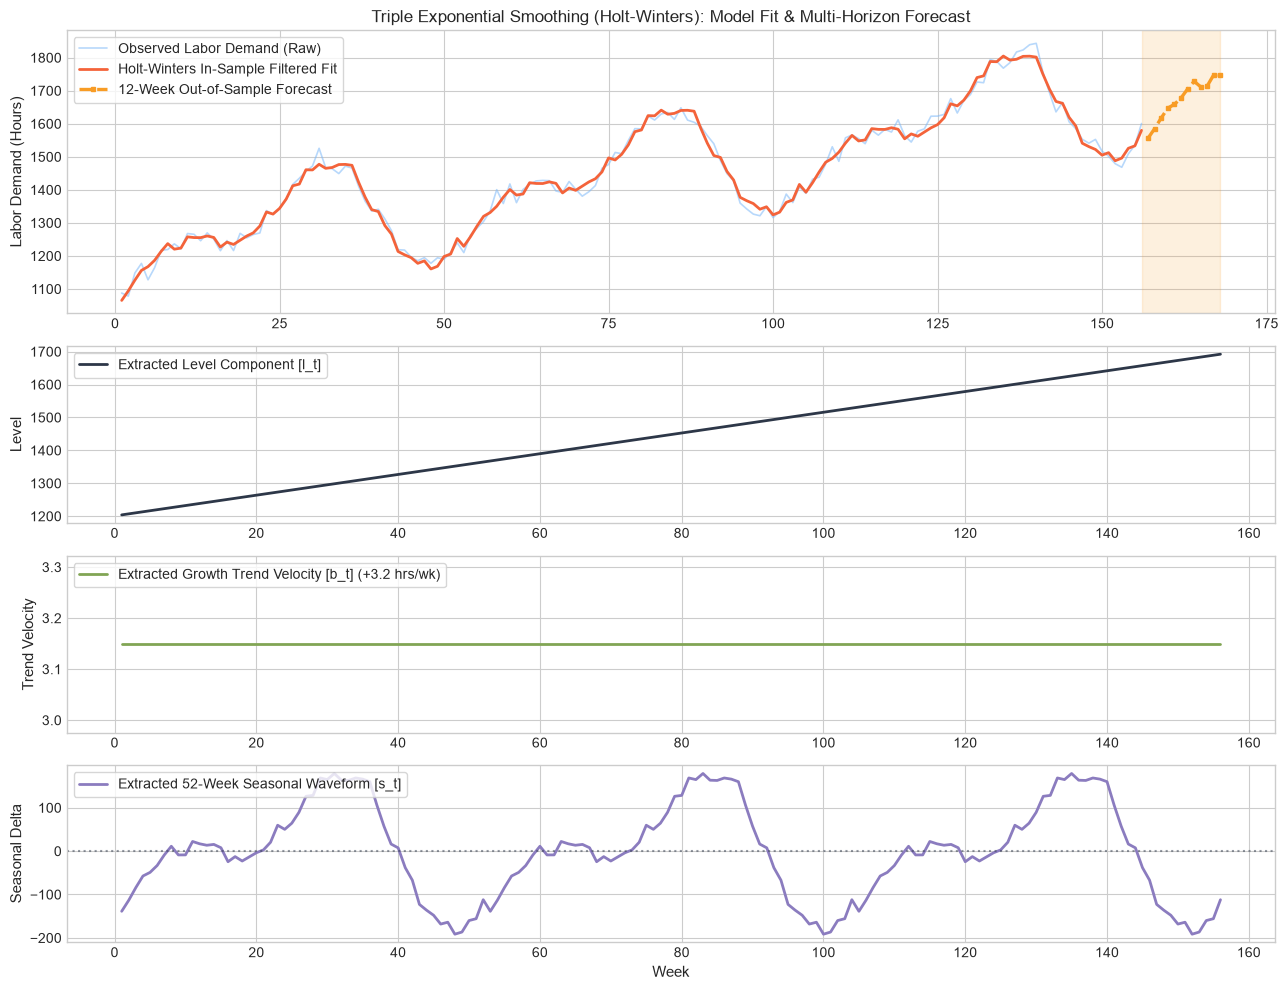

In [9]:
# Generate 3-year weekly workforce demand (156 weeks) with annual seasonality
seasonal_df = generate_seasonal_workforce_timeseries(n_weeks=156, seed=42)

# Fit Triple Exponential Smoothing (Holt-Winters) with 52-week seasonality & 12-week forecast
hw_fitted, hw_decomp, hw_meta = triple_exponential_smoothing(
    seasonal_df['observed_labor_demand'],
    seasonal_periods=52,
    forecast_periods=12,
)

forecast_weeks = np.arange(157, 169)

# 4-Row Complete Decomposition Visualization
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=False, gridspec_kw={'height_ratios': [1.6, 1.0, 1.0, 1.0]})

# Panel 1: Observed vs Holt-Winters Fit + 12-Week Forecast
axes[0].plot(seasonal_df['week'], seasonal_df['observed_labor_demand'], color=PALETTE['light_blue'], alpha=0.55, label='Observed Labor Demand (Raw)', linewidth=1.2)
axes[0].plot(seasonal_df['week'], hw_fitted, color=PALETTE['salmon'], linewidth=2.0, label='Holt-Winters In-Sample Filtered Fit')
axes[0].plot(forecast_weeks, hw_meta['forecast'], color=PALETTE['light_orange'], linewidth=2.4, linestyle='--', marker='s', markersize=3.5, label='12-Week Out-of-Sample Forecast')
axes[0].axvspan(156, 168, color=PALETTE['light_orange'], alpha=0.15)
axes[0].set_ylabel('Labor Demand (Hours)')
axes[0].set_title('Triple Exponential Smoothing (Holt-Winters): Model Fit & Multi-Horizon Forecast')
axes[0].legend(loc='upper left', frameon=True)

# Panel 2: Isolated Baseline Level Component
axes[1].plot(seasonal_df['week'], hw_decomp['level'], color=PALETTE['dark_slate'], linewidth=2.0, label='Extracted Level Component [l_t]')
axes[1].set_ylabel('Level')
axes[1].legend(loc='upper left', frameon=True)

# Panel 3: Isolated Secular Growth Trend Velocity
axes[2].plot(seasonal_df['week'], hw_decomp['trend'], color=PALETTE['sage_green'], linewidth=2.0, label='Extracted Growth Trend Velocity [b_t] (+3.2 hrs/wk)')
axes[2].set_ylabel('Trend Velocity')
axes[2].legend(loc='upper left', frameon=True)

# Panel 4: Isolated Annual Recurring Seasonal Wave
axes[3].plot(seasonal_df['week'], hw_decomp['seasonal'], color=PALETTE['lilac'], linewidth=2.0, label='Extracted 52-Week Seasonal Waveform [s_t]')
axes[3].axhline(0, color=PALETTE['dark_slate'], linestyle=':', alpha=0.5)
axes[3].set_xlabel('Week')
axes[3].set_ylabel('Seasonal Delta')
axes[3].legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

### Feature 8: Kaplan-Meier & Nelson-Aalen Hazard Embeddings

#### The Concept
Transforms integer tenure into empirical behavioral coordinates: survival probability $\hat{S}(\text{tenure})$ and cumulative hazard $\hat{H}(\text{tenure})$, directly mapping the 90-day onboarding cliff.

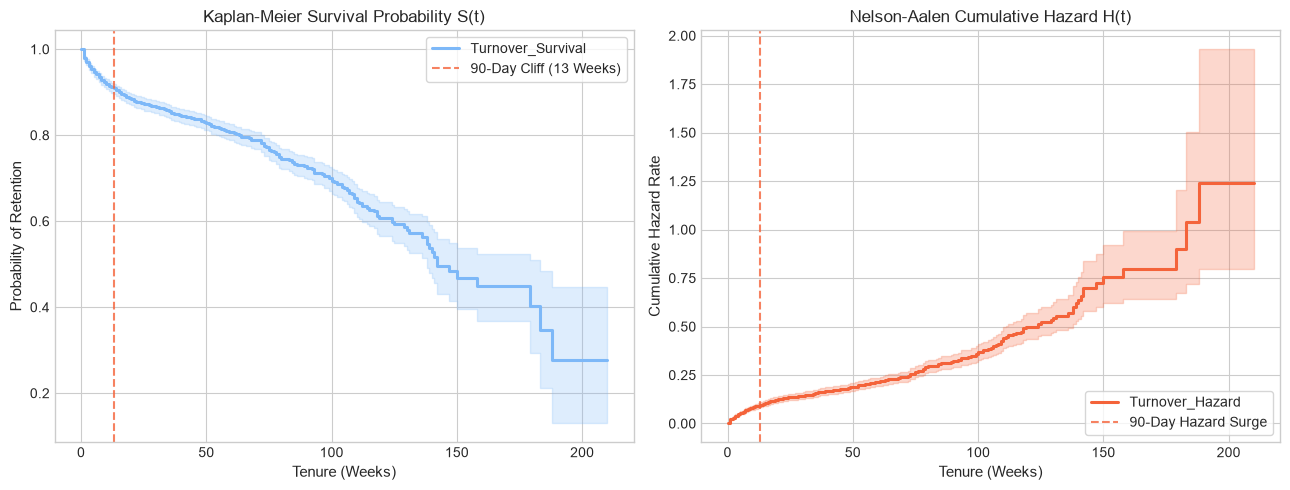

In [10]:
embedded_roster, hazard_models = fit_hazard_embeddings(roster_df, tenure_col='tenure_weeks', event_col='turnover_event')
kmf = hazard_models['kmf']
naf = hazard_models['naf']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
kmf.plot_survival_function(ax=ax1, color=PALETTE['light_blue'], linewidth=2.2)
ax1.axvline(13, color=PALETTE['salmon'], linestyle='--', alpha=0.8, label='90-Day Cliff (13 Weeks)')
ax1.set_title('Kaplan-Meier Survival Probability S(t)')
ax1.set_xlabel('Tenure (Weeks)')
ax1.set_ylabel('Probability of Retention')
ax1.legend(frameon=True)

naf.plot_cumulative_hazard(ax=ax2, color=PALETTE['salmon'], linewidth=2.2)
ax2.axvline(13, color=PALETTE['salmon'], linestyle='--', alpha=0.8, label='90-Day Hazard Surge')
ax2.set_title('Nelson-Aalen Cumulative Hazard H(t)')
ax2.set_xlabel('Tenure (Weeks)')
ax2.set_ylabel('Cumulative Hazard Rate')
ax2.legend(frameon=True)
plt.tight_layout()
plt.show()

### Feature 9: Configuration-Driven Rolling Metrics (Multi-Horizon Cohort Pipelines)

#### The Concept
Rather than hardcoding distinct temporal features, a generic rolling function dynamically calculates trailing statistics (such as means, sums, variances, or maximums) across defined hierarchical partitions. By passing a configuration dictionary to a pandas transform and rolling method, it ensures chronological integrity within specific cohorts (like Store and Department) without altering the original dataframe structure.

#### The Application
Simultaneously generates:
1. **Trailing 52-Week Turnover Rate**: Smooths out seasonal attrition peaks to isolate the underlying structural flight risk.
2. **13-Week Trailing Headcount Baseline**: Sets quarterly pre-forecast labor demand levels.
3. **4-Week Rolling Variance of Assigned Hours**: Isolates schedule-induced fatigue shocks and shift volatility.

All calculated through a single, scalable pipeline.

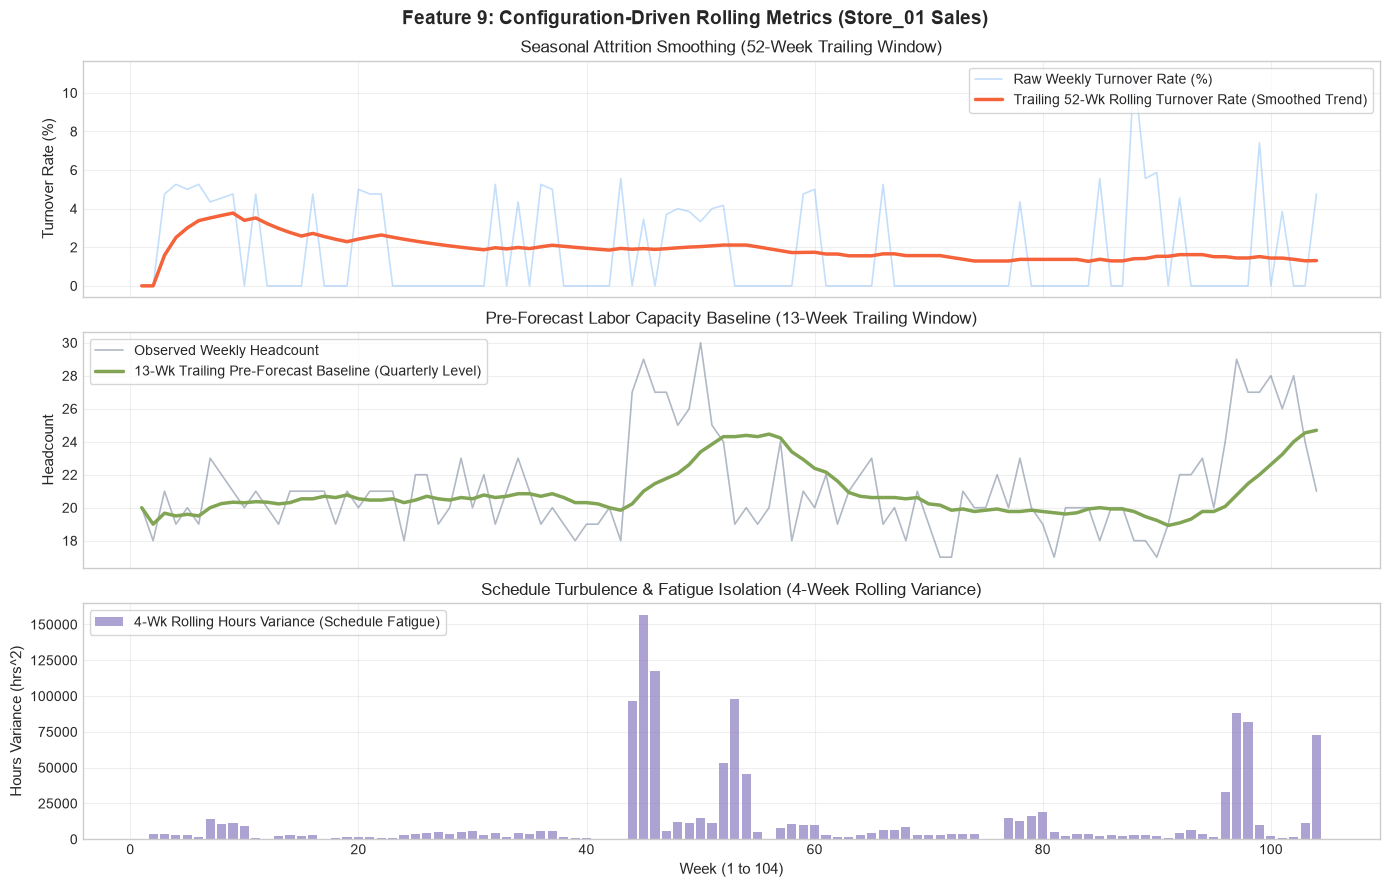

Latest 5 Weeks for Store_01 Sales:
 week  headcount  headcount_13w_baseline  assigned_hours  hours_4w_fatigue_var  turnover_rate  turnover_52w_mean
  100         28               22.615385          1281.8           2267.976667         0.0000           0.014383
  101         26               23.230769          1205.6            999.289167         0.0385           0.014383
  102         28               24.000000          1294.3           1606.989167         0.0000           0.013742
  103         24               24.538462          1061.8          11413.755833         0.0000           0.012973
  104         21               24.692308           683.9          72514.153333         0.0476           0.013087


In [11]:
from data.synthetic_generators import generate_store_department_labor_panel
from people_analytics_toolkit.memory import RollingMetricsPipeline, compute_rolling_metrics

# Generate 2 years (104 weeks) of store x department labor data
panel_df = generate_store_department_labor_panel(n_stores=5, n_depts=4, n_weeks=104, seed=42)

# Configure multi-horizon rolling pipeline
pipeline = (
    RollingMetricsPipeline(partition_cols=['store_id', 'dept_id'], temporal_col='week')
    .add_metric('turnover_rate', window=52, aggregation='mean', output_column='turnover_52w_mean')
    .add_metric('headcount', window=13, aggregation='mean', output_column='headcount_13w_baseline')
    .add_metric('assigned_hours', window=4, aggregation='var', output_column='hours_4w_fatigue_var')
)

transformed_df = pipeline.transform(panel_df)

# Filter focus cohort: Store_01 Sales Department
focus = transformed_df[(transformed_df['store_id'] == 'Store_01') & (transformed_df['dept_id'] == 'Sales')].sort_values('week')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Configuration-Driven Rolling Metrics (Store_01 Sales)', fontsize=14, fontweight='bold')

# Panel 1: Trailing 52-Week Turnover Rate vs Raw Weekly Rate
axes[0].plot(focus['week'], focus['turnover_rate'] * 100, color=PALETTE['light_blue'], alpha=0.45, linewidth=1.2, label='Raw Weekly Turnover Rate (%)')
axes[0].plot(focus['week'], focus['turnover_52w_mean'] * 100, color=PALETTE['salmon'], linewidth=2.5, label='Trailing 52-Wk Rolling Turnover Rate (Smoothed Trend)')
axes[0].set_ylabel('Turnover Rate (%)')
axes[0].set_title('Seasonal Attrition Smoothing (52-Week Trailing Window)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', frameon=True)

# Panel 2: 13-Week Pre-Forecast Headcount Baseline
axes[1].plot(focus['week'], focus['headcount'], color=PALETTE['muted_gray'], alpha=0.55, linewidth=1.2, label='Observed Weekly Headcount')
axes[1].plot(focus['week'], focus['headcount_13w_baseline'], color=PALETTE['sage_green'], linewidth=2.5, label='13-Wk Trailing Pre-Forecast Baseline (Quarterly Level)')
axes[1].set_ylabel('Headcount')
axes[1].set_title('Pre-Forecast Labor Capacity Baseline (13-Week Trailing Window)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', frameon=True)

# Panel 3: 4-Week Rolling Variance of Assigned Hours (Fatigue Surge)
axes[2].bar(focus['week'], focus['hours_4w_fatigue_var'], color=PALETTE['lilac'], alpha=0.7, width=0.8, label='4-Wk Rolling Hours Variance (Schedule Fatigue)')
axes[2].set_ylabel('Hours Variance (hrs^2)')
axes[2].set_xlabel('Week (1 to 104)')
axes[2].set_title('Schedule Turbulence & Fatigue Isolation (4-Week Rolling Variance)')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

# Display latest cohort records
cols_show = ['week', 'headcount', 'headcount_13w_baseline', 'assigned_hours', 'hours_4w_fatigue_var', 'turnover_rate', 'turnover_52w_mean']
print('Latest 5 Weeks for Store_01 Sales:')
print(focus[cols_show].tail(5).to_string(index=False))

### Feature 10: Singular Spectrum Analysis (SVD Smoothing & Lag-Free Baselines)

#### The Concept
Rather than applying a simple moving average, Singular Spectrum Analysis (SSA) embeds a 1D time series into a multidimensional trajectory Hankel matrix and applies Singular Value Decomposition (SVD). By reconstructing the series using only the top $k$ principal singular components, it mathematically separates the core structural signal (underlying secular trend and dominant harmonic seasonal cycles) from high-frequency random noise without introducing the temporal phase-lag inherent to traditional moving averages.

#### The Application
Extracting the true baseline trajectory of daily store foot traffic or labor demand. Because retail environments suffer from chaotic day-to-day variance (weather shocks, sudden callouts, local supply disruptions), feeding raw daily hours into a predictive model often results in massive overfitting. Applying SVD smoothing reconstructs a clean, lag-free baseline curve to pass as a dynamic covariate into multi-step forecasting models (like Darts ensembles or LightGBM regressors), stabilizing the model's ability to learn complex, overlapping seasonalities.

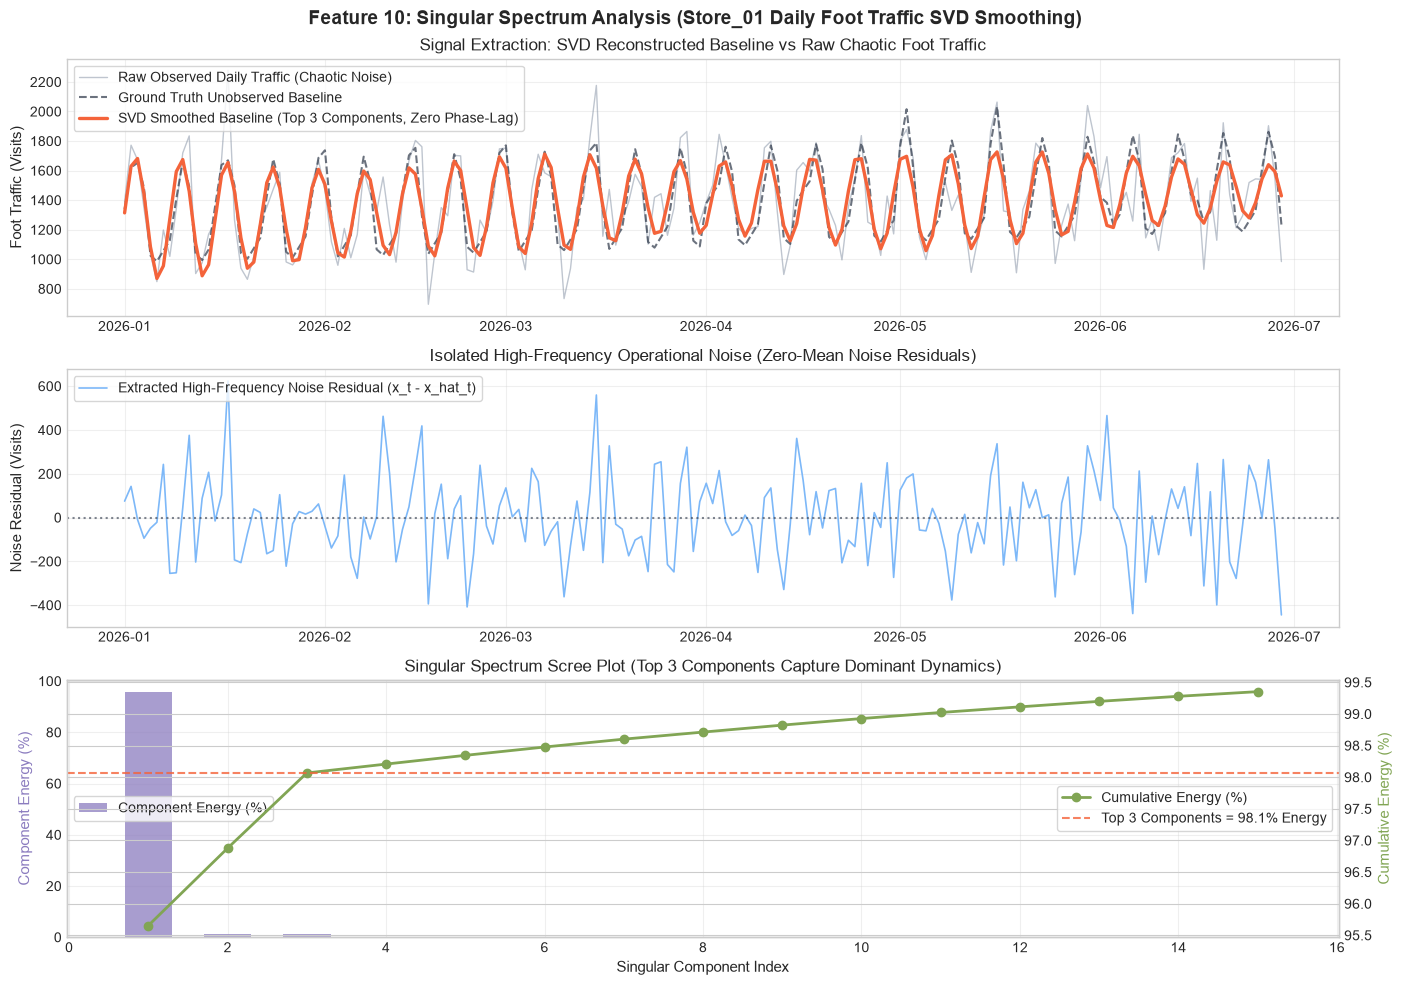

Raw Observed Noise RMSE vs True Baseline:    182.28 visits
SVD Reconstructed RMSE vs True Baseline:     107.28 visits
Noise Attenuation Ratio:                    41.1% error reduction
Singular Energy in Top 3 Components:        98.07%


In [12]:
from data.synthetic_generators import generate_daily_store_foot_traffic
from people_analytics_toolkit.memory import singular_spectrum_analysis, compute_svd_smoothed_baseline

# Generate 180 days of chaotic daily store foot traffic
traffic_df = generate_daily_store_foot_traffic(n_days=180, n_stores=1, seed=42)

# Apply Singular Spectrum Analysis (Hankel window length L=28 days to capture weekly cycles)
ssa_res = singular_spectrum_analysis(traffic_df['observed_foot_traffic'], window_length=28, top_k=3)
traffic_df['foot_traffic_svd_smoothed'] = ssa_res['smoothed']
traffic_df['foot_traffic_svd_residual'] = ssa_res['residual']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Singular Spectrum Analysis (Store_01 Daily Foot Traffic SVD Smoothing)', fontsize=14, fontweight='bold')

# Panel 1: Observed Traffic vs True Baseline vs SVD Smoothed Baseline
axes[0].plot(traffic_df['date'], traffic_df['observed_foot_traffic'], color=PALETTE['muted_gray'], alpha=0.45, linewidth=1.0, label='Raw Observed Daily Traffic (Chaotic Noise)')
axes[0].plot(traffic_df['date'], traffic_df['true_baseline'], color=PALETTE['dark_slate'], linestyle='--', linewidth=1.5, alpha=0.7, label='Ground Truth Unobserved Baseline')
axes[0].plot(traffic_df['date'], traffic_df['foot_traffic_svd_smoothed'], color=PALETTE['salmon'], linewidth=2.4, label='SVD Smoothed Baseline (Top 3 Components, Zero Phase-Lag)')
axes[0].set_ylabel('Foot Traffic (Visits)')
axes[0].set_title('Signal Extraction: SVD Reconstructed Baseline vs Raw Chaotic Foot Traffic')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', frameon=True)

# Panel 2: Isolated Noise Residuals (Weather / Anomaly Shocks)
axes[1].plot(traffic_df['date'], traffic_df['foot_traffic_svd_residual'], color=PALETTE['light_blue'], linewidth=1.2, label='Extracted High-Frequency Noise Residual (x_t - x_hat_t)')
axes[1].axhline(0, color=PALETTE['dark_slate'], linestyle=':', alpha=0.6)
axes[1].set_ylabel('Noise Residual (Visits)')
axes[1].set_title('Isolated High-Frequency Operational Noise (Zero-Mean Noise Residuals)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', frameon=True)

# Panel 3: Scree Plot of Singular Value Spectrum & Cumulative Variance
n_sv = min(15, len(ssa_res['singular_values']))
sv_indices = np.arange(1, n_sv + 1)
axes[2].bar(sv_indices, ssa_res['explained_variance_ratio'][:n_sv] * 100, color=PALETTE['lilac'], alpha=0.75, width=0.6, label='Component Energy (%)')
ax2_twin = axes[2].twinx()
cum_var = np.cumsum(ssa_res['explained_variance_ratio'][:n_sv]) * 100
ax2_twin.plot(sv_indices, cum_var, color=PALETTE['sage_green'], marker='o', linewidth=2.0, label='Cumulative Energy (%)')
ax2_twin.axhline(cum_var[2], color=PALETTE['salmon'], linestyle='--', alpha=0.8, label=f'Top 3 Components = {cum_var[2]:.1f}% Energy')
axes[2].set_xlabel('Singular Component Index')
axes[2].set_ylabel('Component Energy (%)', color=PALETTE['lilac'])
ax2_twin.set_ylabel('Cumulative Energy (%)', color=PALETTE['sage_green'])
axes[2].set_title('Singular Spectrum Scree Plot (Top 3 Components Capture Dominant Dynamics)')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='center left', frameon=True)
ax2_twin.legend(loc='center right', frameon=True)

plt.tight_layout()
plt.show()

# Quantitative comparison
raw_rmse = np.sqrt(np.mean((traffic_df['observed_foot_traffic'] - traffic_df['true_baseline'])**2))
svd_rmse = np.sqrt(np.mean((traffic_df['foot_traffic_svd_smoothed'] - traffic_df['true_baseline'])**2))
print(f'Raw Observed Noise RMSE vs True Baseline:    {raw_rmse:.2f} visits')
print(f'SVD Reconstructed RMSE vs True Baseline:     {svd_rmse:.2f} visits')
print(f'Noise Attenuation Ratio:                    {(1.0 - svd_rmse/raw_rmse)*100:.1f}% error reduction')
print(f'Singular Energy in Top 3 Components:        {cum_var[2]:.2f}%')

### Feature 11: Hierarchical Lag & Autoregressive Features

#### The Concept
Autoregressive modeling requires historical observations ($X_{t-1}, X_{t-4}, X_{t-52}$) to serve as baseline covariates. In enterprise workforce panels, raw shifting operations across an unpartitioned dataset lead to catastrophic lookahead bias and cross-cohort target leakage (e.g., shifting row 1 of Store B onto row 104 of Store A). `compute_lag_features` isolates hierarchical cohort partitions (such as Store and Department), sorts chronologically, executes boundary-respecting shifts, and aligns outputs back to the original index without altering row ordering.

#### The Application
Downstream predictive models (e.g. XGBoost, LightGBM, and neural regressors) rely on autoregressive signals to capture inertia and momentum. If a department's labor demand, overtime hours, or turnover rate this week is evaluated against its 1-week, 4-week, and 52-week historical lags, the model can instantly isolate whether a spike is an annual seasonal holiday rush or an anomalous breakdown.

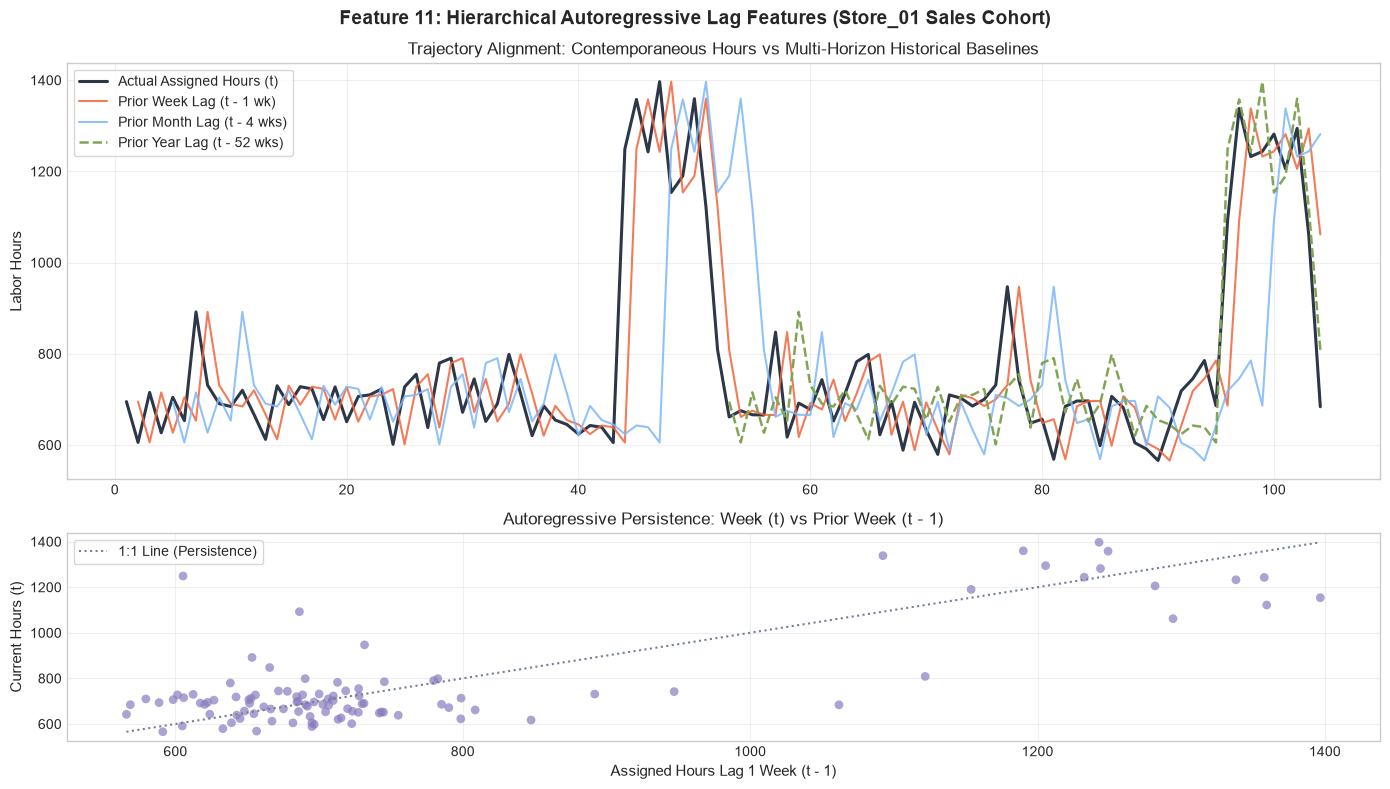

Hierarchical Lag Features Sample (Store_01 Sales, Weeks 50-55):
 week  assigned_hours  assigned_hours_lag_1w  assigned_hours_lag_4w  assigned_hours_lag_52w
   51          1121.8                 1359.5                 1396.8                     NaN
   52           808.6                 1121.8                 1153.8                     NaN
   53           661.5                  808.6                 1190.1                   695.0
   54           675.2                  661.5                 1359.5                   605.7
   55           666.3                  675.2                 1121.8                   715.3
   56           665.6                  666.3                  808.6                   626.8


In [13]:
from people_analytics_toolkit.memory import compute_lag_features

# Compute 1-week, 4-week, and 52-week lags on store-department labor panel
lagged_panel = compute_lag_features(
    df=panel_df,
    target_cols='assigned_hours',
    lags={'lag_1w': 1, 'lag_4w': 4, 'lag_52w': 52},
    partition_cols=['store_id', 'dept_id'],
    temporal_col='week',
)

# Extract Store_01 Sales cohort for visualization
s1_sales = lagged_panel[(lagged_panel['store_id'] == 'Store_01') & (lagged_panel['dept_id'] == 'Sales')].sort_values('week')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Hierarchical Autoregressive Lag Features (Store_01 Sales Cohort)', fontsize=14, fontweight='bold')

# Panel 1: Actual Series vs Historical Lags
axes[0].plot(s1_sales['week'], s1_sales['assigned_hours'], color=PALETTE['dark_slate'], linewidth=2.2, label='Actual Assigned Hours (t)')
axes[0].plot(s1_sales['week'], s1_sales['assigned_hours_lag_1w'], color=PALETTE['salmon'], linewidth=1.5, alpha=0.85, label='Prior Week Lag (t - 1 wk)')
axes[0].plot(s1_sales['week'], s1_sales['assigned_hours_lag_4w'], color=PALETTE['light_blue'], linewidth=1.5, alpha=0.85, label='Prior Month Lag (t - 4 wks)')
axes[0].plot(s1_sales['week'], s1_sales['assigned_hours_lag_52w'], color=PALETTE['sage_green'], linestyle='--', linewidth=1.8, label='Prior Year Lag (t - 52 wks)')
axes[0].set_ylabel('Labor Hours')
axes[0].set_title('Trajectory Alignment: Contemporaneous Hours vs Multi-Horizon Historical Baselines')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', frameon=True)

# Panel 2: Autoregressive Correlation Scatter (t vs t-1)
valid_lags = s1_sales.dropna(subset=['assigned_hours', 'lag_1w' if 'lag_1w' in s1_sales.columns else 'assigned_hours_lag_1w'])
lag1_col = 'assigned_hours_lag_1w'
axes[1].scatter(valid_lags[lag1_col], valid_lags['assigned_hours'], color=PALETTE['lilac'], alpha=0.7, edgecolors='none', s=40)
# Reference line
min_val = min(valid_lags[lag1_col].min(), valid_lags['assigned_hours'].min())
max_val = max(valid_lags[lag1_col].max(), valid_lags['assigned_hours'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color=PALETTE['muted_gray'], linestyle=':', linewidth=1.5, label='1:1 Line (Persistence)')
axes[1].set_xlabel('Assigned Hours Lag 1 Week (t - 1)')
axes[1].set_ylabel('Current Hours (t)')
axes[1].set_title('Autoregressive Persistence: Week (t) vs Prior Week (t - 1)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

print('Hierarchical Lag Features Sample (Store_01 Sales, Weeks 50-55):')
show_cols = ['week', 'assigned_hours', 'assigned_hours_lag_1w', 'assigned_hours_lag_4w', 'assigned_hours_lag_52w']
print(s1_sales[show_cols].iloc[50:56].to_string(index=False))

### Feature 12: Multi-Horizon Differencing & Growth Rates (YoY, MoM, WoW & % Change)

#### The Concept
Temporal stationarity and trend removal are fundamental for causal inference and machine learning. `compute_differencing_features` computes multi-horizon discrete differences:
$$\Delta_s X_t = X_t - X_{t-s}$$
and relative percentage growth rates:
$$\% \Delta_s X_t = \frac{X_t - X_{t-s}}{X_{t-s}} \times 100$$
across standard retail cadences (Week-over-Week, Month-over-Month, Quarter-over-Quarter, Year-over-Year). The function features built-in division-by-zero safeguards (replacing $\pm\infty$ with `np.nan` when prior-period baseline is zero) and respects hierarchical cohort boundaries without leaking cross-store data.

#### The Application
Tracking Year-over-Year (YoY) labor growth and Week-over-Week (WoW) schedule volatility. While absolute labor hours are dominated by annual retail seasonality (e.g. Q4 holiday spikes), a YoY difference removes the seasonal cycle and exposes true underlying organic expansion or contraction. Similarly, WoW percentage change immediately flags acute schedule reductions that trigger associate attrition.

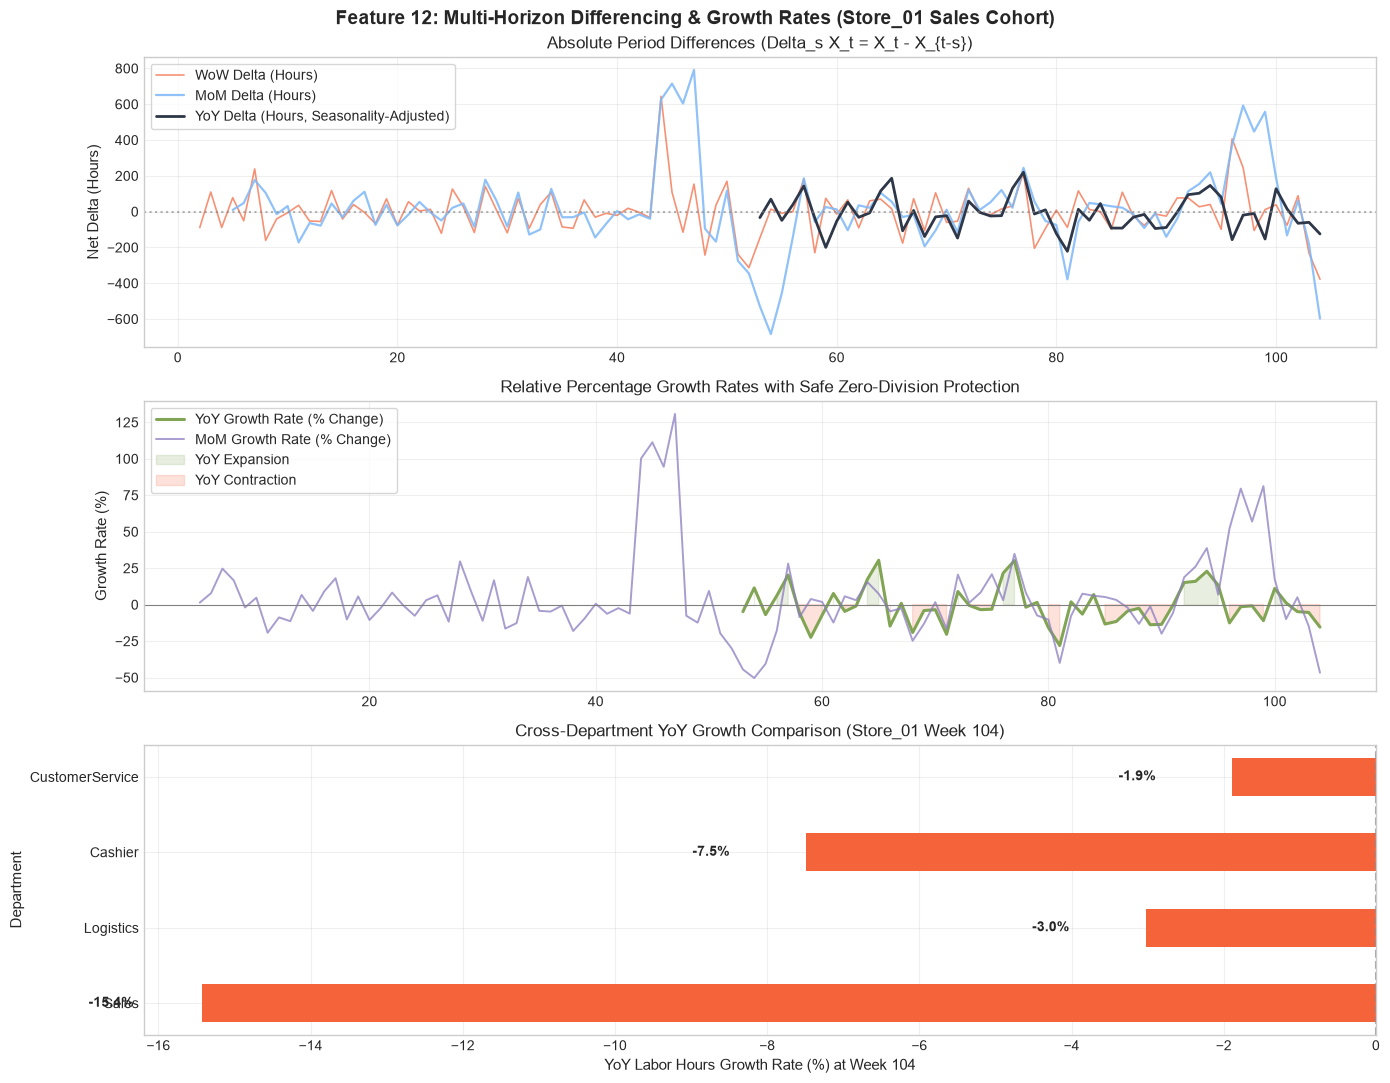

Multi-Horizon Differencing Sample (Store_01 Sales, Latest 5 Weeks):
 week  assigned_hours  assigned_hours_wow  assigned_hours_mom  assigned_hours_yoy  assigned_hours_yoy_pct
  100          1281.8                38.0               189.4               128.0               11.093777
  101          1205.6               -76.2              -132.5                15.5                1.302412
  102          1294.3                88.7                61.8               -65.2               -4.795881
  103          1061.8              -232.5              -182.0               -60.0               -5.348547
  104           683.9              -377.9              -597.9              -124.7              -15.421717


In [14]:
from people_analytics_toolkit.memory import compute_differencing_features, TemporalFeaturesPipeline

# Fluent chaining of hierarchical lags and multi-horizon differencing
pipeline = (
    TemporalFeaturesPipeline(partition_cols=['store_id', 'dept_id'], temporal_col='week')
    .add_differencing('assigned_hours', periods={'wow': 1, 'mom': 4, 'yoy': 52}, pct_change=False)
    .add_differencing('assigned_hours', periods={'wow': 1, 'mom': 4, 'yoy': 52}, pct_change=True, as_percent=True)
)
diff_panel = pipeline.transform(panel_df)

# Extract Store_01 Sales cohort
s1_diff = diff_panel[(diff_panel['store_id'] == 'Store_01') & (diff_panel['dept_id'] == 'Sales')].sort_values('week')

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Multi-Horizon Differencing & Growth Rates (Store_01 Sales Cohort)', fontsize=14, fontweight='bold')

# Panel 1: Discrete Net Deltas (Hours)
axes[0].plot(s1_diff['week'], s1_diff['assigned_hours_wow'], color=PALETTE['salmon'], linewidth=1.2, alpha=0.7, label='WoW Delta (Hours)')
axes[0].plot(s1_diff['week'], s1_diff['assigned_hours_mom'], color=PALETTE['light_blue'], linewidth=1.6, alpha=0.85, label='MoM Delta (Hours)')
axes[0].plot(s1_diff['week'], s1_diff['assigned_hours_yoy'], color=PALETTE['dark_slate'], linewidth=2.0, label='YoY Delta (Hours, Seasonality-Adjusted)')
axes[0].axhline(0, color='gray', linestyle=':', alpha=0.6)
axes[0].set_ylabel('Net Delta (Hours)')
axes[0].set_title('Absolute Period Differences (Delta_s X_t = X_t - X_{t-s})')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', frameon=True)

# Panel 2: Relative Percentage Growth Rates (%) with Expansion/Contraction Bands
axes[1].plot(s1_diff['week'], s1_diff['assigned_hours_yoy_pct'], color=PALETTE['sage_green'], linewidth=2.2, label='YoY Growth Rate (% Change)')
axes[1].plot(s1_diff['week'], s1_diff['assigned_hours_mom_pct'], color=PALETTE['lilac'], linewidth=1.4, alpha=0.75, label='MoM Growth Rate (% Change)')
axes[1].axhline(0, color='gray', linestyle='-', linewidth=0.8)
axes[1].fill_between(s1_diff['week'], 0, s1_diff['assigned_hours_yoy_pct'], where=(s1_diff['assigned_hours_yoy_pct'] >= 0), color=PALETTE['sage_green'], alpha=0.18, label='YoY Expansion')
axes[1].fill_between(s1_diff['week'], 0, s1_diff['assigned_hours_yoy_pct'], where=(s1_diff['assigned_hours_yoy_pct'] < 0), color=PALETTE['salmon'], alpha=0.18, label='YoY Contraction')
axes[1].set_ylabel('Growth Rate (%)')
axes[1].set_title('Relative Percentage Growth Rates with Safe Zero-Division Protection')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', frameon=True)

# Panel 3: Cross-Department YoY Growth Comparison in Store_01 (Latest Week 104)
latest_w104 = diff_panel[(diff_panel['store_id'] == 'Store_01') & (diff_panel['week'] == 104)]
bars = axes[2].barh(latest_w104['dept_id'], latest_w104['assigned_hours_yoy_pct'], color=[PALETTE['sage_green'] if v >= 0 else PALETTE['salmon'] for v in latest_w104['assigned_hours_yoy_pct']], height=0.5)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.7)
axes[2].set_xlabel('YoY Labor Hours Growth Rate (%) at Week 104')
axes[2].set_ylabel('Department')
axes[2].set_title('Cross-Department YoY Growth Comparison (Store_01 Week 104)')
for bar in bars:
    w = bar.get_width()
    offset = 0.5 if w >= 0 else -1.5
    axes[2].text(w + offset, bar.get_y() + bar.get_height()/2, f'{w:+.1f}%', va='center', fontsize=10, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Multi-Horizon Differencing Sample (Store_01 Sales, Latest 5 Weeks):')
diff_cols = ['week', 'assigned_hours', 'assigned_hours_wow', 'assigned_hours_mom', 'assigned_hours_yoy', 'assigned_hours_yoy_pct']
print(s1_diff[diff_cols].tail(5).to_string(index=False))

# Part 3: Capturing Chaos, Volatility & Regimes

Workforce friction manifests in chaotic shift schedules, volatility clustering in labor variance, contagious waves of call-outs, and regime shifts between benign seasonal surges and crisis attrition spirals.

---

### Feature 13: Rolling Shannon Entropy (The Chaos Index)

#### The Concept
Quantifies structural disorder and fragmentation in shift scheduling:

$$H(X) = - \sum_{i=1}^K p(x_i) \log_2 p(x_i)$$

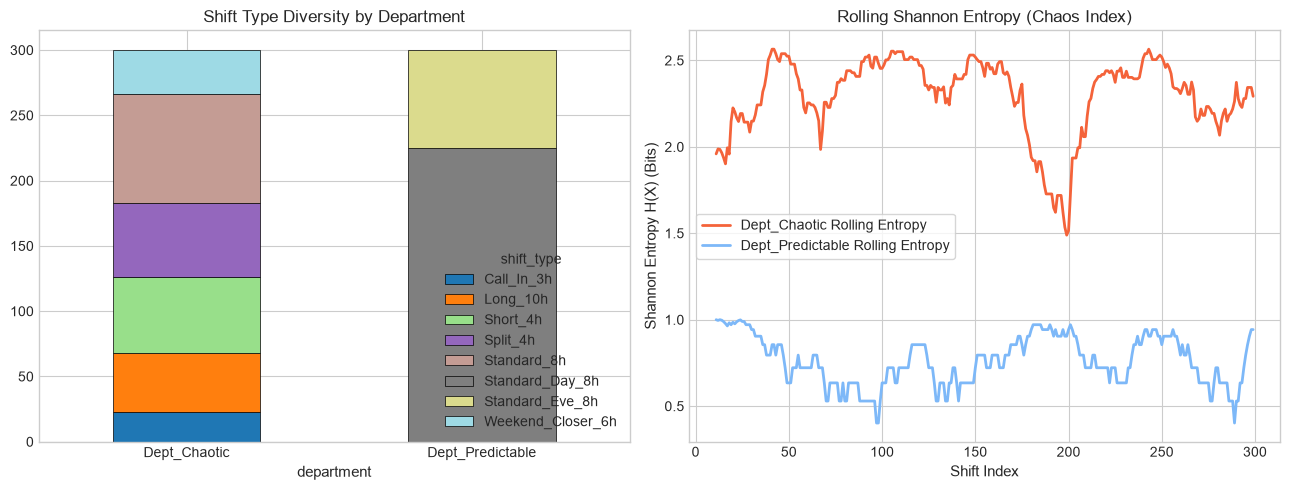

In [15]:
schedules_df = generate_shift_schedules(n_records=600, seed=42)
schedules_df['chaos_index'] = rolling_shannon_entropy(schedules_df, val_col='shift_type', window=25, group_col='department', normalize=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
type_counts = schedules_df.groupby(['department', 'shift_type']).size().unstack(fill_value=0)
type_counts.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20', edgecolor='black', linewidth=0.5)
ax1.set_title('Shift Type Diversity by Department')
ax1.tick_params(axis='x', rotation=0)

for dept, grp in schedules_df.groupby('department'):
    color = PALETTE['light_blue'] if dept == 'Dept_Predictable' else PALETTE['salmon']
    ax2.plot(grp.reset_index(drop=True)['chaos_index'], label=f'{dept} Rolling Entropy', color=color, linewidth=2.0)
ax2.set_title('Rolling Shannon Entropy (Chaos Index)')
ax2.set_xlabel('Shift Index')
ax2.set_ylabel('Shannon Entropy H(X) (Bits)')
ax2.legend(frameon=True)
plt.tight_layout()
plt.show()

### Feature 14: GARCH(1,1) Volatility Index

#### The Concept
Models autoregressive conditional heteroskedasticity in labor demands:

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Crucially, we fit GARCH on **unexpected scheduling variance shocks** ($\epsilon_t = \text{actual} - \text{scheduled hours}$) rather than raw headcount levels. This avoids artificial variance plateaus and isolates true operational volatility clustering.

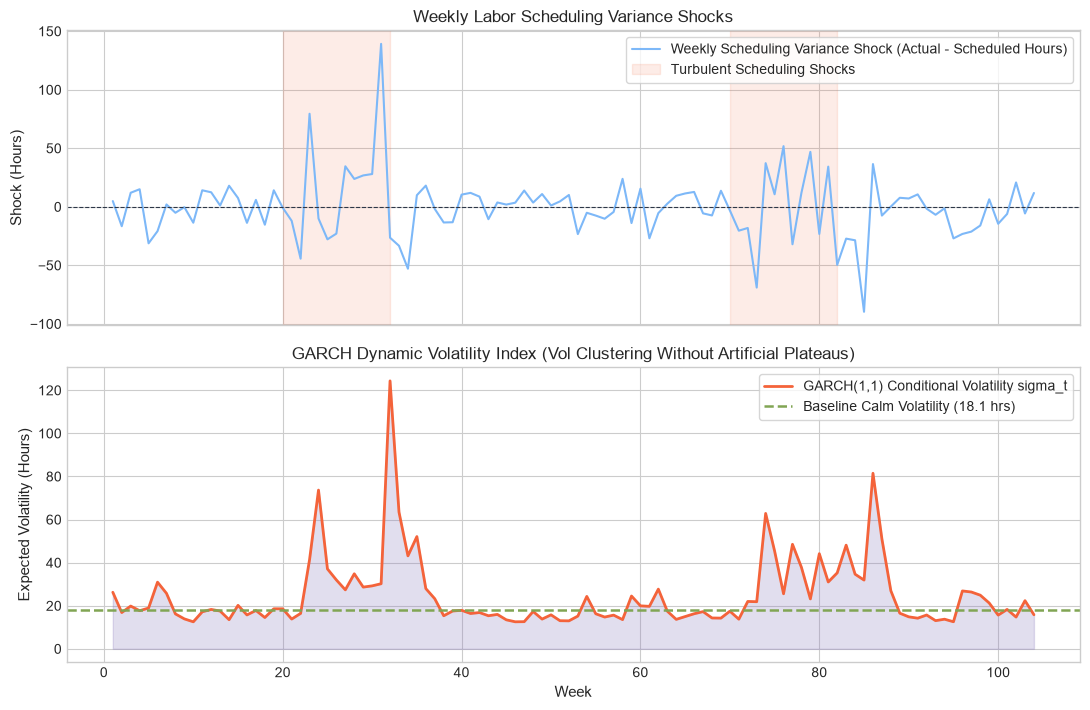

In [16]:
# Fit GARCH on unexpected scheduling variance shocks (epsilon_t = actual - scheduled)
# to isolate dynamic volatility clustering rather than structural level trends
garch_vol, garch_meta = fit_garch_volatility(labor_df['labor_shock'], p=1, q=1)
labor_df['garch_volatility'] = garch_vol

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.2), sharex=True)
ax1.plot(labor_df['week'], labor_df['labor_shock'], color=PALETTE['light_blue'], label='Weekly Scheduling Variance Shock (Actual - Scheduled Hours)', linewidth=1.5)
ax1.axhline(0, color=PALETTE['dark_slate'], linestyle='--', linewidth=0.8)
# Shade high turbulence shock regimes
ax1.axvspan(20, 32, color=PALETTE['salmon'], alpha=0.12, label='Turbulent Scheduling Shocks')
ax1.axvspan(70, 82, color=PALETTE['salmon'], alpha=0.12)
ax1.set_title('Weekly Labor Scheduling Variance Shocks')
ax1.set_ylabel('Shock (Hours)')
ax1.legend(loc='upper right', frameon=True)

ax2.plot(labor_df['week'], labor_df['garch_volatility'], color=PALETTE['salmon'], label='GARCH(1,1) Conditional Volatility sigma_t', linewidth=2.0)
ax2.fill_between(labor_df['week'], 0, labor_df['garch_volatility'], color=PALETTE['lilac'], alpha=0.25)
baseline_vol = float(np.median(labor_df['garch_volatility']))
ax2.axhline(baseline_vol, color=PALETTE['sage_green'], linestyle='--', linewidth=1.8, label=f'Baseline Calm Volatility ({baseline_vol:.1f} hrs)')
ax2.set_title('GARCH Dynamic Volatility Index (Vol Clustering Without Artificial Plateaus)')
ax2.set_xlabel('Week')
ax2.set_ylabel('Expected Volatility (Hours)')
ax2.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

### Feature 15: Hawkes Process Intensity (The Contagion Feature)

#### The Concept
Models self-exciting absenteeism and turnover waves:

$$\lambda(t) = \mu + \sum_{t_i < t} \alpha e^{-\beta (t - t_i)}$$

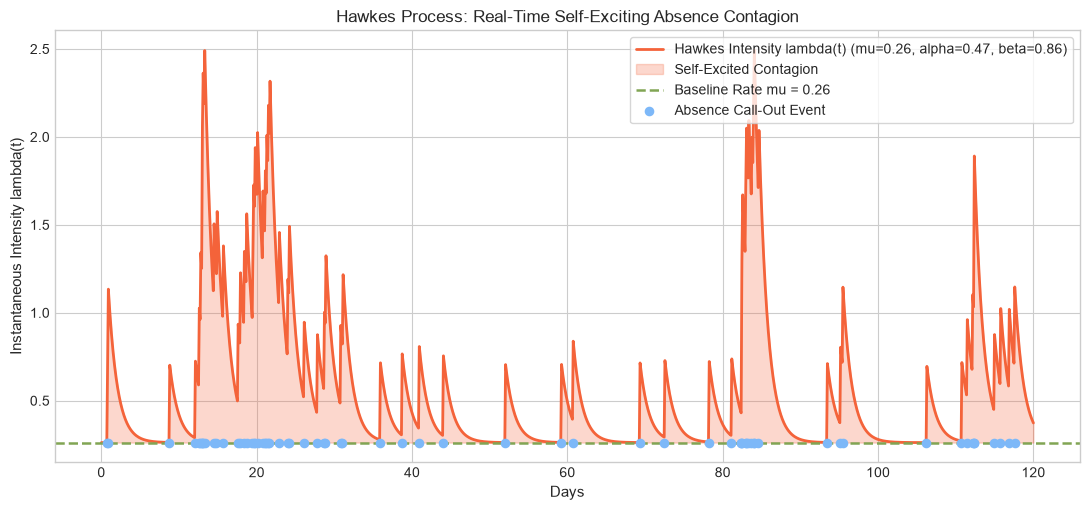

In [17]:
callout_events = generate_callout_events(days=120, seed=42)
hawkes = HawkesProcessContagion()
hawkes.fit(callout_events, max_t=120.0)
eval_time = np.linspace(0, 120, 1200)
intensity_curve = hawkes.predict_intensity(eval_time)

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(eval_time, intensity_curve, color=PALETTE['salmon'], label=f'Hawkes Intensity lambda(t) (mu={hawkes.mu:.2f}, alpha={hawkes.alpha:.2f}, beta={hawkes.beta:.2f})', linewidth=2.0)
ax.fill_between(eval_time, hawkes.mu, intensity_curve, color=PALETTE['salmon'], alpha=0.25, label='Self-Excited Contagion')
ax.axhline(hawkes.mu, color=PALETTE['sage_green'], linestyle='--', linewidth=1.8, label=f'Baseline Rate mu = {hawkes.mu:.2f}')
ax.scatter(callout_events, [hawkes.mu] * len(callout_events), color=PALETTE['light_blue'], s=35, zorder=6, label='Absence Call-Out Event')
ax.set_title('Hawkes Process: Real-Time Self-Exciting Absence Contagion')
ax.set_xlabel('Days')
ax.set_ylabel('Instantaneous Intensity lambda(t)')
ax.legend(frameon=True)
plt.show()

### Feature 16: Hidden Markov Model (HMM) Latent States

#### The Concept
Observing continuous metrics (weekly overtime hours and call-out rates), the underlying condition is a hidden operational regime. The HMM infers the probability that the system has entered a new latent state:

- **State 0 (Baseline Normal)**: Modest overtime, low call-outs.
- **State 1 (Planned Holiday Surge)**: High overtime, low call-outs, scheduled throughput.
- **State 2 (Understaffed Attrition Spiral)**: High overtime, high call-outs, unstable friction.

Instead of feeding raw overtime into downstream risk models, we feed the inferred $P(\text{State 2} = \text{Attrition Crisis})$, allowing models to recognize that overtime during a planned peak is benign, while identical overtime during an attrition spiral is an emergency.

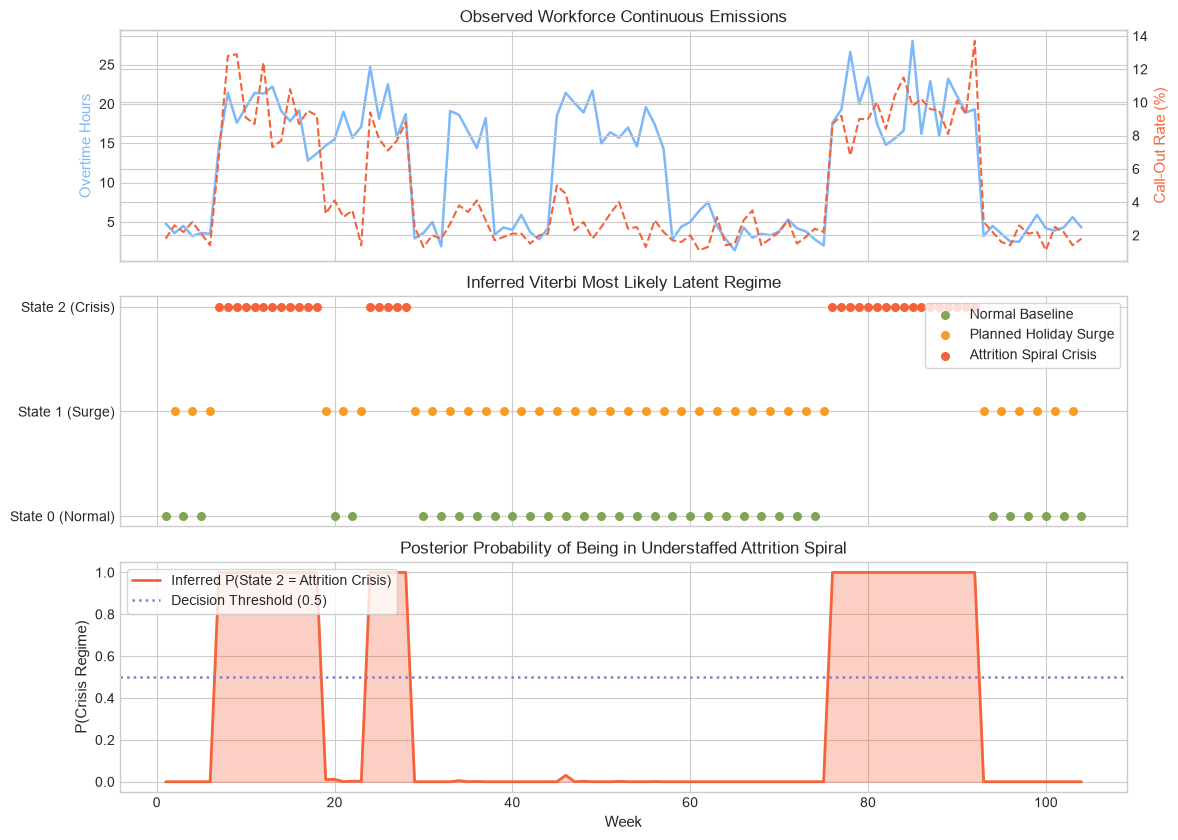

HMM Operational Profile by Latent Regime:
 latent_state  prevalence_pct  mean_weekly_overtime_hours  std_weekly_overtime_hours  mean_absence_callout_rate  std_absence_callout_rate
            0       32.692308                    7.674824                   5.995370                   0.023175                  0.019392
            1       34.615385                    8.945106                   6.889665                   0.023638                  0.018434
            2       32.692308                   19.330492                   3.516523                   0.094006                  0.024173


In [18]:
regime_df, true_states = generate_regime_workforce_timeseries(n_weeks=104, seed=42)
scored_regimes, profile_summary, hmm_meta = fit_workforce_hmm_regimes(
    regime_df,
    emission_cols=['weekly_overtime_hours', 'absence_callout_rate'],
    n_components=3,
    seed=42,
)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True)

# Panel 1: Observed Continuous Emissions
ax1.plot(regime_df['week'], regime_df['weekly_overtime_hours'], color=PALETTE['light_blue'], label='Weekly Overtime Hours', linewidth=1.8)
ax1_twin = ax1.twinx()
ax1_twin.plot(regime_df['week'], regime_df['absence_callout_rate'] * 100, color=PALETTE['salmon'], label='Call-out Rate (%)', linestyle='--', linewidth=1.5)
ax1.set_ylabel('Overtime Hours', color=PALETTE['light_blue'])
ax1_twin.set_ylabel('Call-Out Rate (%)', color=PALETTE['salmon'])
ax1.set_title('Observed Workforce Continuous Emissions')

# Panel 2: Inferred Viterbi Most Likely State
state_names = {0: 'Normal Baseline', 1: 'Planned Holiday Surge', 2: 'Attrition Spiral Crisis'}
colors_state = [PALETTE['sage_green'], PALETTE['light_orange'], PALETTE['salmon']]
for s in range(3):
    mask = scored_regimes['hmm_latent_state'] == s
    ax2.scatter(regime_df.loc[mask, 'week'], scored_regimes.loc[mask, 'hmm_latent_state'], label=state_names[s], color=colors_state[s], s=30)
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['State 0 (Normal)', 'State 1 (Surge)', 'State 2 (Crisis)'])
ax2.set_title('Inferred Viterbi Most Likely Latent Regime')
ax2.legend(loc='upper right', frameon=True)

# Panel 3: Posterior Probability of Crisis State 2
ax3.plot(regime_df['week'], scored_regimes['prob_latent_state_2'], color=PALETTE['salmon'], linewidth=2.0, label='Inferred P(State 2 = Attrition Crisis)')
ax3.fill_between(regime_df['week'], 0, scored_regimes['prob_latent_state_2'], color=PALETTE['salmon'], alpha=0.30)
ax3.axhline(0.5, color=PALETTE['lilac'], linestyle=':', linewidth=1.8, label='Decision Threshold (0.5)')
ax3.set_title('Posterior Probability of Being in Understaffed Attrition Spiral')
ax3.set_xlabel('Week')
ax3.set_ylabel('P(Crisis Regime)')
ax3.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()
print('HMM Operational Profile by Latent Regime:')
print(profile_summary.to_string(index=False))

### Feature 17: The Bradford Factor (Absenteeism Friction Score)

#### Where It Fits
Leave of absence (LOA) modeling, burnout prediction, operational friction quantification, and labor scheduling optimization.

#### The Concept
A classic workforce management formulation designed to measure the disruptive impact of short, frequent, and unplanned absences over a rolling evaluation period (conventionally 52 weeks, but configurable to 53 weeks for leap/fiscal years):

$$B = S^2 \times D$$

Where:
- $S$ is the total count of distinct absence spells (discrete instances or streaks) in the rolling window.
- $D$ is the cumulative total number of days absent across all spells in the rolling window.

#### The Application: Isolating Unpredictable Scheduling Friction
Workforce capacity models inherently differentiate between predictable long-term leaves and volatile short-term call-outs:
- **Planned Medical Leave**: An associate taking a single 10-day planned medical leave produces:
  $$B_{\text{planned}} = 1^2 \times 10 = 10 \quad (\text{Low Friction})$$
- **Chronic Unplanned Call-outs**: An associate taking ten separate 1-day unplanned call-outs produces:
  $$B_{\text{unplanned}} = 10^2 \times 10 = 1000 \quad (\text{Critical Friction})$$

While both associates logged exactly 10 missed days ($D=10$), the chronic call-out pattern introduces a **100x higher friction multiplier** ($S^2 = 100$) onto shift supervisors. This feature explicitly isolates the operational friction of unpredictable behavior for downstream schedule-optimization, overtime relief planning, and burnout intervention models.

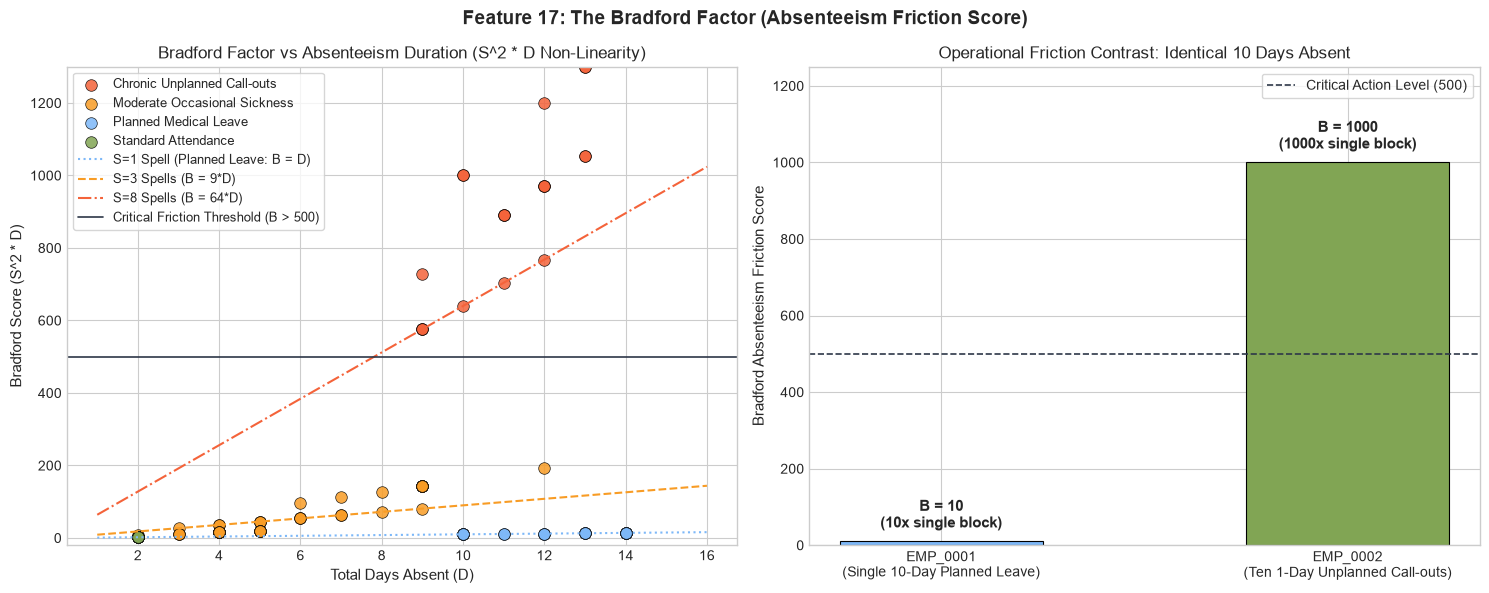

Bradford Risk Distribution across Simulated Workforce:
bradford_risk_band
Low Friction         54
Critical Friction    28
Moderate Friction    18

Key Archetype Case Contrast:
employee_id                   archetype  absence_spells  total_days_absent  bradford_score bradford_risk_band  disruption_multiplier
   EMP_0001       Planned Medical Leave               1                 10              10       Low Friction                    1.0
   EMP_0002 Chronic Unplanned Call-outs              10                 10            1000  Critical Friction                  100.0


In [19]:
from data.synthetic_generators import generate_bradford_factor_workforce
from people_analytics_toolkit.chaos import calculate_bradford_factor

# Generate absence spell dataset across workforce
spell_df, employees_meta = generate_bradford_factor_workforce(n_employees=120, window_weeks=52, seed=42)

# Compute Bradford Factor metrics over 52-week rolling window
bradford_results = calculate_bradford_factor(
    spell_df,
    employee_col='employee_id',
    start_date_col='absence_start_date',
    end_date_col='absence_end_date',
    planned_col='is_planned',
    window_weeks=52,
    as_of_date='2026-10-01',
)
merged_df = bradford_results.merge(employees_meta[['employee_id', 'archetype', 'department']], on='employee_id')

# 2-Panel Bradford Factor Absenteeism Friction Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: S^2 * D Bradford Score vs Total Days Absent (Quadratic Friction Curves)
archetype_colors = {
    'Planned Medical Leave': PALETTE['light_blue'],
    'Chronic Unplanned Call-outs': PALETTE['salmon'],
    'Moderate Occasional Sickness': PALETTE['light_orange'],
    'Standard Attendance': PALETTE['sage_green'],
}

for arch, grp in merged_df.groupby('archetype'):
    ax1.scatter(
        grp['total_days_absent'],
        grp['bradford_score'],
        label=arch,
        color=archetype_colors.get(arch, PALETTE['muted_gray']),
        s=70,
        alpha=0.85,
        edgecolors='black',
        linewidth=0.5,
    )

# Plot reference lines for S=1 (single spell), S=3, S=8
d_range = np.linspace(1, 16, 100)
ax1.plot(d_range, (1**2) * d_range, linestyle=':', color=PALETTE['light_blue'], label='S=1 Spell (Planned Leave: B = D)')
ax1.plot(d_range, (3**2) * d_range, linestyle='--', color=PALETTE['light_orange'], label='S=3 Spells (B = 9*D)')
ax1.plot(d_range, np.minimum(1400, (8**2) * d_range), linestyle='-.', color=PALETTE['salmon'], label='S=8 Spells (B = 64*D)')

ax1.axhline(500, color=PALETTE['dark_slate'], linestyle='-', linewidth=1.2, label='Critical Friction Threshold (B > 500)')
ax1.set_xlabel('Total Days Absent (D)')
ax1.set_ylabel('Bradford Score (S^2 * D)')
ax1.set_title('Bradford Factor vs Absenteeism Duration (S^2 * D Non-Linearity)')
ax1.set_ylim(-20, 1300)
ax1.legend(loc='upper left', frameon=True, fontsize=9)

# Panel 2: Direct Contrast: Planned 10-Day Leave vs Chronic 10-Day Call-outs
emp1 = merged_df[merged_df['employee_id'] == 'EMP_0001'].iloc[0]
emp2 = merged_df[merged_df['employee_id'] == 'EMP_0002'].iloc[0]

compare_x = ['EMP_0001\n(Single 10-Day Planned Leave)', 'EMP_0002\n(Ten 1-Day Unplanned Call-outs)']
bar_scores = [emp1['bradford_score'], emp2['bradford_score']]
bar_colors = [PALETTE['light_blue'], PALETTE['sage_green']]

bars = ax2.bar(compare_x, bar_scores, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.5)
ax2.set_ylabel('Bradford Absenteeism Friction Score')
ax2.set_title('Operational Friction Contrast: Identical 10 Days Absent')
for bar, score in zip(bars, bar_scores):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 25, f'B = {score}\n({score}x single block)',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.axhline(500, color=PALETTE['dark_slate'], linestyle='--', linewidth=1.2, label='Critical Action Level (500)')
ax2.set_ylim(0, 1250)
ax2.legend(loc='upper right', frameon=True)

plt.suptitle('The Bradford Factor (Absenteeism Friction Score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Bradford Risk Distribution across Simulated Workforce:')
print(merged_df['bradford_risk_band'].value_counts().to_string())
print('\nKey Archetype Case Contrast:')
contrast_df = merged_df[merged_df['employee_id'].isin(['EMP_0001', 'EMP_0002'])][
    ['employee_id', 'archetype', 'absence_spells', 'total_days_absent', 'bradford_score', 'bradford_risk_band', 'disruption_multiplier']
]
print(contrast_df.to_string(index=False))

# Part 4: Detecting Structural Anomalies, Density & Sequences

Global models struggle with localized cohort density, multi-metric systemic weirdness, departmental role drift, and trajectory matching across sequences containing gaps.

---

### Feature 18: Autoencoder Reconstruction Error (The Weirdness Index)

#### The Concept
Compresses 20 correlated operational dimensions into a 4D bottleneck. Units whose internal ecosystem structurally decouples incur high Reconstruction Loss (MSE):

$$\text{MSE}_i = \frac{1}{D} \sum_{j=1}^D (x_{i, j} - \hat{x}_{i, j})^2$$

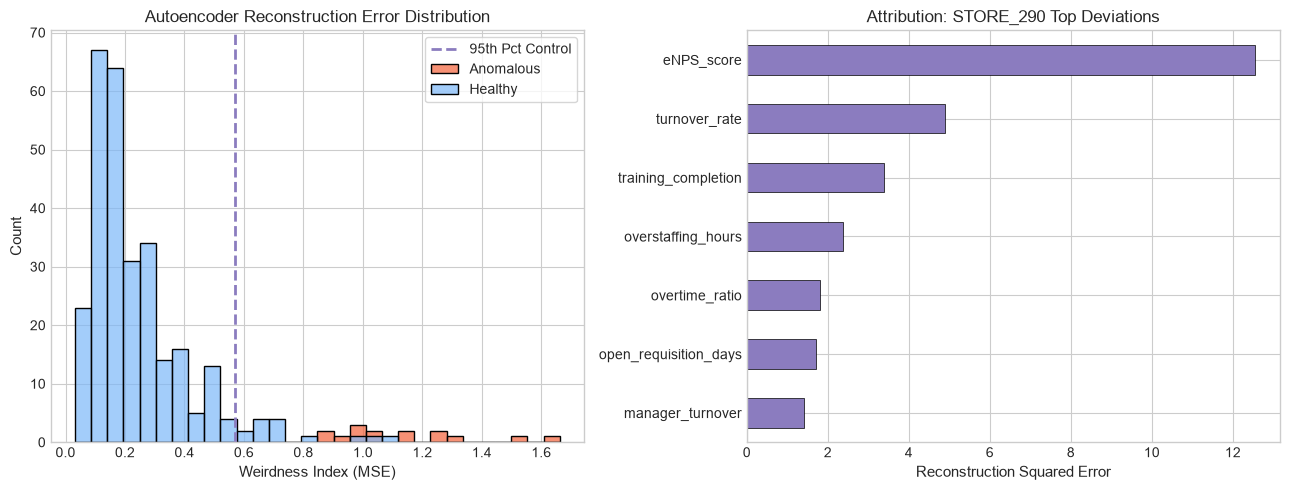

In [20]:
store_profiles, is_anom_series = generate_store_profiles_multivariate(n_stores=300, seed=42)
store_profiles['is_true_anomaly'] = is_anom_series
feature_cols = [c for c in store_profiles.columns if c not in ['store_id', 'is_true_anomaly']]
detector = AutoencoderWeirdnessDetector(latent_dim=4, hidden_dim=12, epochs=50, seed=42)
detector.fit(store_profiles[feature_cols])
store_profiles['weirdness_index'], error_breakdown = detector.transform(store_profiles[feature_cols])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(data=store_profiles, x='weirdness_index', hue='is_true_anomaly', bins=30, ax=ax1, palette={0: PALETTE['light_blue'], 1: PALETTE['salmon']}, alpha=0.7)
threshold_95 = np.percentile(store_profiles.loc[store_profiles['is_true_anomaly'] == 0, 'weirdness_index'], 95)
ax1.axvline(threshold_95, color=PALETTE['lilac'], linestyle='--', linewidth=2, label=f'95th Pct Control ({threshold_95:.2f})')
ax1.set_title('Autoencoder Reconstruction Error Distribution')
ax1.set_xlabel('Weirdness Index (MSE)')
ax1.legend(['95th Pct Control', 'Anomalous', 'Healthy'], frameon=True)

top_anom_idx = store_profiles['weirdness_index'].idxmax()
top_features = error_breakdown.loc[top_anom_idx].sort_values(ascending=False).head(7)
top_features.plot(kind='barh', ax=ax2, color=PALETTE['lilac'], edgecolor='black', linewidth=0.5)
ax2.invert_yaxis()
ax2.set_title(f'Attribution: {store_profiles.loc[top_anom_idx, "store_id"]} Top Deviations')
ax2.set_xlabel('Reconstruction Squared Error')
plt.tight_layout()
plt.show()

### Feature 19: Local Outlier Factor (LOF via PyOD)

#### The Concept
While Autoencoders evaluate global multi-metric reconstruction, Local Outlier Factor (LOF) measures **local density deviation** relative to a point's $k$-nearest neighbors:

$$LOF_k(p) = \frac{\sum_{o \in N_k(p)} \frac{\text{lrd}(o)}{\text{lrd}(p)}}{|N_k(p)|}$$

#### The Application
An associate's salary raise of 13% looks completely unremarkable when viewed against the entire company (where new junior hires routinely receive 10-15% raises). However, within their localized peer cluster (associates with 8 years of tenure and a standard Performance Rating of 3, who typically receive 2.5-3.5% raises), this compensation velocity is an extreme local density anomaly.

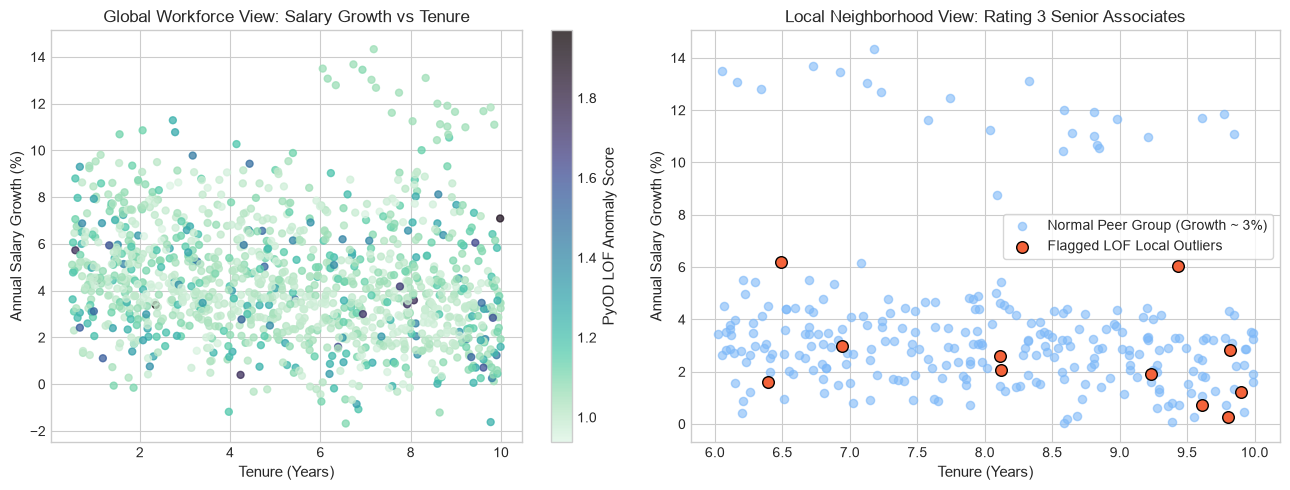

PyOD LOF Decision Threshold: 1.4038
Total Local Density Outliers Detected: 36 (True injected: 25)


In [21]:
comp_df, is_local_anom = generate_compensation_velocity_data(n_employees=1200, seed=42)
lof_scores, is_outlier, lof_meta = fit_pyod_local_outlier_factor(
    comp_df,
    feature_cols=['tenure_years', 'performance_rating', 'annual_salary_growth_pct', 'promotion_velocity'],
    n_neighbors=25,
    contamination=0.03,
)
comp_df['lof_score'] = lof_scores
comp_df['is_lof_outlier'] = is_outlier
comp_df['is_true_local_anomaly'] = is_local_anom

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Global View (Anomalies blend in)
scatter = ax1.scatter(comp_df['tenure_years'], comp_df['annual_salary_growth_pct'], c=comp_df['lof_score'], cmap='mako_r', s=25, alpha=0.75)
ax1.set_title('Global Workforce View: Salary Growth vs Tenure')
ax1.set_xlabel('Tenure (Years)')
ax1.set_ylabel('Annual Salary Growth (%)')
plt.colorbar(scatter, ax=ax1, label='PyOD LOF Anomaly Score')

# Panel 2: Zoomed Peer Cluster (Tenure > 6 Years, Rating 3)
peer_cluster = comp_df[(comp_df['performance_rating'] == 3) & (comp_df['tenure_years'] > 6.0)]
normal_peers = peer_cluster[peer_cluster['is_lof_outlier'] == 0]
outlier_peers = peer_cluster[peer_cluster['is_lof_outlier'] == 1]

ax2.scatter(normal_peers['tenure_years'], normal_peers['annual_salary_growth_pct'], color=PALETTE['light_blue'], alpha=0.6, label='Normal Peer Group (Growth ~ 3%)', s=35)
ax2.scatter(outlier_peers['tenure_years'], outlier_peers['annual_salary_growth_pct'], color=PALETTE['salmon'], edgecolors='black', label='Flagged LOF Local Outliers', s=70, zorder=5)
ax2.set_title('Local Neighborhood View: Rating 3 Senior Associates')
ax2.set_xlabel('Tenure (Years)')
ax2.set_ylabel('Annual Salary Growth (%)')
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()
print(f'PyOD LOF Decision Threshold: {lof_meta["threshold"]:.4f}')
print(f'Total Local Density Outliers Detected: {is_outlier.sum()} (True injected: {is_local_anom.sum()})')

### Feature 20: Kullback-Leibler (KL) Divergence (The Drift Index)

#### The Concept
Quantifies departmental staffing distortion between local store distribution $P$ and corporate benchmark $Q$:

$$D_{\text{KL}}(P \parallel Q) = \sum_{x \in \mathcal{X}} P(x) \ln\left(\frac{P(x)}{Q(x) + \epsilon}\right)$$

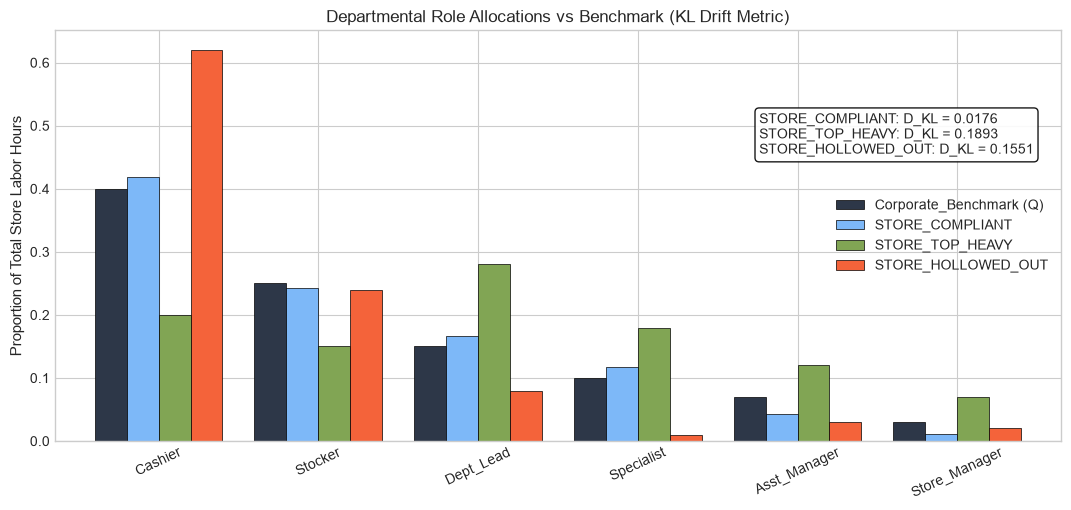

In [22]:
q_benchmark, stores_p, roles = generate_role_distributions(seed=42)
kl_results = {s: calculate_kl_divergence(p, q_benchmark) for s, p in stores_p.items()}
plot_df = pd.DataFrame(stores_p, index=roles)
plot_df.insert(0, 'Corporate_Benchmark (Q)', q_benchmark)

fig, ax = plt.subplots(figsize=(11, 5.2))
# Custom palette for the benchmark and stores
bar_colors = [PALETTE['dark_slate'], PALETTE['light_blue'], PALETTE['sage_green'], PALETTE['salmon']]
plot_df.plot(kind='bar', ax=ax, width=0.8, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_title('Departmental Role Allocations vs Benchmark (KL Drift Metric)')
ax.set_ylabel('Proportion of Total Store Labor Hours')
ax.tick_params(axis='x', rotation=25)
info_text = '\n'.join([f'{k}: D_KL = {v:.4f}' for k, v in kl_results.items()])
ax.text(0.70, 0.70, info_text, transform=ax.transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.tight_layout()
plt.show()

### Feature 21: Dynamic Time Warping (DTW) Distance

#### The Concept
Non-linear temporal alignment finding structural curve similarity despite seasonal phase shifts.

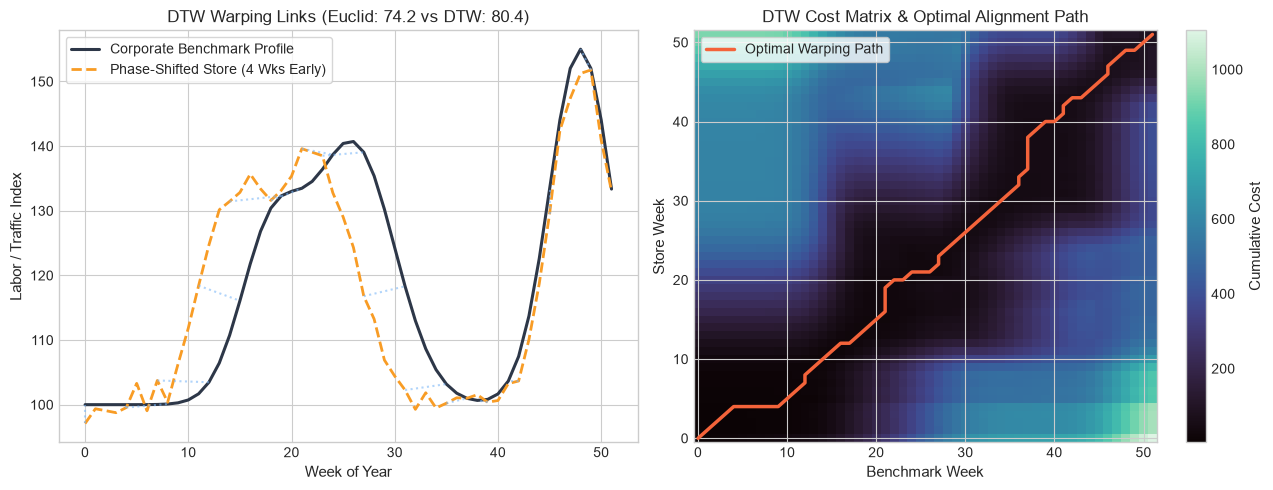

In [23]:
benchmark_curve, store_curves = generate_seasonal_curves(seed=42)
s_shifted = store_curves['STORE_PHASE_SHIFTED']
dist_shifted_dtw, path_shifted, cost_matrix = compute_dtw_distance(s_shifted, benchmark_curve)
dist_shifted_euclid = float(np.linalg.norm(s_shifted - benchmark_curve))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(benchmark_curve, color=PALETTE['dark_slate'], label='Corporate Benchmark Profile', linewidth=2.2)
ax1.plot(s_shifted, color=PALETTE['light_orange'], linestyle='--', label='Phase-Shifted Store (4 Wks Early)', linewidth=2.0)
for (idx1, idx2) in path_shifted[::4]:
    ax1.plot([idx1, idx2], [s_shifted[idx1], benchmark_curve[idx2]], color=PALETTE['light_blue'], linestyle=':', alpha=0.6)
ax1.set_title(f'DTW Warping Links (Euclid: {dist_shifted_euclid:.1f} vs DTW: {dist_shifted_dtw:.1f})')
ax1.set_xlabel('Week of Year')
ax1.set_ylabel('Labor / Traffic Index')
ax1.legend(frameon=True)

im = ax2.imshow(cost_matrix, origin='lower', cmap='mako', aspect='auto')
path_x, path_y = zip(*path_shifted)
ax2.plot(path_y, path_x, color=PALETTE['salmon'], linewidth=2.5, label='Optimal Warping Path')
ax2.set_title('DTW Cost Matrix & Optimal Alignment Path')
ax2.set_xlabel('Benchmark Week')
ax2.set_ylabel('Store Week')
ax2.legend(frameon=True, loc='upper left')
plt.colorbar(im, ax=ax2, label='Cumulative Cost')
plt.tight_layout()
plt.show()

### Feature 22: Longest Common Subsequence (LCSS) & Edit Distance on Real Sequences (EDR)

#### The Concept
While Dynamic Time Warping (DTW) aligns points by stretching the time axis, it is heavily penalized by localized noise, missing intervals, or temporal gaps. In workforce scheduling and career path analysis, an associate taking a 2-week leave of absence or vacation creates a massive spike in DTW distance.

Longest Common Subsequence (LCSS) establishes a spatial matching threshold $\epsilon$ and temporal window $\delta$, matching two values if $|x_i - y_j| \le \epsilon$ and $|i - j| \le \delta$:

$$D_{\text{LCSS}}(X, Y) = 1 - \frac{\text{LCSS}(X, Y)}{\min(|X|, |Y|)}$$

Edit Distance on Real Sequences (EDR) penalizes insertions/deletions with cost 1 and matching with cost 0. Both algorithms tolerate gaps, correctly matching the underlying career/shift trajectory to peers.

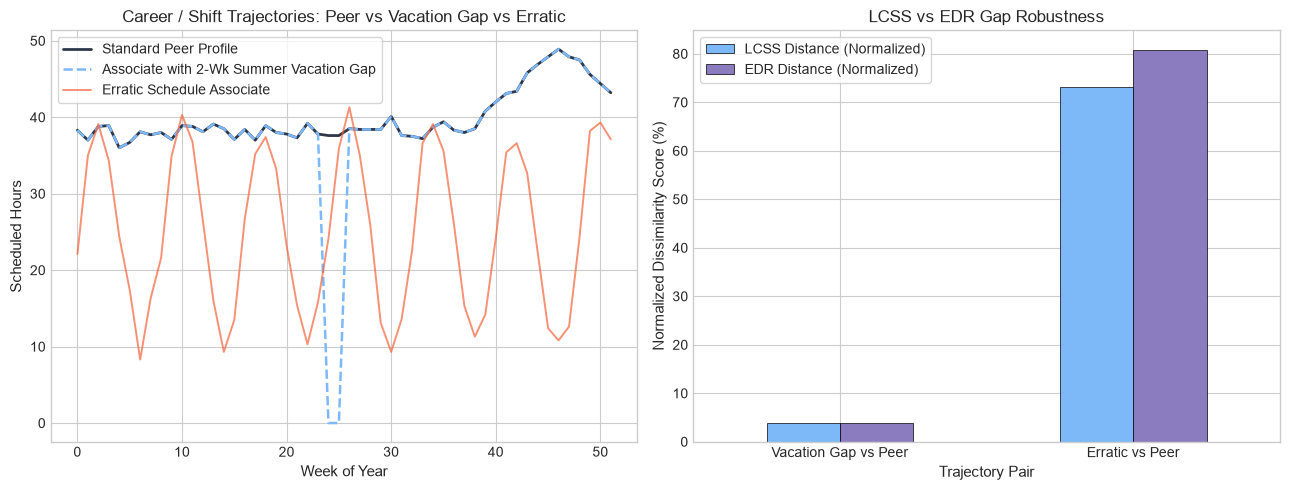

Vacation Gap -> DTW Distance: 75.2 (Heavily penalized by 2-week drop!)
Vacation Gap -> LCSS Normalized Distance: 0.038 | EDR Distance: 0.038 (Correctly matches peer trajectory!)
Erratic Schedule -> LCSS Normalized Distance: 0.731 | EDR Distance: 0.808


In [24]:
shift_seqs = generate_career_shift_sequences(n_weeks=52, seed=42)
s_peer = shift_seqs['benchmark_peer']
s_vacation = shift_seqs['associate_vacation_gap']
s_erratic = shift_seqs['associate_erratic_schedule']

# Compute distances across algorithms
dtw_vac, _, _ = compute_dtw_distance(s_vacation, s_peer)
dtw_err, _, _ = compute_dtw_distance(s_erratic, s_peer)

_, lcss_vac_dist = compute_lcss_distance(s_vacation, s_peer, epsilon=2.5, delta=4)
_, lcss_err_dist = compute_lcss_distance(s_erratic, s_peer, epsilon=2.5, delta=4)

edr_vac_dist = compute_edr_distance(s_vacation, s_peer, epsilon=2.5)
edr_err_dist = compute_edr_distance(s_erratic, s_peer, epsilon=2.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Sequence Trajectories
ax1.plot(s_peer, label='Standard Peer Profile', color=PALETTE['dark_slate'], linewidth=2.0)
ax1.plot(s_vacation, label='Associate with 2-Wk Summer Vacation Gap', color=PALETTE['light_blue'], linestyle='--', linewidth=1.8)
ax1.plot(s_erratic, label='Erratic Schedule Associate', color=PALETTE['salmon'], alpha=0.7, linewidth=1.4)
ax1.set_title('Career / Shift Trajectories: Peer vs Vacation Gap vs Erratic')
ax1.set_xlabel('Week of Year')
ax1.set_ylabel('Scheduled Hours')
ax1.legend(frameon=True)

# Panel 2: Comparative Metric Sensitivity to Gaps
comp_metrics = pd.DataFrame({
    'Trajectory Pair': ['Vacation Gap vs Peer', 'Erratic vs Peer'],
    'DTW Distance (Distorted)': [dtw_vac, dtw_err],
    'LCSS Distance (Normalized)': [lcss_vac_dist * 100, lcss_err_dist * 100],
    'EDR Distance (Normalized)': [edr_vac_dist * 100, edr_err_dist * 100],
}).set_index('Trajectory Pair')

comp_metrics[['LCSS Distance (Normalized)', 'EDR Distance (Normalized)']].plot(kind='bar', ax=ax2, color=[PALETTE['light_blue'], PALETTE['lilac']], edgecolor='black', linewidth=0.5)
ax2.set_title('LCSS vs EDR Gap Robustness')
ax2.set_ylabel('Normalized Dissimilarity Score (%)')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()
print(f'Vacation Gap -> DTW Distance: {dtw_vac:.1f} (Heavily penalized by 2-week drop!)')
print(f'Vacation Gap -> LCSS Normalized Distance: {lcss_vac_dist:.3f} | EDR Distance: {edr_vac_dist:.3f} (Correctly matches peer trajectory!)')
print(f'Erratic Schedule -> LCSS Normalized Distance: {lcss_err_dist:.3f} | EDR Distance: {edr_err_dist:.3f}')

### Feature 50: Multivariate Mahalanobis Distance (Covariance-Scaled Anomaly Detection & Chi-Squared Outliers)

#### The Concept
Standard Euclidean distance assumes features are orthogonal and isotropic (spherical variance). In enterprise workforce intelligence, operational metrics are deeply correlated—for example, higher tenure naturally correlates with higher compensation, and seasonal overtime surges co-occur with staffing shortages.

When metrics correlate, Euclidean distance suffers from two fatal failure modes:
1. **False Alarms (Swamping)**: Flagging legitimate top-performing high-tenure associates simply because their absolute metric values lie far from the company average.
2. **Missed Anomalies (Masking)**: Failing to detect an associate whose individual metrics look ordinary in isolation, but whose combination represents an operational decoupling (e.g. low tenure but extreme promotion velocity and compensation spikes).

**Mahalanobis Distance** measures statistical distance in units of standard deviation along the principal axes of the feature covariance ellipsoid:

79815D_M(x, \mu, \Sigma) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}79815

#### Hypothesis Testing & Chi-Squared Confidence Ellipsoids
Under the assumption of multivariate normality, the squared Mahalanobis distance follows a Chi-Squared distribution with degrees of freedom equal to feature dimensionality $:

79815D_M^2(x) \sim \chi^2_p79815

This provides an exact, rigorous statistical hypothesis test for anomaly detection:

79815	ext{is\_outlier} \iff D_M^2(x) > \chi^2_{p, 1 - lpha} \iff p	ext{-value} = 1 - F_{\chi^2_p}(D_M^2) < lpha79815

Using **Minimum Covariance Determinant (MCD)** (), the location $\mu$ and scatter $\Sigma$ are estimated from the cleanest central subset of data, preventing severe outliers from dragging the centroid and masking themselves.

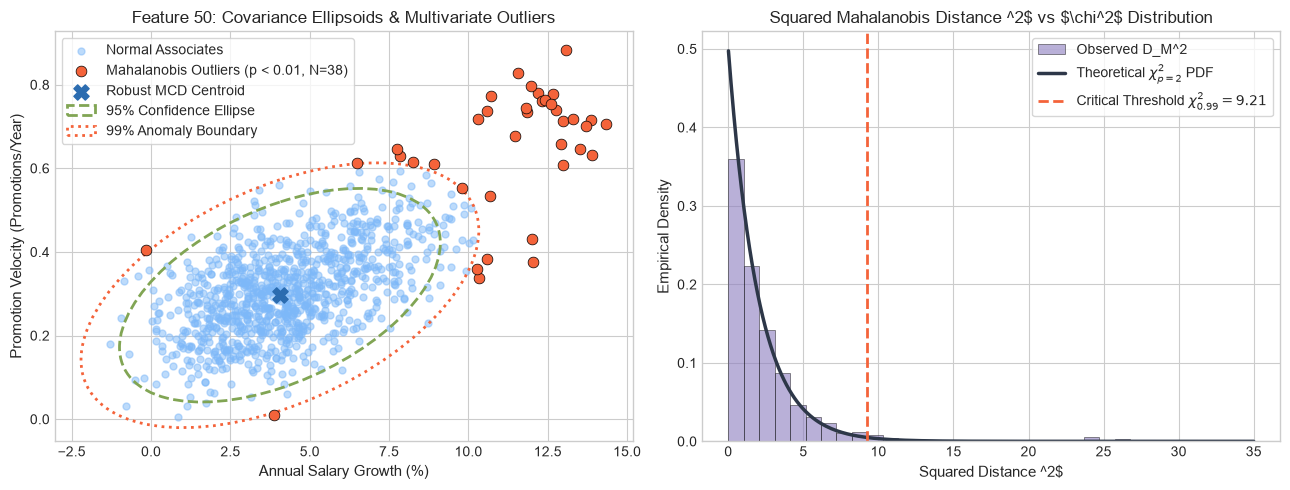

Robust MCD Centroid: Salary Growth = 4.06%, Promotion Velocity = 0.30
Chi-Squared Critical Value (alpha=0.01, df=2): 9.210 (Threshold Distance D_M = 3.03)
Total Multivariate Anomalies Identified: 38 / 1000 associates (3.8%)


In [25]:
from matplotlib.patches import Ellipse
from scipy.stats import chi2
from people_analytics_toolkit.anomalies import calculate_mahalanobis_distance

# 1. Evaluate multivariate compensation velocity metrics
comp_df, is_local_anom = generate_compensation_velocity_data(n_employees=1000, seed=42)
feature_cols = ["annual_salary_growth_pct", "promotion_velocity"]

# 2. Calculate robust Mahalanobis distance with chi-squared hypothesis testing
dist, is_outlier, meta = calculate_mahalanobis_distance(
    comp_df,
    feature_cols=feature_cols,
    robust=True,
    significance_level=0.01,
)
comp_df["mahalanobis_dist"] = dist
comp_df["is_mahal_outlier"] = is_outlier

# 3. Plot Chi-Squared Confidence Ellipsoids & Empirical vs Theoretical Distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Covariance confidence ellipses
cov = meta["covariance"].to_numpy()
mu = meta["mean"].to_numpy()
vals, vecs = np.linalg.eigh(cov)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

normal_mask = ~is_outlier
ax1.scatter(comp_df.loc[normal_mask, feature_cols[0]], comp_df.loc[normal_mask, feature_cols[1]],
            color=PALETTE["light_blue"], alpha=0.5, s=25, label="Normal Associates")
ax1.scatter(comp_df.loc[is_outlier, feature_cols[0]], comp_df.loc[is_outlier, feature_cols[1]],
            color=PALETTE["salmon"], edgecolors="black", linewidth=0.5, s=60,
            label=f"Mahalanobis Outliers (p < 0.01, N={meta['n_outliers']})", zorder=5)
ax1.scatter(mu[0], mu[1], color=PALETTE["royal_blue"], s=120, marker="X", label="Robust MCD Centroid", zorder=6)

# 95% and 99% chi-squared confidence ellipses
for p_level, col, ls, lbl in [(0.95, PALETTE["sage_green"], "--", "95% Confidence Ellipse"),
                              (0.99, PALETTE["salmon"], ":", "99% Anomaly Boundary")]:
    crit_r = np.sqrt(chi2.ppf(p_level, df=2))
    width, height = 2 * crit_r * np.sqrt(vals)
    ell = Ellipse(xy=mu, width=width, height=height, angle=theta,
                  edgecolor=col, linestyle=ls, linewidth=2.0, fill=False, label=lbl, zorder=4)
    ax1.add_patch(ell)

ax1.set_title("Covariance Ellipsoids & Multivariate Outliers")
ax1.set_xlabel("Annual Salary Growth (%)")
ax1.set_ylabel("Promotion Velocity (Promotions/Year)")
ax1.legend(frameon=True, loc="upper left")

# Panel 2: Distribution of D_M^2 vs Theoretical Chi2 Density
d_sq = meta["d_squared"]
crit_val = meta["critical_value"]
bins = np.linspace(0, min(35, d_sq.max()), 35)
ax2.hist(d_sq, bins=bins, density=True, alpha=0.6, color=PALETTE["lilac"], edgecolor="black", linewidth=0.5, label="Observed D_M^2")

x_eval = np.linspace(0.01, bins[-1], 200)
ax2.plot(x_eval, chi2.pdf(x_eval, df=2), color=PALETTE["dark_slate"], linewidth=2.5, label=r"Theoretical $\chi^2_{p=2}$ PDF")
ax2.axvline(crit_val, color=PALETTE["salmon"], linestyle="--", linewidth=2.0, label=f"Critical Threshold $\chi^2_{{0.99}} = {crit_val:.2f}$")

ax2.set_title(r"Squared Mahalanobis Distance ^2$ vs $\chi^2$ Distribution")
ax2.set_xlabel(r"Squared Distance ^2$")
ax2.set_ylabel("Empirical Density")
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()
print(f"Robust MCD Centroid: Salary Growth = {mu[0]:.2f}%, Promotion Velocity = {mu[1]:.2f}")
print(f"Chi-Squared Critical Value (alpha=0.01, df=2): {crit_val:.3f} (Threshold Distance D_M = {meta['threshold_distance']:.2f})")
print(f"Total Multivariate Anomalies Identified: {meta['n_outliers']} / {len(comp_df)} associates ({meta['outlier_fraction']:.1%})")

# Part 5: Attribution, Interactions & Accounting

Explaining aggregate metric changes and individual prediction scores requires disentangling exact structural drivers: separating retention improvements from department reallocation, and identifying coupled 2D interaction risks.

---

### Feature 23: Log-Mean Decomposition (LMDI-I)

#### The Concept
Exact additive structural decomposition of aggregate metric change with **mathematical zero residuals**:

$$\Delta R = \Delta R_{\text{rate}} + \Delta R_{\text{mix}}$$

$$\Delta R_{\text{rate}} = \sum_i L(w_i^1, w_i^0) \ln\left(\frac{r_i^1}{r_i^0}\right), \quad \Delta R_{\text{mix}} = \sum_i L(w_i^1, w_i^0) \ln\left(\frac{s_i^1}{s_i^0}\right)$$

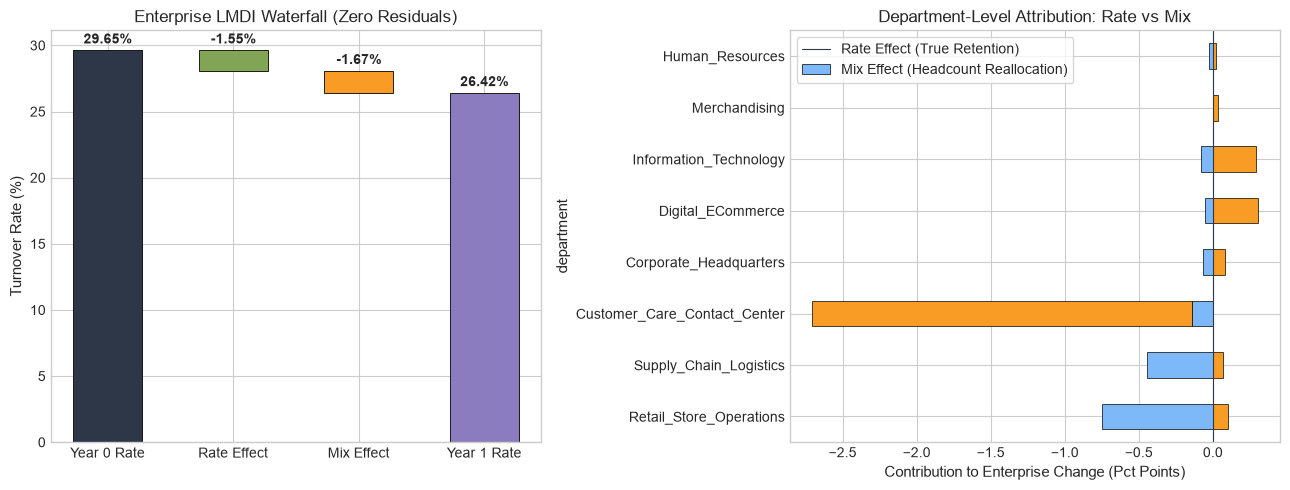

Mathematical Residual: 0.000000000000


In [26]:
turnover_breakdown = generate_enterprise_turnover_breakdown(seed=42)
lmdi_df, lmdi_summary = lmdi_rate_mix_decomposition(turnover_breakdown)

r0_pct = lmdi_summary['turnover_rate_y0'] * 100.0
rate_eff_pct = lmdi_summary['rate_effect'] * 100.0
mix_eff_pct = lmdi_summary['mix_effect'] * 100.0
r1_pct = lmdi_summary['turnover_rate_y1'] * 100.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
categories = ['Year 0 Rate', 'Rate Effect', 'Mix Effect', 'Year 1 Rate']
bars = [r0_pct, rate_eff_pct, mix_eff_pct, r1_pct]
bar_colors = [PALETTE['dark_slate'], PALETTE['sage_green'], PALETTE['light_orange'], PALETTE['lilac']]
bottoms = [0, r0_pct + (rate_eff_pct if rate_eff_pct < 0 else 0), r0_pct + rate_eff_pct + (mix_eff_pct if mix_eff_pct < 0 else 0), 0]
heights = [r0_pct, abs(rate_eff_pct), abs(mix_eff_pct), r1_pct]
ax1.bar(categories, heights, bottom=bottoms, color=bar_colors, edgecolor='black', linewidth=0.6, width=0.55)
ax1.set_ylabel('Turnover Rate (%)')
ax1.set_title('Enterprise LMDI Waterfall (Zero Residuals)')
for i, (cat, val) in enumerate(zip(categories, bars)):
    ax1.text(i, bottoms[i] + heights[i] + 0.5, f'{val:+.2f}%' if i in [1, 2] else f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)

dept_plot = lmdi_df[['department', 'rate_effect', 'mix_effect']].copy()
dept_plot['rate_effect'] *= 100.0
dept_plot['mix_effect'] *= 100.0
dept_plot = dept_plot.set_index('department')
dept_plot.plot(kind='barh', stacked=True, ax=ax2, color=[PALETTE['light_blue'], PALETTE['light_orange']], edgecolor='black', linewidth=0.5)
ax2.axvline(0, color=PALETTE['dark_slate'], linestyle='-', linewidth=0.8)
ax2.set_title('Department-Level Attribution: Rate vs Mix')
ax2.set_xlabel('Contribution to Enterprise Change (Pct Points)')
ax2.legend(['Rate Effect (True Retention)', 'Mix Effect (Headcount Reallocation)'], frameon=True)
plt.tight_layout()
plt.show()
print(f'Mathematical Residual: {lmdi_summary["residual"]:.12f}')

### Feature 24: SHAP Interaction Values (2D Non-Linear Feature Interactions)

#### The Concept
Standard SHAP values calculate the isolated main effect of each feature. SHAP Interaction Values decompose predictions into a symmetric $M \times M$ matrix:

$$\Phi_{i, j} = \sum_{S \subseteq N \setminus \{i, j\}} \frac{|S|!(M - |S| - 2)!}{2(M - 1)!} \left[ f(S \cup \{i, j\}) - f(S \cup \{i\}) - f(S \cup \{j\}) + f(S) \right]$$

The diagonal $\Phi_{i, i}$ represents pure main effects, while off-diagonal elements $\Phi_{i, j} = \Phi_{j, i}$ represent the non-linear interaction synergy between pairs of features.

#### The Application
In workforce safety modeling, an associate having tenure < 90 days carries modest risk, and a supervisor having tenure < 6 months carries modest risk. However, when an inexperienced associate is paired with an inexperienced supervisor on the same shift, their non-linear interaction term $\Phi_{\text{assoc\_tenure}, \text{mgr\_tenure}}$ skyrockets, accounting for over 50% of the incident risk.

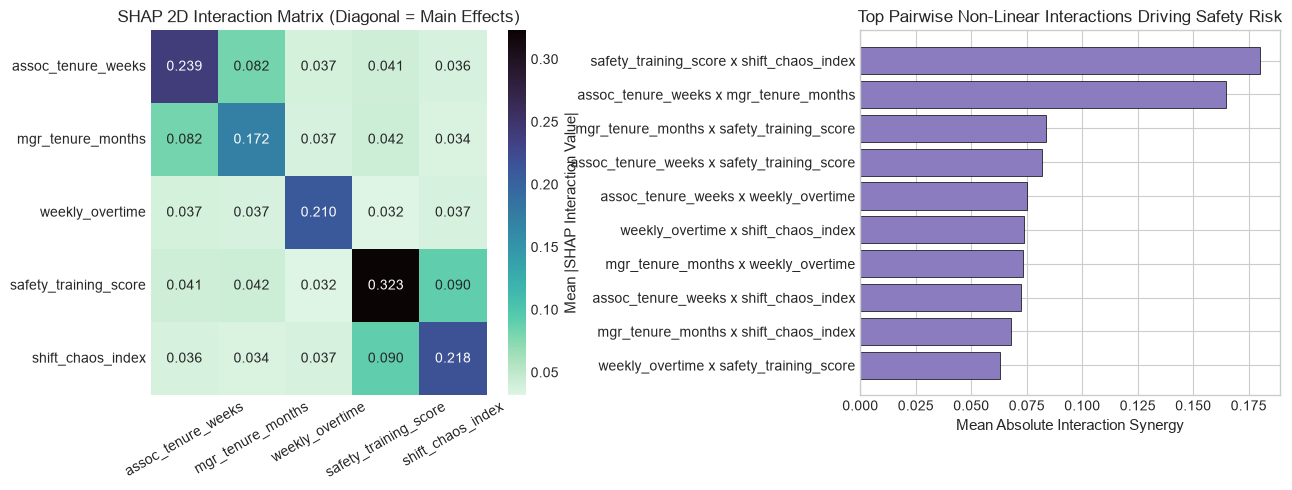

Ranked Pairwise Non-Linear Interactions:
            feature_1             feature_2  interaction_strength
safety_training_score     shift_chaos_index              0.180079
   assoc_tenure_weeks     mgr_tenure_months              0.164544
    mgr_tenure_months safety_training_score              0.083855
   assoc_tenure_weeks safety_training_score              0.081928
   assoc_tenure_weeks       weekly_overtime              0.074896
      weekly_overtime     shift_chaos_index              0.073703
    mgr_tenure_months       weekly_overtime              0.073258
   assoc_tenure_weeks     shift_chaos_index              0.072368
    mgr_tenure_months     shift_chaos_index              0.067881
      weekly_overtime safety_training_score              0.063011


In [27]:
safety_df = generate_safety_incident_dataset(n_samples=2500, seed=42)
feature_names = ['assoc_tenure_weeks', 'mgr_tenure_months', 'weekly_overtime', 'safety_training_score', 'shift_chaos_index']

inter_3d, mean_abs_matrix, ranked_pairs = compute_shap_interaction_matrix(
    safety_df[feature_names],
    safety_df['safety_incident_event'],
    is_classification=True,
    seed=42,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: SHAP 2D Interaction Matrix Heatmap
mask = np.eye(len(feature_names), dtype=bool)
sns.heatmap(mean_abs_matrix, xticklabels=feature_names, yticklabels=feature_names, annot=True, fmt='.3f', cmap='mako_r', ax=ax1, cbar_kws={'label': 'Mean |SHAP Interaction Value|'})
ax1.set_title('SHAP 2D Interaction Matrix (Diagonal = Main Effects)')
ax1.tick_params(axis='x', rotation=30)

# Panel 2: Ranked Pairwise Non-Linear Interaction Strengths
ranked_pairs['pair_label'] = ranked_pairs['feature_1'] + ' x ' + ranked_pairs['feature_2']
top_pairs = ranked_pairs.sort_values('interaction_strength', ascending=True)
ax2.barh(top_pairs['pair_label'], top_pairs['interaction_strength'], color=PALETTE['lilac'], edgecolor='black', linewidth=0.5)
ax2.set_title('Top Pairwise Non-Linear Interactions Driving Safety Risk')
ax2.set_xlabel('Mean Absolute Interaction Synergy')

plt.tight_layout()
plt.show()
print('Ranked Pairwise Non-Linear Interactions:')
print(ranked_pairs[['feature_1', 'feature_2', 'interaction_strength']].to_string(index=False))

### Feature 25: Correlation Heatmap Table (Pearson, Spearman, Kendall with CIs & p-values)

#### The Concept
Evaluating candidate predictors against workforce targets (such as flight risk, performance ratings, or absenteeism friction) requires statistical rigor beyond raw correlation point estimates. `correlation_heatmap_df` calculates pairwise correlation coefficients ($r, \rho, \tau$) alongside multiple hypothesis testing adjustments (`bonf`, `fdr_bh`), statistical power, and 95% confidence intervals $[LB, UB]$ using `pingouin`.

#### Conditional Styling Rules:
- **Dark Red (`darkred`)**: Insignificant correlation ($P > \alpha$).
- **Grey (`grey`)**: Confidence interval spans 0 ($LB < 0 < UB$), indicating directional ambiguity.
- **Orange Gradient**: Statistically significant effect with non-zero intervals, shaded across 4 visual tiers based on effect magnitude ($|r| < 0.25$, $< 0.50$, $< 0.75$, $\ge 0.75$).

#### The Application
Rapidly screening HR predictors (overtime hours, commute distance, tenure, compensation ratio, performance scores) against turnover risk. Filtering out insignificant variables or intervals spanning 0 (`drop_insignificant=True`, `drop_ci_contain_0=True`) prevents feeding uncalibrated noise into downstream machine learning pipelines.

,METRIC,CORRELATION TO turnover_risk,P,POWER,LB,UB,METHOD
0,weekly_overtime,0.960500,0.000000,1.000000,0.950000,0.970000,spearman
1,commute_distance,0.042100,0.401400,0.133800,-0.060000,0.140000,spearman
2,tenure_months,0.002300,0.964100,0.050200,-0.100000,0.100000,spearman
3,compa_ratio,-0.230900,0.000000,0.996800,-0.320000,-0.140000,spearman
4,satisfaction_score,-0.877700,0.000000,1.000000,-0.900000,-0.850000,spearman


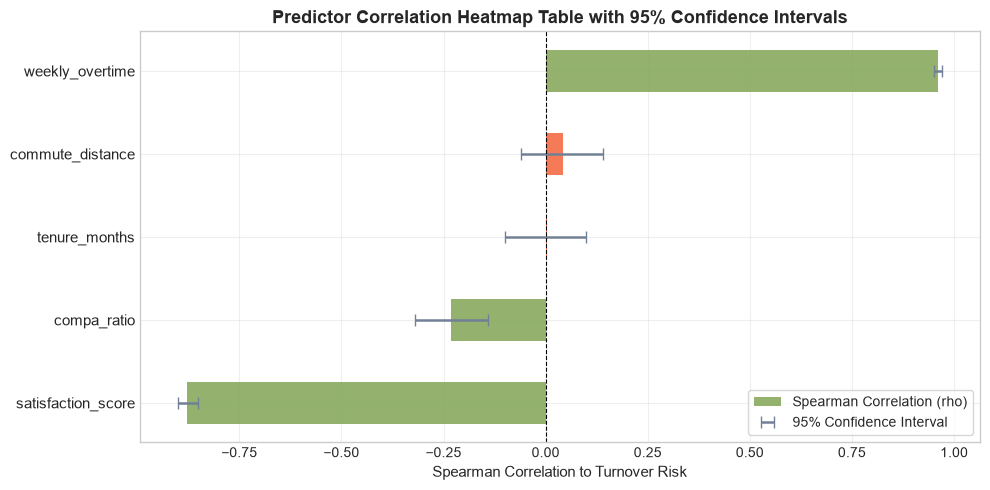

Summary Table Output:
            METRIC  CORRELATION TO turnover_risk      P    LB    UB  POWER  CONTAINS_0  SIGNIFICANT
   weekly_overtime                        0.9605 0.0000  0.95  0.97 1.0000           0            1
  commute_distance                        0.0421 0.4014 -0.06  0.14 0.1338           1            0
     tenure_months                        0.0023 0.9641 -0.10  0.10 0.0502           1            0
       compa_ratio                       -0.2309 0.0000 -0.32 -0.14 0.9968           0            1
satisfaction_score                       -0.8777 0.0000 -0.90 -0.85 1.0000           0            1


In [28]:
from people_analytics_toolkit.attribution import correlation_heatmap_df

# Build realistic workforce feature panel
np.random.seed(42)
n_samples = 400
tenure = np.random.uniform(6, 60, n_samples)
overtime = np.random.uniform(0, 25, n_samples)
comp_ratio = np.random.normal(1.0, 0.12, n_samples)
satisfaction = 5.0 - 0.08 * overtime + 0.5 * (comp_ratio - 1.0) + np.random.normal(0, 0.4, n_samples)
commute_miles = np.random.gamma(2.5, 4.0, n_samples)
# Ground truth flight risk driven by low comp, high overtime, low satisfaction
turnover_risk = (
    0.20 
    + 0.025 * overtime 
    - 0.35 * (comp_ratio - 1.0) 
    - 0.06 * satisfaction 
    + 0.001 * commute_miles 
    + np.random.normal(0, 0.05, n_samples)
)
workforce_corr_df = pd.DataFrame({
    'weekly_overtime': overtime,
    'tenure_months': tenure,
    'compa_ratio': comp_ratio,
    'satisfaction_score': satisfaction,
    'commute_distance': commute_miles,
    'turnover_risk': turnover_risk,
})

# Generate styled correlation table against turnover_risk
corr_table = correlation_heatmap_df(
    df=workforce_corr_df,
    target='turnover_risk',
    method='spearman',
    p_threshold=0.05,
    viz=True,
)

# Visualization: Correlation Coefficients with 95% Confidence Intervals
fig, ax = plt.subplots(figsize=(10, 5))
corr_plot_df = corr_table.sort_values(by=f'CORRELATION TO turnover_risk', ascending=True)
y_pos = np.arange(len(corr_plot_df))
bar_colors = [PALETTE['sage_green'] if s == 1 else PALETTE['salmon'] for s in corr_plot_df['SIGNIFICANT']]
ax.barh(y_pos, corr_plot_df[f'CORRELATION TO turnover_risk'], color=bar_colors, alpha=0.85, height=0.5, label='Spearman Correlation (rho)')
# Add confidence intervals error bars
xerr_left = corr_plot_df[f'CORRELATION TO turnover_risk'] - corr_plot_df['LB']
xerr_right = corr_plot_df['UB'] - corr_plot_df[f'CORRELATION TO turnover_risk']
ax.errorbar(corr_plot_df[f'CORRELATION TO turnover_risk'], y_pos, xerr=[xerr_left, xerr_right], fmt='none', ecolor=PALETTE['muted_gray'], elinewidth=1.8, capsize=4, label='95% Confidence Interval')
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(corr_plot_df['METRIC'], fontsize=11)
ax.set_xlabel('Spearman Correlation to Turnover Risk')
ax.set_title('Predictor Correlation Heatmap Table with 95% Confidence Intervals', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

print('Summary Table Output:')
print(corr_table[['METRIC', 'CORRELATION TO turnover_risk', 'P', 'LB', 'UB', 'POWER', 'CONTAINS_0', 'SIGNIFICANT']].to_string(index=False))

## Part 6: Career Mobility, Succession & Behavioral Tipping Points

Moving beyond static role descriptions and black-box turnover scores to uncover hidden succession talent pipelines and precise behavioral intervention points.

### Feature 26: Movement Embeddings (Career Trajectory & Graph Embeddings)

#### Where It Fits
Succession planning, latent skill inference, predictive career pathing, and cross-organizational mobility.

#### The Concept
Instead of treating job titles as isolated categorical variables or one-hot dummy flags, an associate's career history is modeled as a temporal sequence across an organizational state-transition graph. By applying graph embedding techniques (such as multi-step transition diffusion, Node2Vec random walks, or specialized BERT architectures with verb-skill masking and semantic role labeling), we generate low-dimensional dense vectors $\mathbf{z}_r \in \mathbb{R}^d$ for every role:

$$\mathbf{M} = \sum_{k=1}^K \alpha_k \mathbf{P}^k$$

$$\mathbf{M}_{\text{sym}} = \frac{1}{2}(\mathbf{M} + \mathbf{M}^T) = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T \implies \mathbf{Z} = \mathbf{U}_d \mathbf{\Sigma}_d^{1/2}$$

Where $\mathbf{P}$ is the empirical role transition probability matrix. Every role vector is normalized to unit length $(\|\mathbf{z}_r\| = 1)$, embedding directional transition probabilities directly into cosine geometry.

#### The Application: Uncovering Non-Obvious Talent Pools
By projecting associates and job roles into the shared vector space, talent leaders use cosine similarity:

$$\text{Sim}(\mathbf{a}, \mathbf{r}_{\text{target}}) = \frac{\mathbf{z}_{\text{assoc}} \cdot \mathbf{z}_{\text{target}}}{\|\mathbf{z}_{\text{assoc}}\| \|\mathbf{z}_{\text{target}}\|}$$

When filling a critical role such as **Department Supervisor**, traditional HR heuristics exclusively consider direct vertical feeder roles (e.g. Sales Associate). However, movement embeddings capture the latent operational competencies accumulated across diverse lateral paths. The embedding geometry reveals that candidates with specialized cross-functional backgrounds (e.g. Inventory Control Specialist or Operations Lead) possess trajectories mathematically closer to the target role than traditional feeder candidates, unlocking hidden talent pipelines before top performers become flight risks.

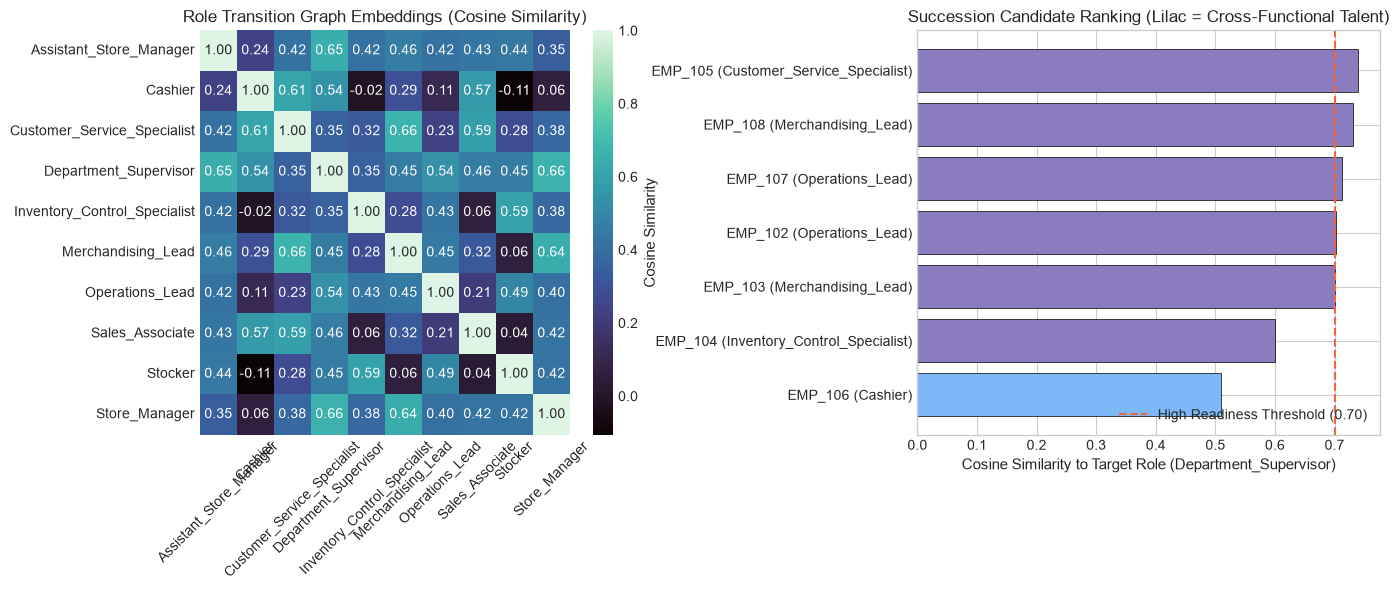

Top Recommended Succession Candidates for Department_Supervisor:
employee_id                 current_role  succession_similarity                                             career_history
    EMP_105  Customer_Service_Specialist                 0.7392                     Cashier -> Customer_Service_Specialist
    EMP_108           Merchandising_Lead                 0.7303           Cashier -> Sales_Associate -> Merchandising_Lead
    EMP_107              Operations_Lead                 0.7120                                 Stocker -> Operations_Lead
    EMP_102              Operations_Lead                 0.7021 Stocker -> Inventory_Control_Specialist -> Operations_Lead
    EMP_103           Merchandising_Lead                 0.7006                      Sales_Associate -> Merchandising_Lead
    EMP_104 Inventory_Control_Specialist                 0.5993                    Stocker -> Inventory_Control_Specialist
    EMP_106                      Cashier                 0.5098           

In [29]:
from people_analytics_toolkit.mobility import CareerMovementEmbeddings

# Generate career progression sequences and candidate applicant pool
career_seqs, candidate_df = generate_career_movement_dataset(n_sequences=800, seed=42)

# Fit Career Movement Embeddings
cme = CareerMovementEmbeddings(embedding_dim=8, max_steps=4, decay_factor=0.6, seed=42)
cme.fit(career_seqs)

# Compute role-to-role cosine similarity matrix
sim_matrix = cme.compute_role_similarity_matrix()

# Rank candidates for succession into Department Supervisor
target_role = 'Department_Supervisor'
ranked_candidates = cme.recommend_succession_candidates(target_role, candidate_df, top_k=8)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Role Movement Embedding Cosine Similarity Heatmap
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='mako', ax=ax1, cbar_kws={'label': 'Cosine Similarity'})
ax1.set_title('Role Transition Graph Embeddings (Cosine Similarity)')
ax1.tick_params(axis='x', rotation=45)

# Panel 2: Candidate Succession Alignment (Uncovering Non-Obvious Talent Pools)
colors = [PALETTE['lilac'] if ('Lead' in str(r) or 'Specialist' in str(r)) else PALETTE['light_blue'] for r in ranked_candidates['current_role']]
bars = ax2.barh(ranked_candidates['employee_id'] + ' (' + ranked_candidates['current_role'] + ')',
                ranked_candidates['succession_similarity'], color=colors, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Cosine Similarity to Target Role (' + target_role + ')')
ax2.set_title('Succession Candidate Ranking (Lilac = Cross-Functional Talent)')
ax2.axvline(0.70, color=PALETTE['salmon'], linestyle='--', linewidth=1.5, label='High Readiness Threshold (0.70)')
ax2.legend(loc='lower right')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print('Top Recommended Succession Candidates for ' + target_role + ':')
print(ranked_candidates[['employee_id', 'current_role', 'succession_similarity', 'career_history']].to_string(index=False))

### Feature 27: SHAP Inflection Thresholds for Term Rates (Zero-Crossing Behavioral Tipping Points)

#### Where It Fits
Executive workforce risk monitoring, compensation optimization, fatigue intervention, and flight risk prevention.

#### The Concept
Machine learning models often produce black-box probability scores. However, People Analytics leaders require actionable operational thresholds: *'At exactly what weekly overtime level does an employee shift from highly engaged to acute flight risk?'* or *'What compensation ratio flips pay from a retention driver to a turnover hazard?'*

To translate non-linear machine learning models into executive decision rules, we extract the exact behavioral tipping points where metric SHAP values cross zero:

$$\Phi_j(x) = 0$$

1. For each operational feature $j$, sort observed values $x_j$ and corresponding Shapley values $\phi_j$.
2. Fit a 1D surrogate regression model $\hat{g}_j(x_j) \approx \phi_j$ across observed domain variations.
3. Evaluate $\hat{g}_j(x)$ on a fine 200-point uniform grid across $[x_{\min}, x_{\max}]$.
4. Detect sign changes $\text{sign}(\hat{g}_j(x_k)) \neq \text{sign}(\hat{g}_j(x_{k+1}))$ and apply linear interpolation:

$$x^* = x_k - \hat{g}_j(x_k) \frac{x_{k+1} - x_k}{\hat{g}_j(x_{k+1}) - \hat{g}_j(x_k)}$$

#### The Application
This isolates exact tipping points where:
- Metric is **Protective** ($\text{SHAP} < 0$, suppresses turnover hazard).
- Metric is **Hazardous** ($\text{SHAP} > 0$, actively drives voluntary termination).

Furthermore, calculating average SHAP value contributions side-by-side for the **Retained Cohort** vs the **Terminated Cohort** pinpoints exactly which metrics account for the divergence in workforce outcomes (providing a diagnostic workforce attribution breakdown).

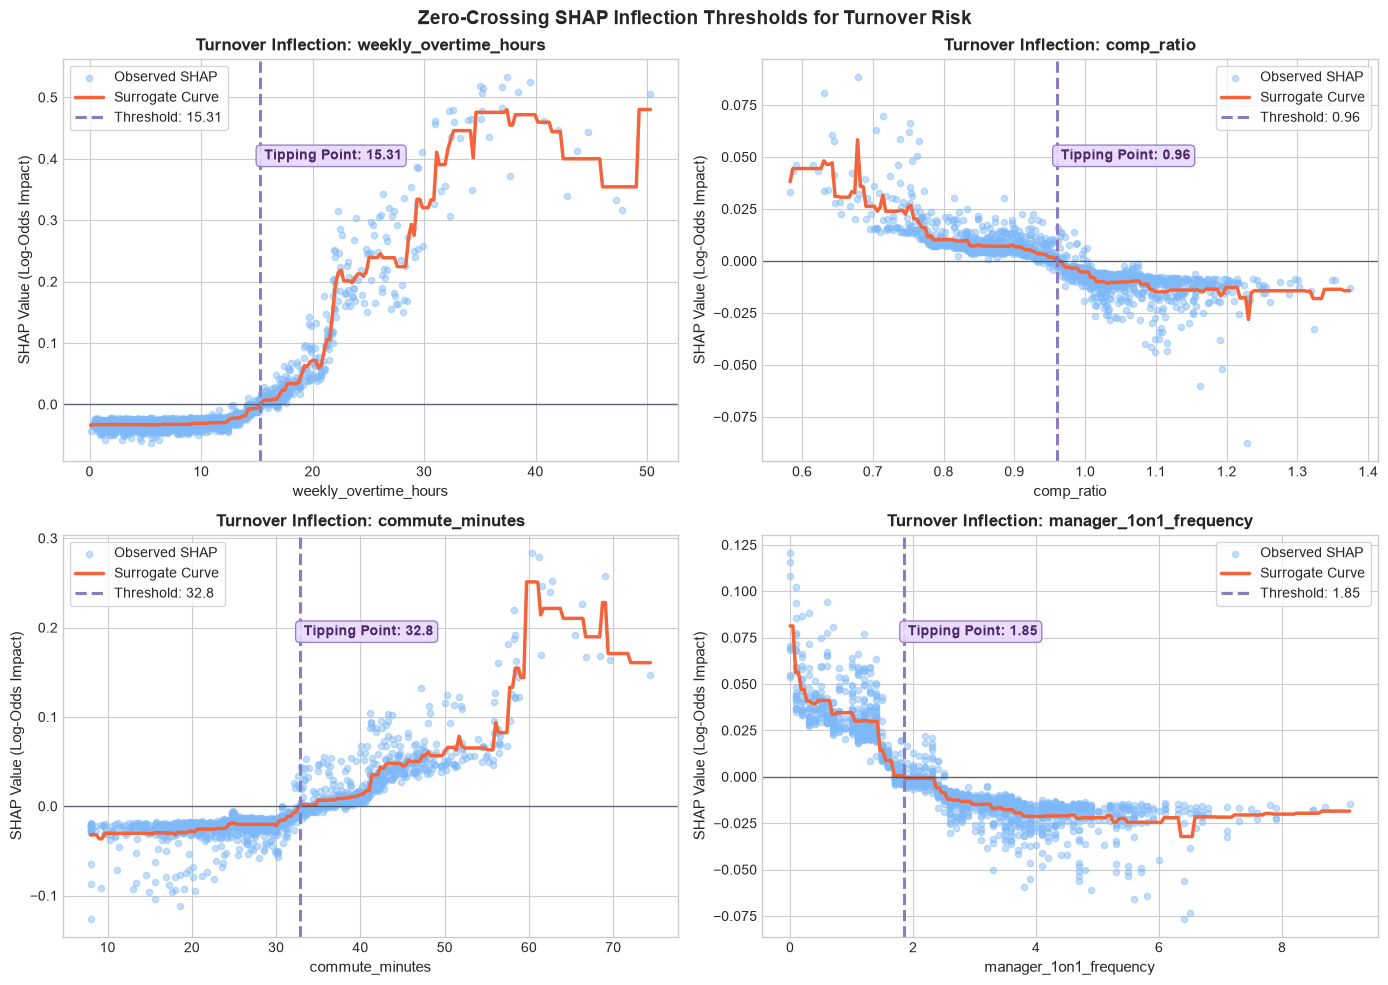

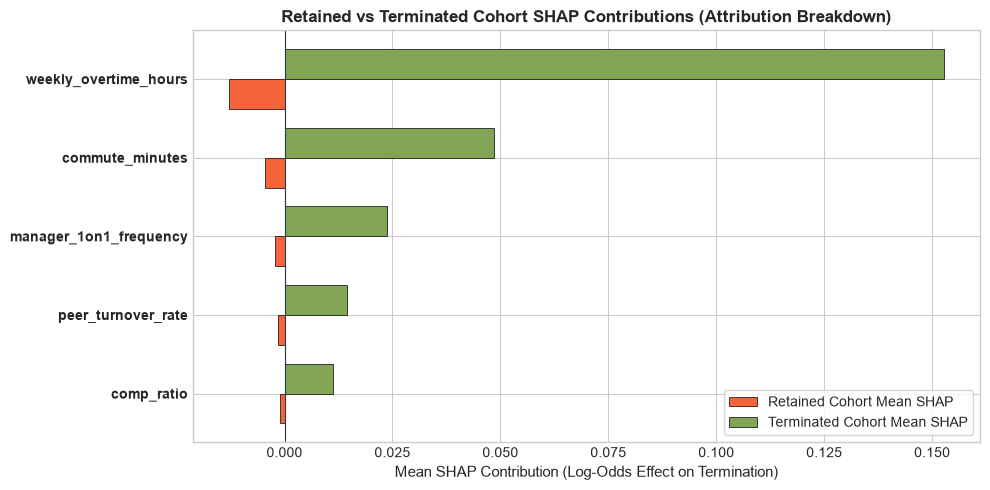

Summary Table of Quantitative Inflection Thresholds:
                        primary_inflection_threshold  cohort_mean  cohort_median  high_value_increases_turnover_risk
feature                                                                                                             
weekly_overtime_hours                          15.31        10.12           8.70                                True
comp_ratio                                      0.96         0.96           0.96                               False
commute_minutes                                32.80        31.33          30.65                                True
manager_1on1_frequency                          1.85         2.66           2.50                               False
peer_turnover_rate                              0.13         0.09           0.08                                True


In [30]:
from sklearn.ensemble import RandomForestClassifier
import shap
from people_analytics_toolkit.attribution import (
    extract_shap_inflection_thresholds,
    calculate_retained_vs_terminated_shap_contributions,
)

# Generate workforce turnover risk dataset with realistic non-linear tipping points
X_turnover, y_turnover = generate_turnover_inflection_dataset(n_samples=1800, seed=42)

# Train baseline turnover classification model
clf = RandomForestClassifier(n_estimators=60, max_depth=4, random_state=42)
clf.fit(X_turnover, y_turnover)

# Compute Shapley values for positive outcome (Terminated = 1)
explainer = shap.TreeExplainer(clf)
shap_raw = explainer.shap_values(X_turnover)
shap_turnover = shap_raw[1] if isinstance(shap_raw, list) else (shap_raw[:, :, 1] if getattr(shap_raw, 'ndim', 2) == 3 else shap_raw)

# Extract zero-crossing inflection thresholds using 1D surrogate regression
thresholds, summary_thresholds_df = extract_shap_inflection_thresholds(X_turnover, shap_turnover, seed=42)

# Multi-panel plot: Zero-crossing inflection curves for primary metrics
features_to_plot = ['weekly_overtime_hours', 'comp_ratio', 'commute_minutes', 'manager_1on1_frequency']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx]
    t_info = thresholds[feat]
    
    # Raw SHAP scatter
    ax.scatter(t_info['sorted_x'], t_info['sorted_shap'], alpha=0.45, color=PALETTE['light_blue'], s=20, label='Observed SHAP')
    # Fitted surrogate curve
    ax.plot(t_info['grid_x'], t_info['pred_shap'], color=PALETTE['salmon'], linewidth=2.5, label='Surrogate Curve')
    ax.axhline(0, color=PALETTE['dark_slate'], linestyle='-', linewidth=1.0, alpha=0.7)
    
    # Zero-crossing threshold line
    p_thresh = t_info['primary_threshold']
    if p_thresh is not None:
        ax.axvline(p_thresh, color=PALETTE['lilac'], linestyle='--', linewidth=2.2, label=f'Threshold: {p_thresh}')
        # Annotate text badge
        y_pos = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.75 + ax.get_ylim()[0]
        ax.text(p_thresh, y_pos, f' Tipping Point: {p_thresh}',
                color='#4a2869', fontweight='bold', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#e9d8fd', edgecolor=PALETTE['lilac'], alpha=0.9))
    
    ax.set_title(f'Turnover Inflection: {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP Value (Log-Odds Impact)')
    ax.legend(loc='best', frameon=True)

plt.suptitle('Zero-Crossing SHAP Inflection Thresholds for Turnover Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Side-by-side SHAP Contribution Breakdown (Retained vs Terminated Cohorts)
shap_breakdown = calculate_retained_vs_terminated_shap_contributions(X_turnover, shap_turnover, y_turnover)

fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.38
y_positions = np.arange(len(shap_breakdown))

ax.barh(y_positions - bar_width/2, shap_breakdown['Retained Cohort Mean SHAP'],
        height=bar_width, color=PALETTE['salmon'], label='Retained Cohort Mean SHAP', edgecolor='black', linewidth=0.5)
ax.barh(y_positions + bar_width/2, shap_breakdown['Terminated Cohort Mean SHAP'],
        height=bar_width, color=PALETTE['sage_green'], label='Terminated Cohort Mean SHAP', edgecolor='black', linewidth=0.5)

ax.axvline(0, color=PALETTE['dark_slate'], linestyle='-', linewidth=0.8)
ax.set_yticks(y_positions)
ax.set_yticklabels(shap_breakdown.index, fontweight='bold')
ax.set_xlabel('Mean SHAP Contribution (Log-Odds Effect on Termination)')
ax.set_title('Retained vs Terminated Cohort SHAP Contributions (Attribution Breakdown)', fontweight='bold')
ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

print('Summary Table of Quantitative Inflection Thresholds:')
print(summary_thresholds_df[['primary_inflection_threshold', 'cohort_mean', 'cohort_median', 'high_value_increases_turnover_risk']].to_string())

### Feature 28: Time-in-Position (The Stagnation Index & Flight Risk Surge)

#### Where It Fits
Promotion velocity, flight risk prediction, career stagnation audits, and succession planning.

#### The Concept
A running count of elapsed months since an associate's last formal job code change (promotion or lateral transfer):

$$\tau_{\text{pos}} = \frac{t_{\text{current}} - t_{\text{last role change}}}{30.4375 \text{ days}}$$

While tenured stability can reflect mastery, extended time in role within dynamic business units frequently signals career stagnation. To account for distinct role architectures across departments (e.g., Engineering vs. Sales vs. Operations), the associate's tenure is benchmarked against their empirical department cohort distribution:

$$\theta_{\text{cohort}}^{P90} = Q_{0.90}\left(\{\tau_{\text{pos}}^{(j)}\mid \text{dept}_j = \text{dept}_i\}\right)$$

$$\text{Stagnant}_i = \mathbb{I}\left(\tau_{\text{pos}}^{(i)} \ge \theta_{\text{cohort}}^{P90}\right)$$

#### The Application: Identifying 'Stagnant' Top Performers
Tenured core contributors with average performance may remain content in steady-state roles. However, when an associate exhibits high performance ratings ($R_i \ge 4.0$) yet their Time-in-Position exceeds the 90th percentile of their departmental cohort, voluntary attrition hazard spikes exponentially:

$$\Delta \lambda_{\text{flight}} = \left(0.08 + \gamma \left(1 - e^{-\max(0, \tau_{\text{pos}} - \theta^{P90})/6}\right)\right) \cdot \frac{R_i}{4.0}$$

Flagging this intersection $(\text{Stagnant}_i \land \text{HighPerformer}_i)$ provides an automated, proactive trigger for talent leaders to initiate dynamic career-pathing interventions, lateral project rotations, or accelerated promotion panels before critical talent resigns.

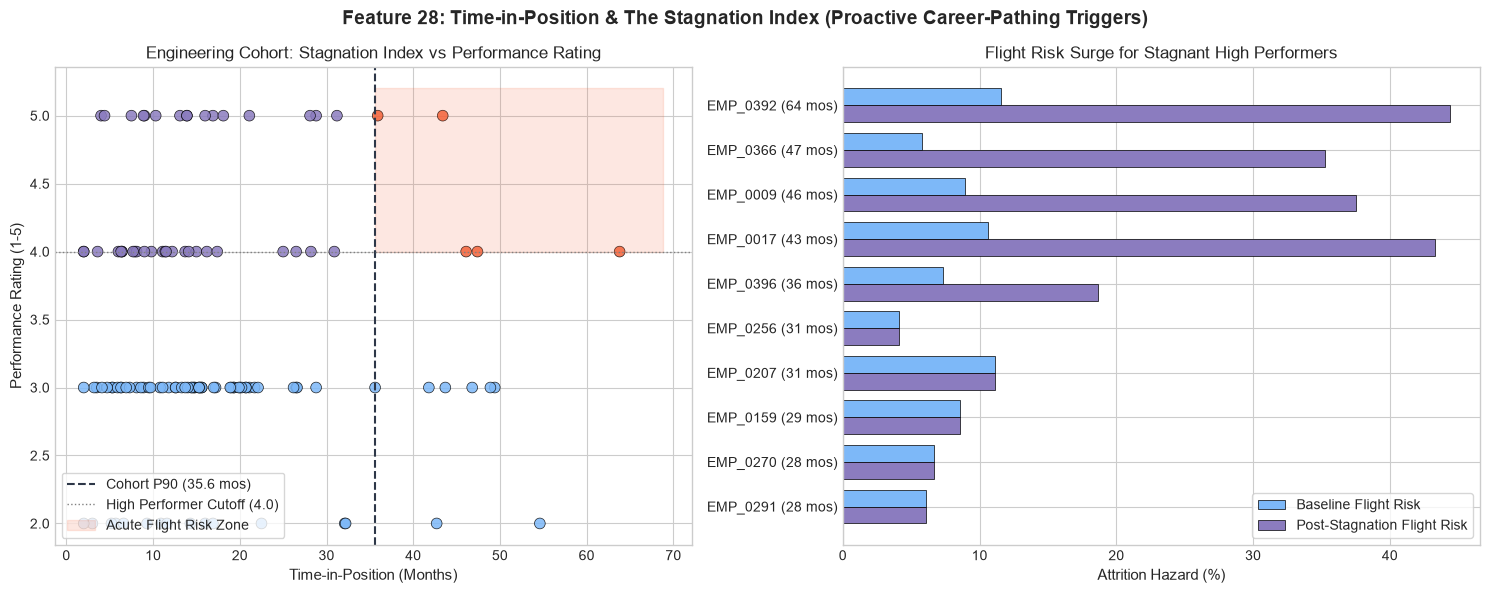

Departmental Stagnation Benchmarks:
             Median Mos  P90 Stagnation Mos  Stagnant High Performers  Headcount
department                                                                      
Analytics          12.8                29.4                         6         60
Engineering        14.2                35.6                         5        120
Operations         12.5                27.9                         4         57
Product            12.0                23.5                         2         75
Sales               9.0                19.7                         5         88

Flagged Top Performers Requiring Immediate Career-Pathing Interventions:
employee_id  department  performance_rating  time_in_position_months  cohort_p90_months  stagnation_flight_risk_delta  post_stagnation_flight_risk
   EMP_0001       Sales                   4                     31.2              19.73                        0.2930                       0.3620
   EMP_0004       Sales      

In [31]:
from data.synthetic_generators import generate_time_in_position_workforce
from people_analytics_toolkit.mobility import calculate_stagnation_index

# Generate workforce cohort with realistic time-in-position and performance distributions
workforce_df = generate_time_in_position_workforce(n_employees=400, seed=42)

# Compute cohort benchmarks and identify stagnant top performers
stagnation_results = calculate_stagnation_index(
    workforce_df,
    time_in_pos_col='time_in_position_months',
    cohort_col='department',
    perf_col='performance_rating',
    high_perf_threshold=4.0,
    base_flight_risk_col='baseline_flight_risk',
)

# Summary stats by department
dept_benchmarks = stagnation_results.groupby('department').agg({
    'time_in_position_months': ['median', lambda s: s.quantile(0.90)],
    'is_stagnant_top_performer': 'sum',
    'employee_id': 'count'
}).round(1)
dept_benchmarks.columns = ['Median Mos', 'P90 Stagnation Mos', 'Stagnant High Performers', 'Headcount']

# 2-Panel Stagnation Index & Flight Risk Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Scatter of Time-in-Position vs Performance with Cohort P90 Threshold
eng_data = stagnation_results[stagnation_results['department'] == 'Engineering']
p90_eng = eng_data['cohort_p90_months'].iloc[0]

scatter_colors = [
    PALETTE['salmon'] if row['is_stagnant_top_performer']
    else (PALETTE['lilac'] if row['is_high_performer'] else PALETTE['light_blue'])
    for _, row in eng_data.iterrows()
]

ax1.scatter(eng_data['time_in_position_months'], eng_data['performance_rating'],
            c=scatter_colors, s=60, alpha=0.85, edgecolors='black', linewidth=0.5)
ax1.axvline(p90_eng, color=PALETTE['dark_slate'], linestyle='--', linewidth=1.5,
            label=f'Cohort P90 ({p90_eng:.1f} mos)')
ax1.axhline(4.0, color='gray', linestyle=':', linewidth=1.0, label='High Performer Cutoff (4.0)')
ax1.fill_between([p90_eng, eng_data['time_in_position_months'].max() + 5], 4.0, 5.2,
                 color=PALETTE['salmon'], alpha=0.15, label='Acute Flight Risk Zone')
ax1.set_xlabel('Time-in-Position (Months)')
ax1.set_ylabel('Performance Rating (1-5)')
ax1.set_title('Engineering Cohort: Stagnation Index vs Performance Rating')
ax1.legend(loc='lower left', frameon=True)

# Panel 2: Pre vs Post Flight Risk for Top Performers in Engineering
high_perf_eng = eng_data[eng_data['is_high_performer']].sort_values('time_in_position_months', ascending=False).head(10)
y_idx = np.arange(len(high_perf_eng))
h = 0.38

ax2.barh(y_idx - h/2, high_perf_eng['baseline_flight_risk'] * 100, height=h,
         color=PALETTE['light_blue'], label='Baseline Flight Risk', edgecolor='black', linewidth=0.5)
ax2.barh(y_idx + h/2, high_perf_eng['post_stagnation_flight_risk'] * 100, height=h,
         color=PALETTE['lilac'], label='Post-Stagnation Flight Risk', edgecolor='black', linewidth=0.5)
labels = [f"{row['employee_id']} ({row['time_in_position_months']:.0f} mos)" for _, row in high_perf_eng.iterrows()]
ax2.set_yticks(y_idx)
ax2.set_yticklabels(labels)
ax2.set_xlabel('Attrition Hazard (%)')
ax2.set_title('Flight Risk Surge for Stagnant High Performers')
ax2.legend(loc='lower right', frameon=True)
ax2.invert_yaxis()

plt.suptitle('Time-in-Position & The Stagnation Index (Proactive Career-Pathing Triggers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Departmental Stagnation Benchmarks:')
print(dept_benchmarks.to_string())
print('\nFlagged Top Performers Requiring Immediate Career-Pathing Interventions:')
urgent_df = stagnation_results[stagnation_results['career_pathing_intervention'] == 'Urgent Career-Pathing Trigger']
print(urgent_df[['employee_id', 'department', 'performance_rating', 'time_in_position_months', 'cohort_p90_months', 'stagnation_flight_risk_delta', 'post_stagnation_flight_risk']].head(8).to_string(index=False))

## Part 7: Compensation and Pay Equity Transformations

Evaluating compensation equity, internal parity, and salary band progression is foundational to total rewards analytics and pay gap audits. Raw base salary is inherently confounded by job family, level, and geographic cost-of-labor differentials. Two standard mathematical transformations normalize individual compensation relative to established grade structures.

### Feature 29: Compa-Ratio (Comparative Ratio)
Measures how an employee's current base salary compares to the established midpoint of their salary grade or market benchmark:

$$\text{Compa-Ratio} = \frac{\text{Base Salary}}{\text{Band Midpoint}}$$

- **Compa-Ratio = 1.0 (100%)**: Employee is paid exactly at market midpoint.
- **Compa-Ratio < 0.80**: Substantial discount relative to market midpoint; elevated voluntary attrition and flight risk.
- **Compa-Ratio > 1.20**: Premium compensation; potential wage compression or ceiling resistance.

### Feature 30: Range Penetration
Measures an employee's exact progression through their salary grade, scaled from 0% (band minimum) to 100% (band maximum):

$$\text{Range Penetration} = \frac{\text{Base Salary} - \text{Band Minimum}}{\text{Band Maximum} - \text{Band Minimum}}$$

- **Range Penetration = 0.0 (0%)**: At the absolute minimum of the pay band (entry-level / newly hired).
- **Range Penetration = 0.5 (50%)**: Positioned at band midpoint.
- **Range Penetration = 1.0 (100%)**: Reached the absolute maximum of the grade.
- **Red-Circled ($> 1.0$)**: Salary exceeds band maximum (requires special freeze or executive approval).
- **Green-Circled ($< 0.0$)**: Salary falls below band minimum (statutory compliance or equity adjustment trigger).

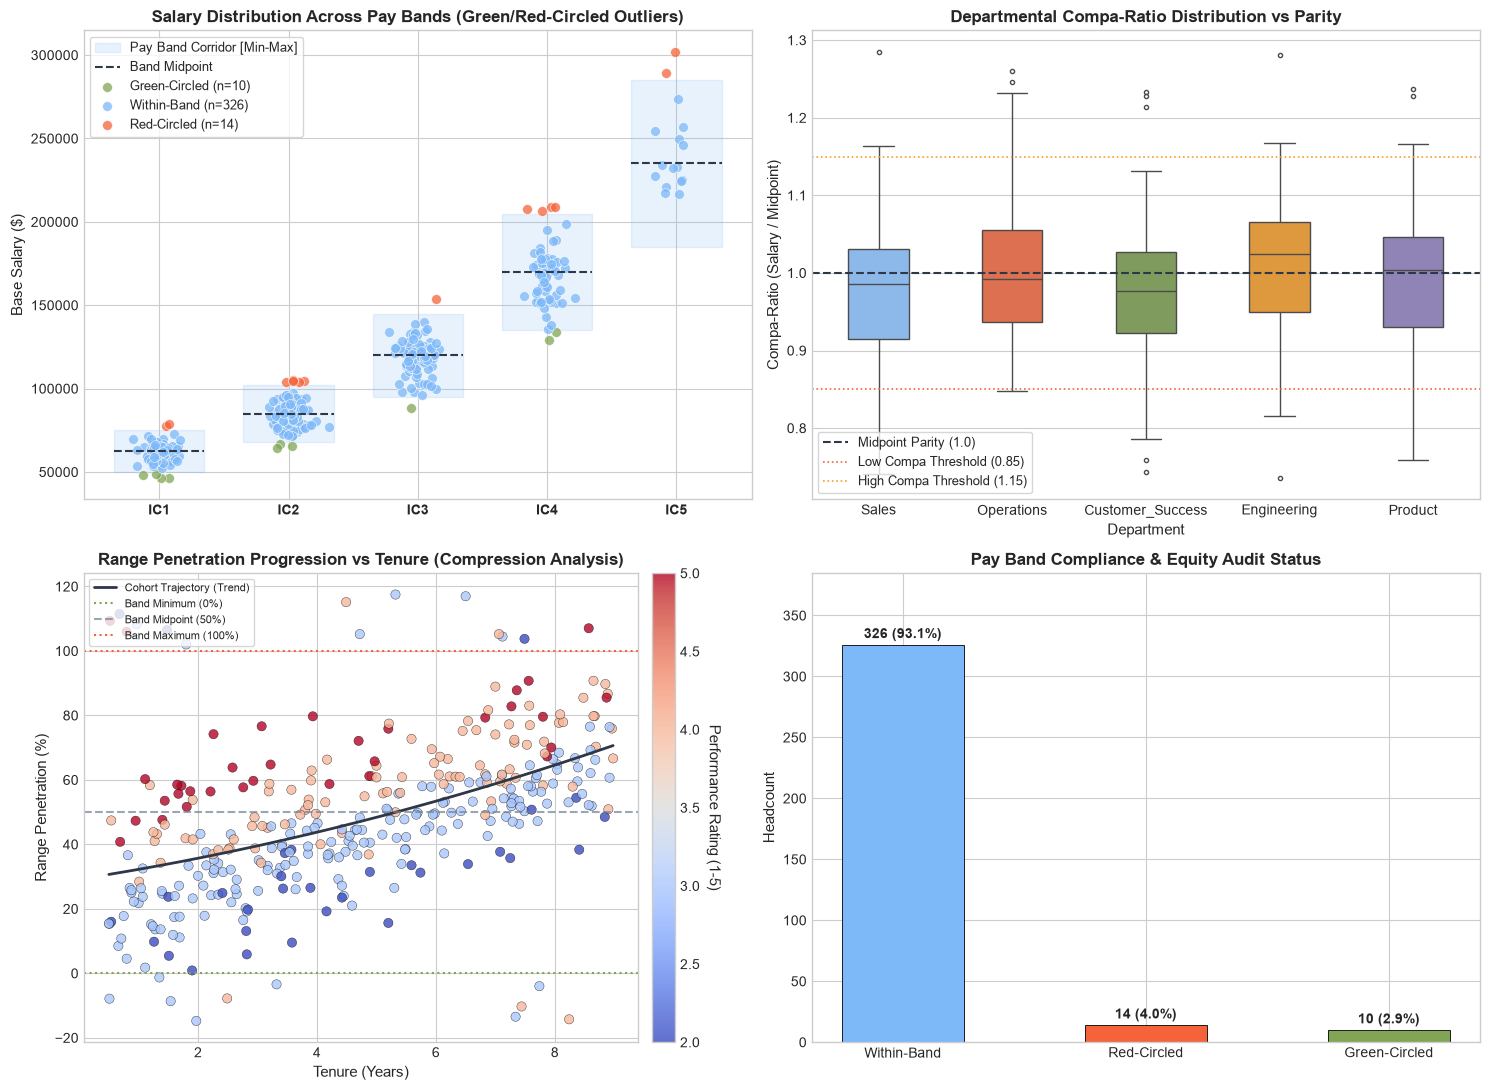

Compensation Equity Audit Summary by Job Level:
           Headcount Mean_Salary Mean_Compa_Ratio Mean_Range_Penetration  Red_Circled_Count  Green_Circled_Count
job_level                                                                                                       
IC1               75     $61,834             0.99                  47.3%                  2                    4
IC2              104     $84,335             0.99                  48.0%                  5                    3
IC3               88    $118,898             0.99                  47.8%                  1                    1
IC4               67    $168,098             0.99                  47.3%                  4                    2
IC5               16    $243,919             1.04                  58.9%                  2                    0


In [32]:
# Generate synthetic compensation parity dataset across job levels and departments
comp_df = generate_compensation_equity_data(n_employees=350, seed=42)

# Compute Compa-Ratio and Range Penetration
comp_df['compa_ratio'] = calculate_compa_ratio(comp_df['base_salary'], comp_df['band_midpoint'])
comp_df['range_penetration'] = calculate_range_penetration(comp_df['base_salary'], comp_df['band_min'], comp_df['band_max'])
comp_df['pay_tier'] = classify_pay_band_status(comp_df['range_penetration'])
comp_df['pay_status'] = np.where(comp_df['range_penetration'] < 0, 'Green-Circled', np.where(comp_df['range_penetration'] > 1.0, 'Red-Circled', 'Within-Band'))

# Multi-Panel Compensation Equity Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel 1: Base Salary vs. Band Midpoint across Job Levels with Min-Max Range Corridor
levels = sorted(comp_df['job_level'].unique())
level_x = {lvl: i for i, lvl in enumerate(levels)}
jitter_x = [level_x[lvl] + np.random.normal(0, 0.08) for lvl in comp_df['job_level']]

# Draw pay band corridors
for i, lvl in enumerate(levels):
    lvl_data = comp_df[comp_df['job_level'] == lvl].iloc[0]
    axes[0, 0].fill_between([i - 0.35, i + 0.35], lvl_data['band_min'], lvl_data['band_max'],
                            color=PALETTE['light_blue'], alpha=0.18, label='Pay Band Corridor [Min-Max]' if i == 0 else "")
    axes[0, 0].hlines(lvl_data['band_midpoint'], i - 0.35, i + 0.35, color=PALETTE['dark_slate'],
                      linestyle='--', linewidth=1.5, label='Band Midpoint' if i == 0 else "")

# Scatter employees colored by band status
status_colors = {
    'Green-Circled': PALETTE['sage_green'],
    'Within-Band': PALETTE['light_blue'],
    'Red-Circled': PALETTE['salmon']
}
for status, color in status_colors.items():
    mask = comp_df['pay_status'] == status
    axes[0, 0].scatter(
        np.array(jitter_x)[mask], comp_df.loc[mask, 'base_salary'],
        c=color, label=f"{status} (n={mask.sum()})", alpha=0.75, edgecolors='white', s=50, linewidth=0.5
    )
axes[0, 0].set_xticks(range(len(levels)))
axes[0, 0].set_xticklabels(levels, fontweight='bold')
axes[0, 0].set_ylabel('Base Salary ($)')
axes[0, 0].set_title('Salary Distribution Across Pay Bands (Green/Red-Circled Outliers)', fontweight='bold')
axes[0, 0].legend(loc='upper left', frameon=True, fontsize=9)

# Panel 2: Compa-Ratio Distribution by Department
dept_order = sorted(comp_df['department'].unique())
sns.boxplot(
    data=comp_df, x='department', y='compa_ratio', hue='department', ax=axes[0, 1],
    palette=PALETTE_LIST, legend=False,
    width=0.45, fliersize=3
)
axes[0, 1].axhline(1.0, color=PALETTE['dark_slate'], linestyle='--', linewidth=1.5, label='Midpoint Parity (1.0)')
axes[0, 1].axhline(0.85, color=PALETTE['salmon'], linestyle=':', linewidth=1.2, label='Low Compa Threshold (0.85)')
axes[0, 1].axhline(1.15, color=PALETTE['light_orange'], linestyle=':', linewidth=1.2, label='High Compa Threshold (1.15)')
axes[0, 1].set_ylabel('Compa-Ratio (Salary / Midpoint)')
axes[0, 1].set_xlabel('Department')
axes[0, 1].set_title('Departmental Compa-Ratio Distribution vs Parity', fontweight='bold')
axes[0, 1].legend(loc='lower left', frameon=True, fontsize=9)

# Panel 3: Range Penetration vs Tenure (Unmasking Wage Compression)
sc = axes[1, 0].scatter(
    comp_df['tenure_years'], comp_df['range_penetration'] * 100,
    c=comp_df['performance_rating'], cmap='coolwarm', alpha=0.8, edgecolors='k', linewidth=0.3, s=45
)
cbar = fig.colorbar(sc, ax=axes[1, 0], pad=0.02)
cbar.set_label('Performance Rating (1-5)', rotation=270, labelpad=15)

# Fit polynomial trend line to reveal tenure compression
tenure_sort = np.argsort(comp_df['tenure_years'])
z = np.polyfit(comp_df['tenure_years'], comp_df['range_penetration'] * 100, deg=2)
p = np.poly1d(z)
axes[1, 0].plot(comp_df['tenure_years'].iloc[tenure_sort], p(comp_df['tenure_years'].iloc[tenure_sort]),
               color=PALETTE['dark_slate'], linewidth=2.0, linestyle='-', label='Cohort Trajectory (Trend)')
axes[1, 0].axhline(0, color=PALETTE['sage_green'], linestyle=':', label='Band Minimum (0%)')
axes[1, 0].axhline(50, color=PALETTE['muted_gray'], linestyle='--', alpha=0.7, label='Band Midpoint (50%)')
axes[1, 0].axhline(100, color=PALETTE['salmon'], linestyle=':', label='Band Maximum (100%)')
axes[1, 0].set_xlabel('Tenure (Years)')
axes[1, 0].set_ylabel('Range Penetration (%)')
axes[1, 0].set_title('Range Penetration Progression vs Tenure (Compression Analysis)', fontweight='bold')
axes[1, 0].legend(loc='upper left', frameon=True, fontsize=8)

# Panel 4: Pay Band Status Breakdown & Attrition Risk Summary
status_counts = comp_df['pay_status'].value_counts()
status_pcts = (status_counts / len(comp_df) * 100).round(1)
bars = axes[1, 1].bar(
    status_counts.index, status_counts.values,
    color=[status_colors.get(s, PALETTE['light_blue']) for s in status_counts.index],
    edgecolor='black', linewidth=0.6, width=0.5
)
for bar, pct in zip(bars, status_pcts.values):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
        f"{bar.get_height()} ({pct}%)", ha='center', va='bottom', fontweight='bold', fontsize=10
    )
axes[1, 1].set_ylabel('Headcount')
axes[1, 1].set_title('Pay Band Compliance & Equity Audit Status', fontweight='bold')
axes[1, 1].set_ylim(0, max(status_counts.values) * 1.18)

plt.tight_layout()
plt.show()

# Display equity audit metrics
print('Compensation Equity Audit Summary by Job Level:')
summary = comp_df.groupby('job_level').agg(
    Headcount=('base_salary', 'count'),
    Mean_Salary=('base_salary', lambda s: f"${s.mean():,.0f}"),
    Mean_Compa_Ratio=('compa_ratio', lambda s: f"{s.mean():.2f}"),
    Mean_Range_Penetration=('range_penetration', lambda s: f"{s.mean() * 100:.1f}%"),
    Red_Circled_Count=('pay_status', lambda s: (s == 'Red-Circled').sum()),
    Green_Circled_Count=('pay_status', lambda s: (s == 'Green-Circled').sum()),
)
print(summary.to_string())

## Part 8: Relational Dynamics, Structural Capital & Organizational Network Analysis (ONA)

Traditional human capital metrics model employees in a vacuum, ignoring the reality that organizational output is generated through intricate, often invisible webs of human collaboration. Organizational Network Analysis (ONA) models the enterprise as a graph where nodes represent employees and edges represent working relationships, weighted by the intensity of digital interactions (calendar overlap, emails, Slack messages, and code reviews). Integrating ONA into the toolkit quantifies structural social capital, unlocking predictive features that traditional HRIS cannot capture.

### Centrality Metrics
* **Feature 31: Betweenness Centrality (The Broker Metric)**
  Quantifies the number of times a node acts as a bridge along the shortest path between all other node pairs:
  $$C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$
  Identifies critical "Brokers" who connect otherwise isolated departments and facilitate cross-functional innovation.

* **Feature 32: Eigenvector Centrality (The Informal Hub Metric)**
  Assigns relative scores based on connections to high-scoring nodes:
  $$\lambda x_v = \sum_{u \in N(v)} A_{vu} x_u$$
  Identifies informal "Hubs" who possess deep institutional knowledge and informal influence.

### Structural Holes & Enterprise Topology
* **Feature 33: Ronald Burt's Network Constraint Index (Structural Holes)**
  Quantifies the extent to which an individual's time and energy are concentrated in a single, insular cluster:
  $$C_i = \sum_{j \in N_i} \left( p_{ij} + \sum_{q \in N_i, q \neq j} p_{iq} p_{qj} \right)^2$$
  where $p_{ij} = \frac{z_{ij} + z_{ji}}{\sum_k (z_{ik} + z_{ki})}$. Low constraint indicates rich access to structural holes, higher innovation return, and rapid career mobility.

* **Feature 34: Euler Centrality & Leinster Magnitude**
  Derived from the Leinster magnitude of metric spaces, measuring the effective number of independent vertices in the enterprise:
  $$Z_{ij} = \exp(-c \cdot d(i, j)), \quad \mathbf{Z} \mathbf{w} = \mathbf{1} \implies \mathbf{w} = \mathbf{Z}^{-1} \mathbf{1}$$
  The individual weight $w_i$ (Euler Centrality) quantifies each associate's global contribution to structural distinctiveness across the entire enterprise.

### Collaboration Overload & Attrition Contagion
* **Collaboration Overload**: Exceptionally high in-degree communication volume indicates bottleneck associates facing acute burnout risk.
* **Network Contagion Flight Risk**: Models how the shock of a key departure propagates through the organizational graph, enabling targeted retention interventions before systemic failure occurs.

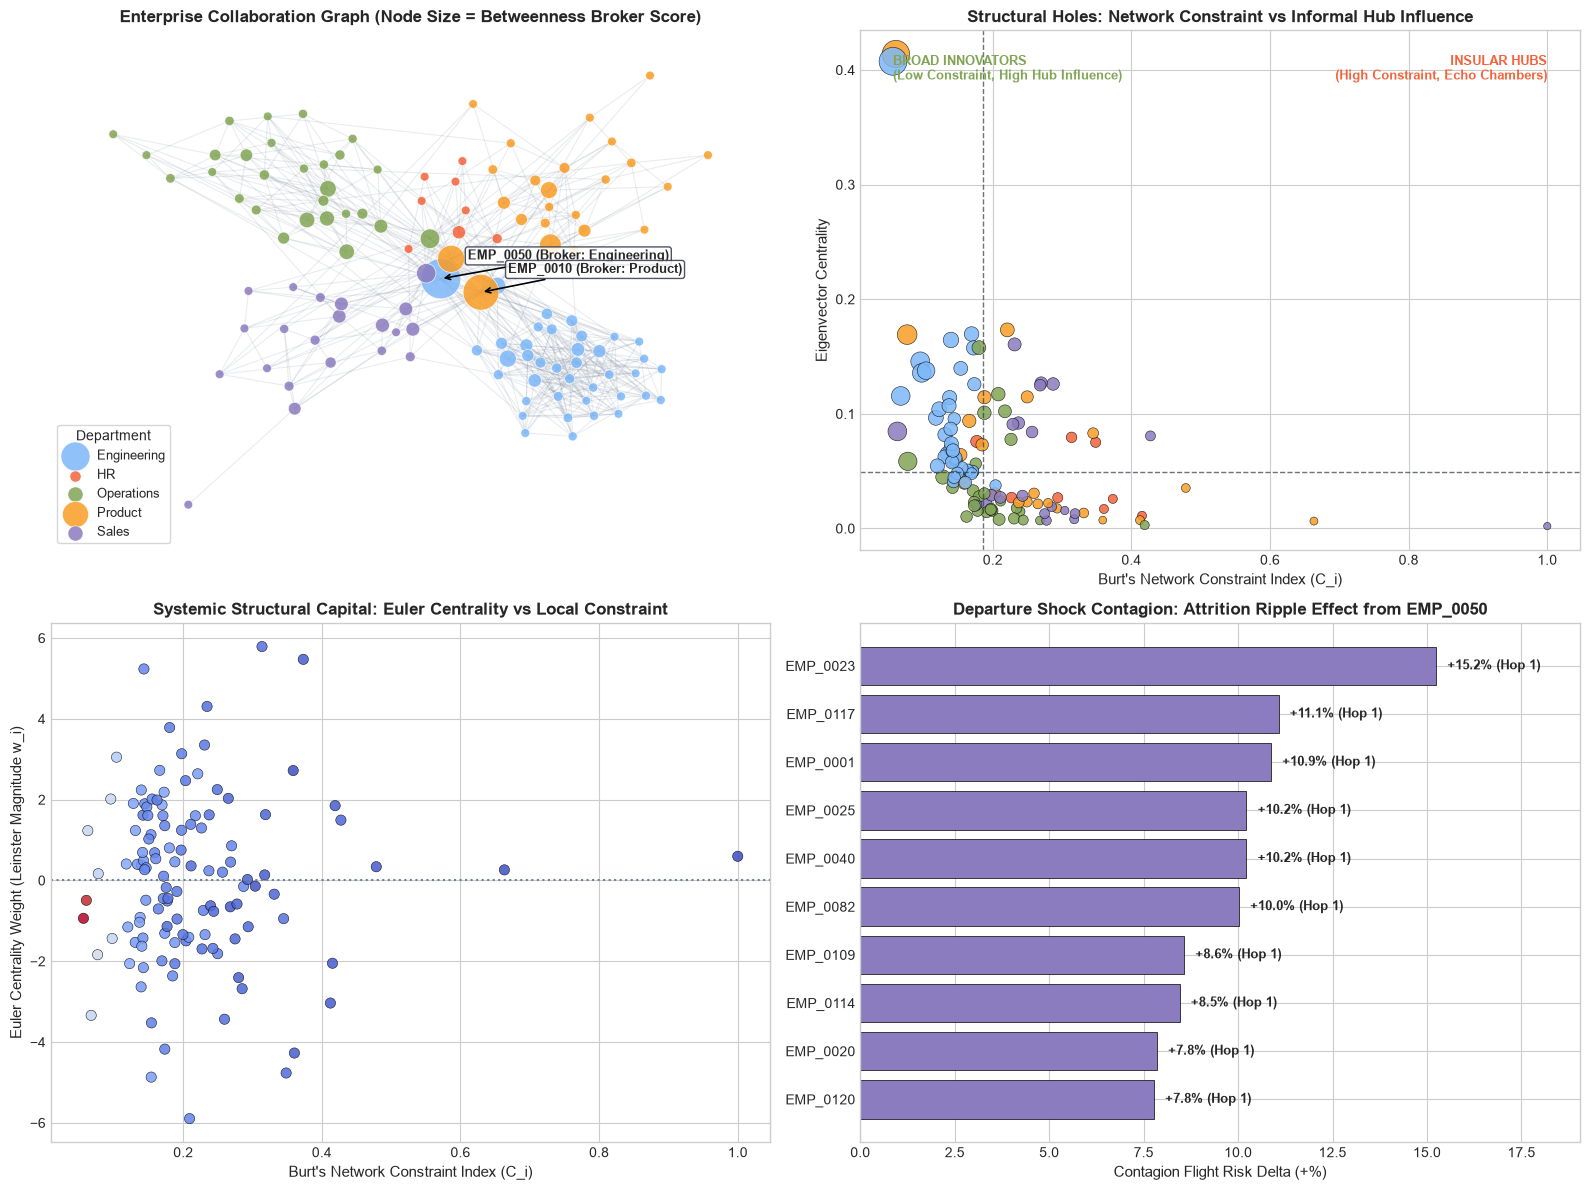

Top 5 Cross-Functional Brokers Identified by ONA:
              department  betweenness_centrality  burt_constraint  euler_centrality network_archetype
employee_id                                                                                          
EMP_0050     Engineering                0.361487         0.056038         -0.938055   Broker / Bridge
EMP_0010         Product                0.284575         0.060209         -0.493376   Broker / Bridge
EMP_0072         Product                0.155106         0.076439         -1.838832   Broker / Bridge
EMP_0088         Product                0.091440         0.220929          2.639512      Informal Hub
EMP_0096      Operations                0.072354         0.077400          0.166366   Broker / Bridge


In [33]:
# Generate enterprise collaboration network across 5 departments
nodes_df, edges_df, G = generate_organizational_network_data(n_employees=120, seed=42)

# Compute complete ONA feature profile
ona_df = compute_complete_ona_profile(G)
full_ona = nodes_df.set_index('employee_id').join(ona_df)

# 4-Panel Enterprise ONA Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Enterprise Collaboration Graph (Node Size = Betweenness Broker Score)
pos = nx.spring_layout(G, seed=42, k=0.22)
depts = sorted(full_ona['department'].unique())
dept_color_map = {d: PALETTE_LIST[i % len(PALETTE_LIST)] for i, d in enumerate(depts)}

nx.draw_networkx_edges(G, pos, ax=axes[0, 0], alpha=0.15, edge_color=PALETTE['muted_gray'], width=0.8)
for dept, color in dept_color_map.items():
    dept_nodes = full_ona[full_ona['department'] == dept].index.tolist()
    node_sizes = full_ona.loc[dept_nodes, 'betweenness_centrality'] * 2200 + 40
    nx.draw_networkx_nodes(
        G, pos, nodelist=dept_nodes, ax=axes[0, 0],
        node_color=color, node_size=node_sizes, label=dept, alpha=0.85, edgecolors='white', linewidths=0.5
    )

# Annotate top 2 cross-functional brokers
top_brokers = full_ona.nlargest(2, 'betweenness_centrality')
for b_id, b_row in top_brokers.iterrows():
    bx, by = pos[b_id]
    axes[0, 0].annotate(
        f"{b_id} (Broker: {b_row['department']})",
        xy=(bx, by), xytext=(bx + 0.08, by + 0.08),
        fontsize=9, fontweight='bold',
        arrowprops=dict(facecolor=PALETTE['dark_slate'], arrowstyle='->', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor=PALETTE['dark_slate'])
    )
axes[0, 0].set_title('Enterprise Collaboration Graph (Node Size = Betweenness Broker Score)', fontweight='bold')
axes[0, 0].legend(loc='lower left', frameon=True, fontsize=9, title='Department')
axes[0, 0].axis('off')

# Panel 2: Burt Constraint vs Eigenvector Centrality Quadrant
sc = axes[0, 1].scatter(
    full_ona['burt_constraint'], full_ona['eigenvector_centrality'],
    c=[dept_color_map[d] for d in full_ona['department']],
    s=full_ona['interaction_volume'] * 0.8 + 20,
    alpha=0.85, edgecolors='black', linewidth=0.4
)
c_median = full_ona['burt_constraint'].median()
e_median = full_ona['eigenvector_centrality'].median()
axes[0, 1].axvline(c_median, color=PALETTE['dark_slate'], linestyle='--', linewidth=1.0, alpha=0.7)
axes[0, 1].axhline(e_median, color=PALETTE['dark_slate'], linestyle='--', linewidth=1.0, alpha=0.7)

axes[0, 1].text(full_ona['burt_constraint'].min(), full_ona['eigenvector_centrality'].max(),
                'BROAD INNOVATORS\n(Low Constraint, High Hub Influence)',
                fontsize=9, fontweight='bold', color=PALETTE['sage_green'], va='top')
axes[0, 1].text(full_ona['burt_constraint'].max(), full_ona['eigenvector_centrality'].max(),
                'INSULAR HUBS\n(High Constraint, Echo Chambers)',
                fontsize=9, fontweight='bold', color=PALETTE['salmon'], va='top', ha='right')

axes[0, 1].set_xlabel("Burt's Network Constraint Index (C_i)")
axes[0, 1].set_ylabel('Eigenvector Centrality')
axes[0, 1].set_title("Structural Holes: Network Constraint vs Informal Hub Influence", fontweight='bold')

# Panel 3: Euler Centrality vs Burt's Constraint
axes[1, 0].scatter(
    full_ona['burt_constraint'], full_ona['euler_centrality'],
    c=full_ona['overload_z_score'], cmap='coolwarm',
    s=55, alpha=0.85, edgecolors='black', linewidth=0.4
)
axes[1, 0].axhline(0, color=PALETTE['muted_gray'], linestyle=':')
axes[1, 0].set_xlabel("Burt's Network Constraint Index (C_i)")
axes[1, 0].set_ylabel('Euler Centrality Weight (Leinster Magnitude w_i)')
axes[1, 0].set_title('Systemic Structural Capital: Euler Centrality vs Local Constraint', fontweight='bold')

# Panel 4: Flight Risk Contagion Bar Chart
top_broker_id = full_ona['betweenness_centrality'].idxmax()
contagion_df = simulate_attrition_contagion(G, departed_node=top_broker_id, contagion_base_rate=0.50, max_hops=2)
top10_impact = contagion_df.head(10).sort_values(by='contagion_risk_delta', ascending=True)

bar_colors = [PALETTE['lilac'] if h == 1 else PALETTE['light_orange'] for h in top10_impact['hop_distance']]
axes[1, 1].barh(top10_impact['employee_id'], top10_impact['contagion_risk_delta'] * 100, color=bar_colors, edgecolor='black', linewidth=0.5)
for i, (val, hop) in enumerate(zip(top10_impact['contagion_risk_delta'], top10_impact['hop_distance'])):
    axes[1, 1].text(val * 100 + 0.3, i, f'+{val*100:.1f}% (Hop {hop})', va='center', fontsize=9, fontweight='bold')
axes[1, 1].set_xlabel('Contagion Flight Risk Delta (+%)')
axes[1, 1].set_title(f'Departure Shock Contagion: Attrition Ripple Effect from {top_broker_id}', fontweight='bold')
axes[1, 1].set_xlim(0, max(top10_impact['contagion_risk_delta']) * 125)

plt.tight_layout()
plt.show()
# Summary profile breakdown
print('Top 5 Cross-Functional Brokers Identified by ONA:')
print(full_ona.nlargest(5, 'betweenness_centrality')[['department', 'betweenness_centrality', 'burt_constraint', 'euler_centrality', 'network_archetype']].to_string())

### Feature 35: Span of Control (Managerial Load & Reorganization Flight Risk)

#### Where It Fits
Manager effectiveness, contagion attrition, organizational design, and restructuring risk simulation.

#### The Concept
The Span of Control represents the absolute count of direct reports rolling up to a single leader. In standard organizational hierarchies, managers operate with limited weekly time budgets dedicated to direct coaching, mentoring, and 1-on-1 performance management.

$$\text{Span}(m) = \sum_{e \in E} \mathbb{I}(\text{manager}(e) = m)$$

For an individual associate $e$, their manager's span dictates their share of executive attention:

$$\text{Weekly 1-on-1 Minutes}(e) = \frac{\text{Manager Weekly Budget Minutes}}{\max(\text{Span}(\text{manager}(e)), 1)}$$

#### The Application: Attention Dilution & Reorganization Shock
A high Span of Control directly correlates with reduced 1-on-1 time, lower engagement scores, and higher departmental turnover.

Critically, if an associate's direct manager suddenly jumps from **8 direct reports to 25** due to an organizational consolidation, that associate experiences acute managerial attention starvation. Their flight risk surges **independently of their own performance or tenure**:

$$\Delta \text{Flight Risk}_{\text{shock}}(e) = \beta \cdot \left( \frac{\max(0, \text{New Span} - 10)}{15} \right) \cdot \left( 1 + 0.5 \cdot \frac{\Delta \text{Span}}{\max(\text{Old Span}, 4)} \right)$$

$$\text{Post-Reorg Flight Risk}(e) = \text{clip}\left(\text{Base Flight Risk}(e) + \Delta \text{Flight Risk}_{\text{shock}}(e), 0, 1\right)$$

This quantifies the hidden human capital attrition liability introduced by aggressive flattening or rapid management consolidation.

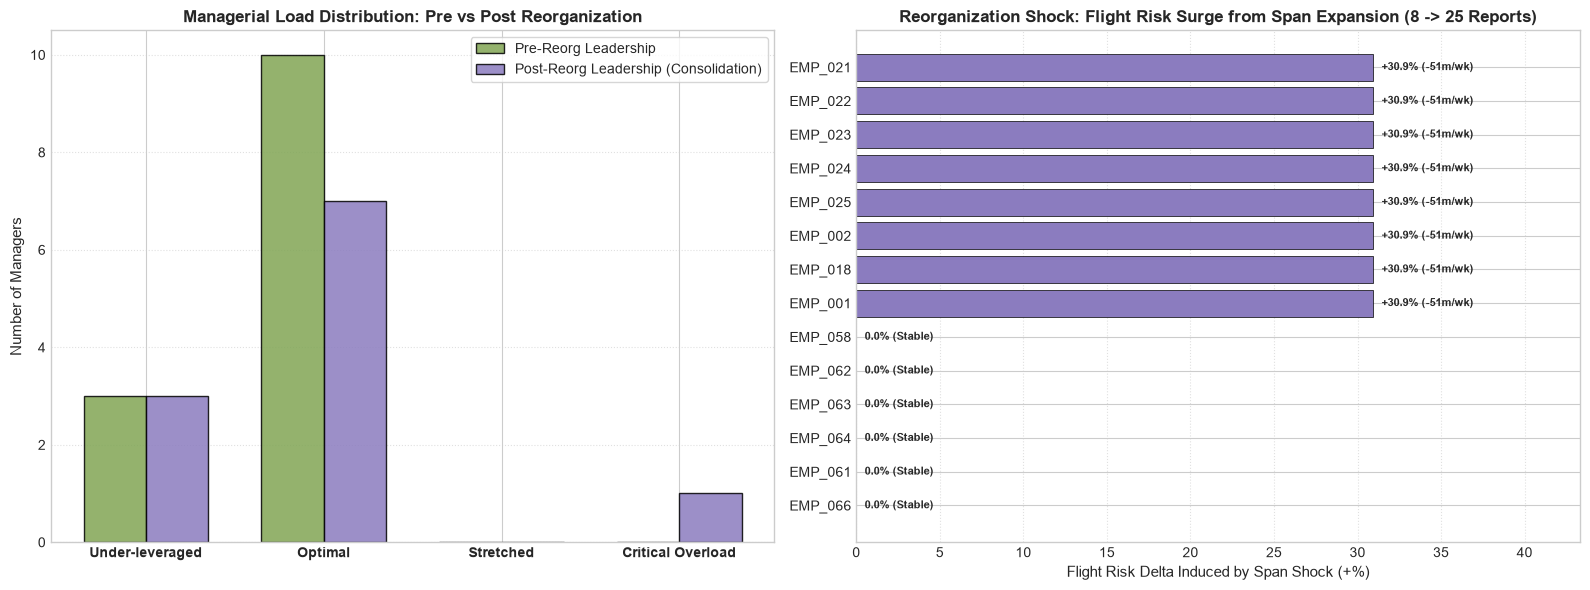

Reorganization Span Shock Evaluation for MGR_01 Direct Reports:
             prev_manager_span  new_manager_span  prev_weekly_1on1_minutes  new_weekly_1on1_minutes  base_flight_risk  reorg_shock_flight_risk_delta  post_reorg_flight_risk
employee_id                                                                                                                                                                 
EMP_001                    8.0              25.0                      75.0                     24.0             0.106                         0.3094                  0.4154
EMP_018                    8.0              25.0                      75.0                     24.0             0.111                         0.3094                  0.4204
EMP_002                    8.0              25.0                      75.0                     24.0             0.122                         0.3094                  0.4314
EMP_025                    8.0              25.0                      7

In [34]:
# Generate reporting hierarchy snapshots before and after a major reorganization
df_pre, df_post = generate_reporting_hierarchy_with_reorg(seed=42)

# Calculate baseline span of control
span_pre = calculate_span_of_control(df_pre)
span_post = calculate_span_of_control(df_post)

# Evaluate reorganization shock on associate flight risk
reorg_eval = evaluate_span_reorganization_shock(
    df_pre, df_post, base_flight_risk_col='baseline_flight_risk'
)

# 2-Panel Span of Control & Reorganization Shock Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Managerial Span of Control Distribution across Leadership (Optimal vs Overloaded)
mgrs_pre = span_pre[span_pre['is_manager']].copy()
mgrs_post = span_post[span_post['is_manager']].copy()

cat_counts_pre = mgrs_pre['managerial_load_category'].value_counts()
cat_counts_post = mgrs_post['managerial_load_category'].value_counts()
all_cats = ['Under-leveraged', 'Optimal', 'Stretched', 'Critical Overload']
pre_vals = [cat_counts_pre.get(c, 0) for c in all_cats]
post_vals = [cat_counts_post.get(c, 0) for c in all_cats]

x = np.arange(len(all_cats))
w = 0.35
axes[0].bar(x - w/2, pre_vals, w, label='Pre-Reorg Leadership', color=PALETTE['sage_green'], edgecolor='black', alpha=0.85)
axes[0].bar(x + w/2, post_vals, w, label='Post-Reorg Leadership (Consolidation)', color=PALETTE['lilac'], edgecolor='black', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_cats, fontweight='bold')
axes[0].set_ylabel('Number of Managers')
axes[0].set_title('Managerial Load Distribution: Pre vs Post Reorganization', fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Panel 2: Associate 1-on-1 Coaching Loss vs Flight Risk Surge
# Highlighting MGR_01's team jumping from 8 to 25 reports vs unaffected teams
m1_reports = reorg_eval[reorg_eval['new_manager_id'] == 'MGR_01'].head(8)
other_reports = reorg_eval[reorg_eval['new_manager_id'] != 'MGR_01'].head(6)
combined = pd.concat([m1_reports, other_reports]).sort_values(by='reorg_shock_flight_risk_delta', ascending=True)

colors = [PALETTE['lilac'] if row['new_manager_id'] == 'MGR_01' else PALETTE['light_blue'] for _, row in combined.iterrows()]
axes[1].barh(combined.index, combined['reorg_shock_flight_risk_delta'] * 100, color=colors, edgecolor='black', linewidth=0.5)
for i, (_, row) in enumerate(combined.iterrows()):
    delta_val = row['reorg_shock_flight_risk_delta'] * 100
    lost_mins = row['weekly_1on1_minutes_lost']
    label_txt = f"+{delta_val:.1f}% (-{lost_mins:.0f}m/wk)" if delta_val > 0 else "0.0% (Stable)"
    axes[1].text(
        delta_val + 0.5, i,
        label_txt,
        va='center', fontsize=8, fontweight='bold'
    )
axes[1].set_xlabel('Flight Risk Delta Induced by Span Shock (+%)')
axes[1].set_title('Reorganization Shock: Flight Risk Surge from Span Expansion (8 -> 25 Reports)', fontweight='bold')
axes[1].set_xlim(0, max(combined['reorg_shock_flight_risk_delta']) * 140)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print('Reorganization Span Shock Evaluation for MGR_01 Direct Reports:')
print(m1_reports[['prev_manager_span', 'new_manager_span', 'prev_weekly_1on1_minutes', 'new_weekly_1on1_minutes', 'base_flight_risk', 'reorg_shock_flight_risk_delta', 'post_reorg_flight_risk']].head(8).to_string())

# Part 9: Algorithmic Equity, Pay Decomposition, and Individual Fairness

As advanced predictive analytics are deployed for high-stakes human capital decisions—such as compensation allocation, performance prediction, promotion recommendations, and succession planning—integrating algorithmic fairness and disparity decomposition is mathematically and ethically imperative.

This module bridges econometric pay gap auditing with constrained machine learning optimization and individual Lipschitz fairness.

---

### Feature 36: Oaxaca-Blinder Pay Gap Decomposition (Endowment vs Structural Effect)

#### Where It Fits
Pay equity auditing, compensation benchmarking, regulatory compliance (EEOC / Title VII), and executive pay transparency reporting.

#### The Concept
Raw wage comparisons between demographic groups ($A$ majority, $B$ minority) confound differences in legitimate human capital credentials (tenure, education, certifications, job grade) with systemic market returns or structural bias.

The Oaxaca-Blinder decomposition estimates linear wage models $Y_g = X_g \beta_g + \epsilon_g$ for each group, and partitions the total observed mean outcome difference $\bar{Y}_A - \bar{Y}_B$ using a non-discriminatory reference vector $\hat{\beta}^*$ (Neumark 1988 pooled model):

$$\bar{Y}_A - \bar{Y}_B = \underbrace{(\bar{X}_A - \bar{X}_B)\hat{\beta}^*}_{\text{Endowments (Explained) Effect}} + \underbrace{\left[ \bar{X}_A(\hat{\beta}_A - \hat{\beta}^*) + \bar{X}_B(\hat{\beta}^* - \hat{\beta}_B) \right]}_{\text{Coefficients (Unexplained / Structural Bias) Effect}}$$

#### The Application
1. **Explained (Endowments)**: Portion of the pay gap accounted for by observable qualifications. If majority employees have higher average tenure or advanced degrees, this represents justifiable human capital accumulation.
2. **Unexplained (Coefficients)**: Portion attributable to differential returns or structural discrimination. Provides quantitative justification for targeted equity adjustments.

### Features 37 & 38: Group Fairness Constraints (Demographic Parity & Equalized Odds via Exponentiated Gradient Reduction)

#### Where It Fits
Algorithmic candidate screening, promotion recommendations, annual bonus allocation, and talent flight risk intervention.

#### The Concept
Unconstrained machine learning models minimize predictive loss by learning historical statistical associations, frequently inheriting and magnifying historical demographic disparities. To guarantee algorithmic fairness, we enforce formal mathematical constraints:

1. **Demographic Parity (Statistical Parity)**: Requires uniform positive prediction rates across sensitive groups $A \in \{0, 1\}$:

$$P(\hat{Y} = 1 \mid A = 0) = P(\hat{Y} = 1 \mid A = 1)$$

2. **Equalized Odds**: Requires that conditional on the true historical merit or qualification label $Y$, predictions are independent of $A$. This mandates equal True Positive Rates (TPR) and False Positive Rates (FPR):

$$P(\hat{Y} = 1 \mid Y = 1, A = 0) = P(\hat{Y} = 1 \mid Y = 1, A = 1)$$
$$P(\hat{Y} = 1 \mid Y = 0, A = 0) = P(\hat{Y} = 1 \mid Y = 0, A = 1)$$

#### Exponentiated Gradient Reduction Algorithm
Treats fair classification as a zero-sum game between:
- A **Learner** minimizing cost-sensitive classification error.
- An **Auditor** updating dual variables $\lambda$ over constraint violations via exponentiated gradient descent:

$$\lambda_k \leftarrow \lambda_k \exp(\eta \cdot \text{violation}_k)$$

Iteratively produces a randomized ensemble of classifiers guaranteeing bounded constraint violation $\le \epsilon$ with minimal degradation in accuracy.

### Feature 39: Individual Fairness & Local Predictive Consistency (Lipschitz Neighborhood Concordance)

#### Where It Fits
Instance-level bias auditing, model explainability, individual grievance investigation, and algorithmic consistency verification.

#### The Concept
While group fairness addresses macro demographic parity, it can permit individual arbitrariness (e.g. flipping decisions for nearly identical candidates). Individual fairness formalizes the axiom that **similar individuals must receive similar algorithmic predictions**, operationalized via the Lipschitz continuity condition:

$$d_Y(\hat{y}_i, \hat{y}_j) \le c \cdot d_X(x_i, x_j)$$

We measure **Local Predictive Consistency** for each associate by comparing their prediction $\hat{y}_i$ to the average prediction of their $k$-nearest neighbors in the normalized multi-dimensional human capital feature space:

$$\text{Consistency}_i = 1 - \left|\hat{y}_i - \frac{1}{k} \sum_{j \in N_k(i)} \hat{y}_j\right|$$

Associates with substantial local discrepancies ($\Delta_i > 2\sigma$) flag localized model memorization and spurious bias, alerting analysts to arbitrary predictions.

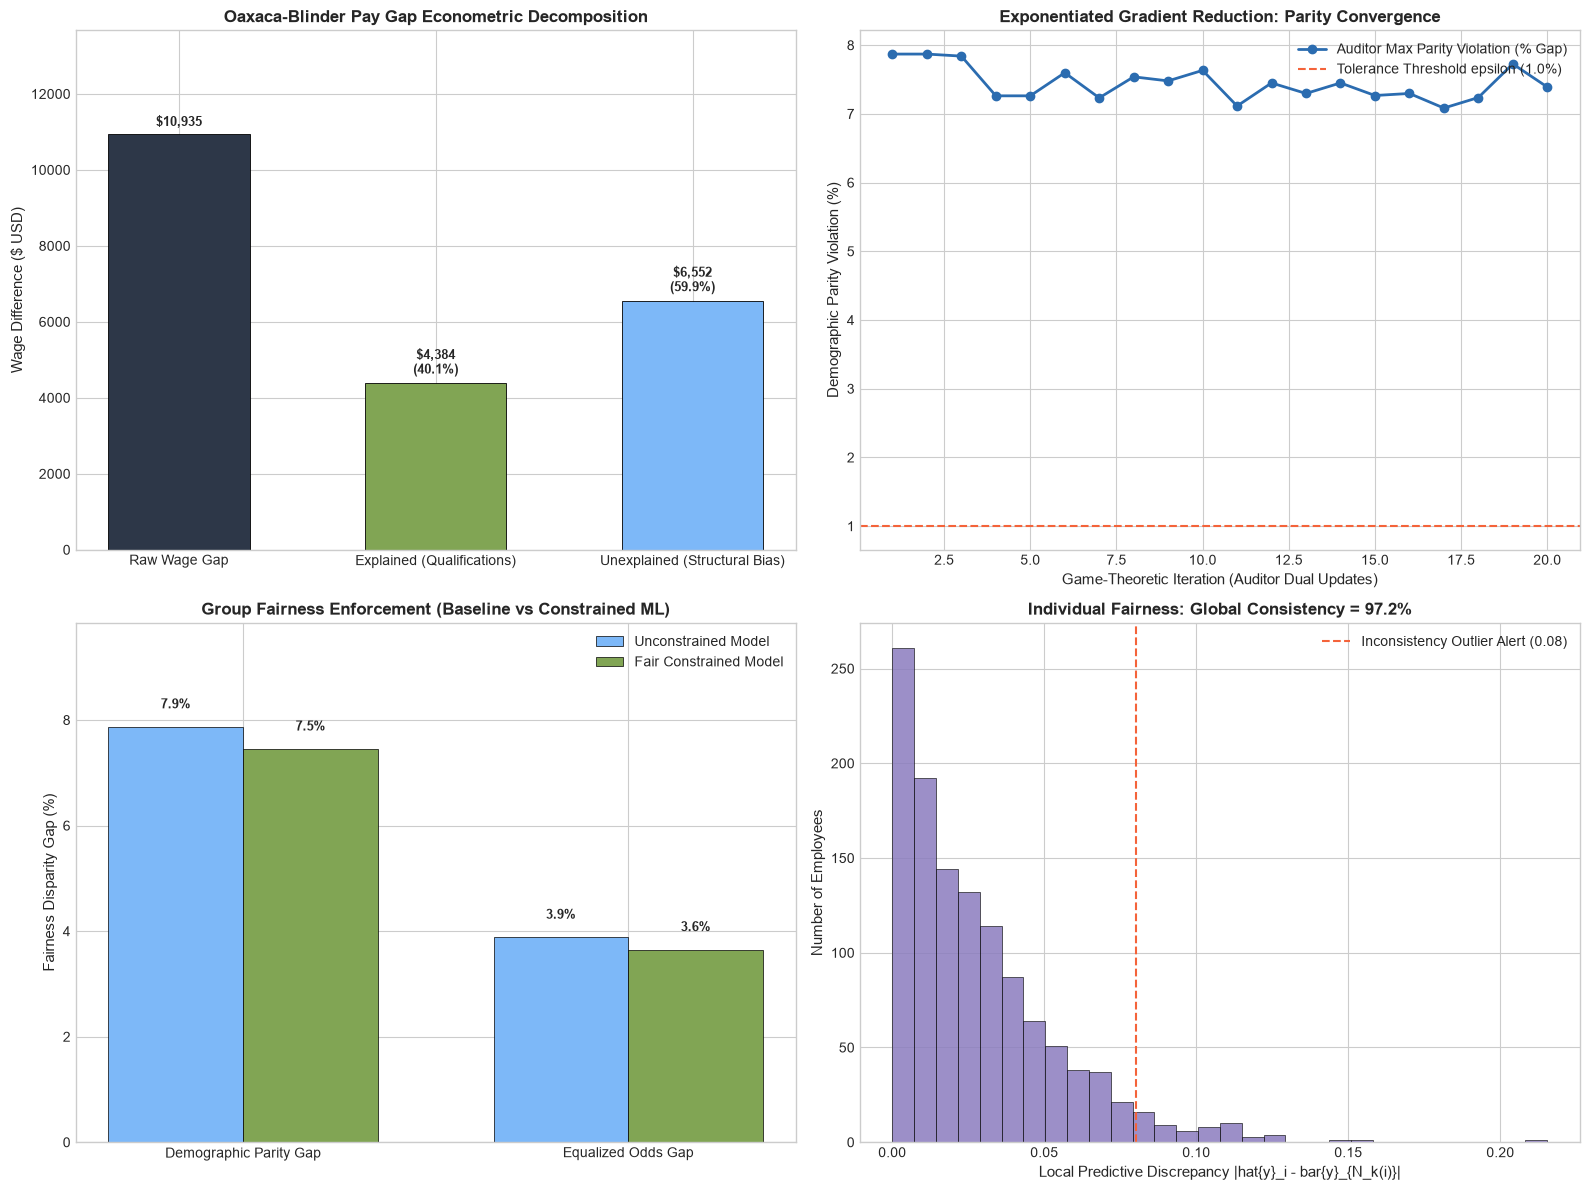

Oaxaca-Blinder Raw Wage Gap: $10,935.20
  - Explained by Qualifications: $4,383.58 (40.1%)
  - Unexplained Structural Bias: $6,551.62 (59.9%)
Demographic Parity Difference: 7.9% -> 7.5%
Equalized Odds Difference:     3.9% -> 3.6%
Global Individual Fairness Consistency: 97.16% (k=5 nearest neighbors)


In [35]:
# Generate workforce equity dataset with known qualification profiles and structural bias
equity_df = generate_algorithmic_equity_and_fairness_data(n_employees=1200, seed=42)
feature_cols = ['tenure_years', 'education_years', 'job_level', 'performance_rating', 'certifications']

# 1. Oaxaca-Blinder Pay Decomposition
ob_decomp = oaxaca_blinder_decomposition(
    df=equity_df,
    outcome_col='base_salary',
    group_col='demographic_group',
    feature_cols=feature_cols,
    group_majority=1,
    group_minority=0,
    reference_type='pooled'
)

# 2. Baseline vs Fair Machine Learning (Demographic Parity & Equalized Odds)
from sklearn.linear_model import LogisticRegression
X_fair = equity_df[feature_cols]
y_fair = equity_df['promotion_recommendation']
sens_fair = equity_df['demographic_group']

# Baseline unconstrained model
base_model = LogisticRegression(solver='liblinear', random_state=42).fit(X_fair, y_fair)
base_preds = base_model.predict(X_fair)
base_dp_gap = demographic_parity_difference(base_preds, sens_fair)
base_eo_gap = equalized_odds_difference(y_fair, base_preds, sens_fair)

# Exponentiated Gradient reduction for Demographic Parity
fair_dp_model = ExponentiatedGradientFairness(
    estimator=LogisticRegression(solver='liblinear', random_state=42),
    constraint='demographic_parity',
    eps=0.01,
    max_iter=20,
    random_state=42
).fit(X_fair, y_fair, sensitive_features=sens_fair)
fair_dp_preds = fair_dp_model.predict(X_fair)
fair_dp_gap = demographic_parity_difference(fair_dp_preds, sens_fair)

# Exponentiated Gradient reduction for Equalized Odds
fair_eo_model = ExponentiatedGradientFairness(
    estimator=LogisticRegression(solver='liblinear', random_state=42),
    constraint='equalized_odds',
    eps=0.02,
    max_iter=20,
    random_state=42
).fit(X_fair, y_fair, sensitive_features=sens_fair)
fair_eo_preds = fair_eo_model.predict(X_fair)
fair_eo_gap = equalized_odds_difference(y_fair, fair_eo_preds, sens_fair)

# 3. Individual Fairness & Local Predictive Consistency
cons_series, global_cons, ind_meta = calculate_individual_fairness_consistency(
    X=X_fair, y_pred=fair_dp_model.predict_proba(X_fair)[:, 1], n_neighbors=5
)

# Visualization: 4-Panel Algorithmic Equity & Fairness Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Oaxaca-Blinder Pay Decomposition Breakdown
components = ['Raw Wage Gap', 'Explained (Qualifications)', 'Unexplained (Structural Bias)']
values = [ob_decomp['raw_gap'], ob_decomp['explained_effect'], ob_decomp['unexplained_effect']]
colors = [PALETTE['dark_slate'], PALETTE['sage_green'], PALETTE['light_blue']]
bars = axes[0, 0].bar(components, values, color=colors, edgecolor='black', linewidth=0.6, width=0.55)
for bar in bars:
    h = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., h + 150,
                    f'${h:,.0f}\n({h/ob_decomp["raw_gap"]*100:.1f}%)' if h != ob_decomp['raw_gap'] else f'${h:,.0f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0, 0].set_ylabel('Wage Difference ($ USD)')
axes[0, 0].set_title('Oaxaca-Blinder Pay Gap Econometric Decomposition', fontweight='bold')
axes[0, 0].set_ylim(0, ob_decomp['raw_gap'] * 1.25)

# Panel 2: Exponentiated Gradient Dual Convergence
iterations = range(1, len(fair_dp_model.violation_history_) + 1)
axes[0, 1].plot(iterations, [v * 100 for v in fair_dp_model.violation_history_],
                marker='o', color=PALETTE['royal_blue'], linewidth=2.0, label='Auditor Max Parity Violation (% Gap)')
axes[0, 1].axhline(fair_dp_model.eps * 100, color=PALETTE['salmon'], linestyle='--', linewidth=1.5, label=f'Tolerance Threshold epsilon ({fair_dp_model.eps*100:.1f}%)')
axes[0, 1].set_xlabel('Game-Theoretic Iteration (Auditor Dual Updates)')
axes[0, 1].set_ylabel('Demographic Parity Violation (%)')
axes[0, 1].set_title('Exponentiated Gradient Reduction: Parity Convergence', fontweight='bold')
axes[0, 1].legend(loc='upper right')

# Panel 3: Group Fairness Constraint Comparison (Demographic Parity & Equalized Odds)
metric_labels = ['Demographic Parity Gap', 'Equalized Odds Gap']
base_metrics = [base_dp_gap * 100, base_eo_gap * 100]
fair_metrics = [fair_dp_gap * 100, fair_eo_gap * 100]

x_idx = np.arange(len(metric_labels))
bar_w = 0.35
b1 = axes[1, 0].bar(x_idx - bar_w/2, base_metrics, width=bar_w, color=PALETTE['light_blue'], edgecolor='black', linewidth=0.5, label='Unconstrained Model')
b2 = axes[1, 0].bar(x_idx + bar_w/2, fair_metrics, width=bar_w, color=PALETTE['sage_green'], edgecolor='black', linewidth=0.5, label='Fair Constrained Model')
for bar in b1:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in b2:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1, 0].set_xticks(x_idx)
axes[1, 0].set_xticklabels(metric_labels)
axes[1, 0].set_ylabel('Fairness Disparity Gap (%)')
axes[1, 0].set_title('Group Fairness Enforcement (Baseline vs Constrained ML)', fontweight='bold')
axes[1, 0].legend(loc='upper right')
axes[1, 0].set_ylim(0, max(base_metrics) * 1.25)

# Panel 4: Individual Fairness Local Consistency & Lipschitz Discrepancy
disc_vals = ind_meta['local_discrepancy']
outlier_thresh = ind_meta['outlier_threshold']
axes[1, 1].hist(disc_vals, bins=30, color=PALETTE['lilac'], edgecolor='black', linewidth=0.5, alpha=0.85)
axes[1, 1].axvline(outlier_thresh, color=PALETTE['salmon'], linestyle='--', linewidth=1.5, label=f'Inconsistency Outlier Alert ({outlier_thresh:.2f})')
axes[1, 1].set_xlabel('Local Predictive Discrepancy |hat{y}_i - bar{y}_{N_k(i)}|')
axes[1, 1].set_ylabel('Number of Employees')
axes[1, 1].set_title(f'Individual Fairness: Global Consistency = {global_cons*100:.1f}%', fontweight='bold')
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print detailed summary
print(f'Oaxaca-Blinder Raw Wage Gap: ${ob_decomp["raw_gap"]:,.2f}')
print(f'  - Explained by Qualifications: ${ob_decomp["explained_effect"]:,.2f} ({ob_decomp["explained_pct"]:.1f}%)')
print(f'  - Unexplained Structural Bias: ${ob_decomp["unexplained_effect"]:,.2f} ({ob_decomp["unexplained_pct"]:.1f}%)')
print(f'Demographic Parity Difference: {base_dp_gap*100:.1f}% -> {fair_dp_gap*100:.1f}%')
print(f'Equalized Odds Difference:     {base_eo_gap*100:.1f}% -> {fair_eo_gap*100:.1f}%')
print(f'Global Individual Fairness Consistency: {global_cons*100:.2f}% (k=5 nearest neighbors)')

## Part 10: Prescriptive Interventions: Causal Inference and Heterogeneous Uplift

Predicting the probability of an outcome (such as voluntary turnover) is fundamentally distinct from prescribing the optimal intervention to alter that probability. Standard predictive machine learning models conflate correlation with causation, rendering them vulnerable to severe selection bias and unobserved confounding when evaluating HR programs (such as leadership accelerators, retention bonuses, or flexible workplace policies).

Part 10 bridges the divide between predictive risk scoring and prescriptive causal decision-making:

### Feature 40: Augmented Inverse Propensity Weighting (AIPW)
AIPW is a doubly robust causal estimator combining Inverse Propensity Weighting (IPW) with Outcome Regression:
$$\text{ATE}_{AIPW} = \frac{1}{N} \sum_{i=1}^N \left( \hat{\mu}_1(X_i) - \hat{\mu}_0(X_i) + \frac{T_i (Y_i - \hat{\mu}_1(X_i))}{\hat{\pi}(X_i)} - \frac{(1 - T_i)(Y_i - \hat{\mu}_0(X_i))}{1 - \hat{\pi}(X_i)} \right)$$
AIPW guarantees consistency if either the propensity score model $\hat{\pi}(X)$ or the counterfactual outcome regression model $\hat{\mu}_t(X)$ is correctly specified, providing an indispensable margin of safety in noisy observational HR data.

### Feature 41: Synthetic Difference-in-Differences (SDiD)
When evaluating aggregate organizational policies (e.g. four-day workweeks or regional restructuring), traditional DiD fails when treated and control units do not share parallel pre-treatment trends. SDiD (Arkhangelsky et al., 2021) resolves this by computing regularized unit weights $\omega_i$ that match the pre-treatment trajectory of treated units and time weights $\lambda_t$ that match post-treatment levels:
$$\hat{\tau}^{SDiD} = \left( \frac{1}{N_{tr}} \sum_{i \in \text{Tr}} Y_{i, \text{post}} - \sum_{i \in \text{Co}} \omega_i Y_{i, \text{post}} \right) - \sum_{t \in \text{Pre}} \lambda_t \left( \frac{1}{N_{tr}} \sum_{i \in \text{Tr}} Y_{i, t} - \sum_{i \in \text{Co}} \omega_i Y_{i, t} \right)$$

### Feature 42: Causal Forests with Double Machine Learning (CausalForestDML)
To individualize interventions, CausalForestDML isolates the causal signal via Robinson orthogonalization (residualizing outcomes $\tilde{Y} = Y - \hat{m}(X)$ and treatment $\tilde{T} = T - \hat{e}(X)$) and enforces an honest splitting protocol. One disjoint data partition determines tree split points maximizing treatment effect heterogeneity, while a separate partition estimates leaf-level CATE effects $\hat{\tau}(X_i)$. This prevents overfitting and enables valid asymptotic confidence intervals to target 'persuadables'.

### Feature 43: Prescriptive Uplift Evaluation (Qini Curve, AUUC, and Doubly Robust MSE)
Because counterfactual ground truth is unobservable, the Qini curve evaluates cumulative incremental gains ordered by predicted uplift:
$$u_s = \sum_{i=1}^{N_t(s)} Y_i^T - \frac{N_t(s)}{N_c(s)} \sum_{i=1}^{N_c(s)} Y_i^C$$
AUUC provides a scalar metric of ranking accuracy, while Doubly Robust Expected MSE ($MSE_W$) measures true treatment effect accuracy using nuisance adjustments.

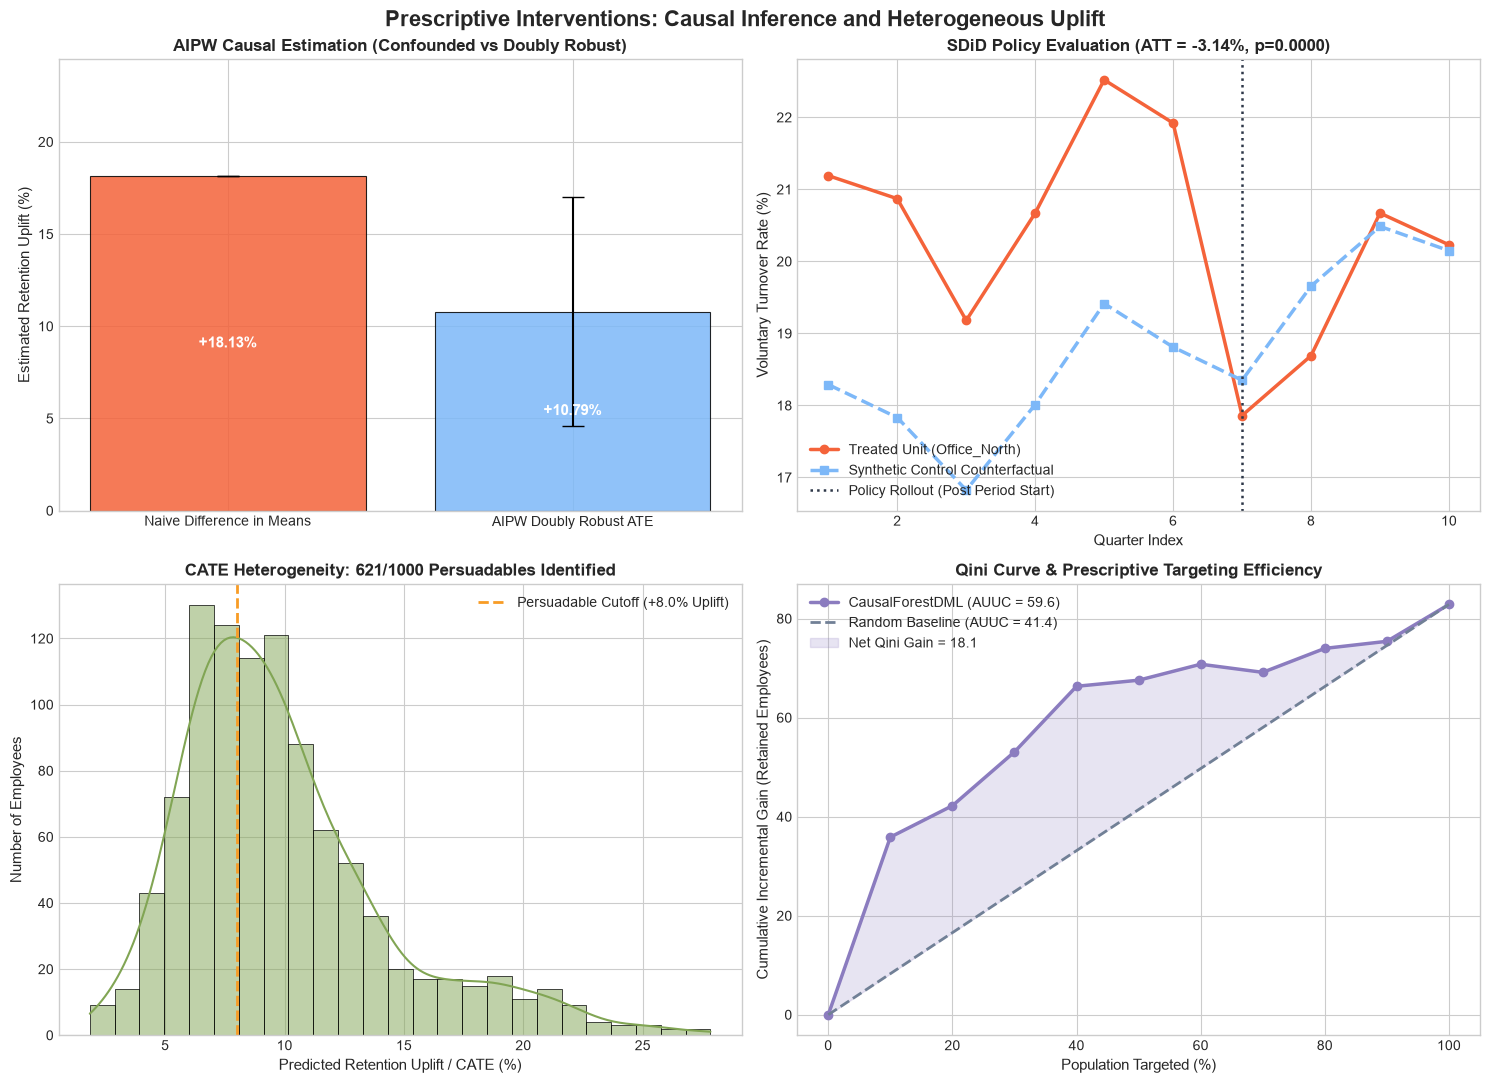

AIPW Doubly Robust ATE:          +10.79% (SE=3.16%, 95% CI: [4.60%, 16.99%])
Naive Observational Gap:         +18.13% (Confounded Selection Bias)
Synthetic DiD Policy ATT:        -3.14% Turnover Rate (SE=0.27%, p=0.0000)
Causal Forest Persuadables:      621/1000 employees (62.1%)
Prescriptive Uplift AUUC:        59.6 vs Random 41.4 (Net Qini: +18.1)
Doubly Robust MSE_W:             0.9478


In [36]:
# Generate observational cohort and panel policy datasets
causal_df = generate_causal_and_uplift_data(n_employees=1000, seed=42)
panel_df = generate_panel_policy_data(n_units=12, n_periods=10, treated_units=('Office_North',), post_period_start=7, seed=42)

feature_cols = ['tenure_years', 'prior_performance', 'flight_risk', 'overtime_hours', 'manager_quality']
X_cau = causal_df[feature_cols]
t_cau = causal_df['treatment_enrolled']
y_cau = causal_df['retained_1yr']

# 1. Augmented Inverse Propensity Weighting (AIPW)
aipw_res = aipw_estimator(y=y_cau, treatment=t_cau, X=X_cau, n_splits=5, random_state=42)

# 2. Synthetic Difference-in-Differences (SDiD)
sdid_res = synthetic_difference_in_differences(
    df=panel_df,
    unit_col='location_id',
    time_col='quarter_idx',
    outcome_col='turnover_rate',
    treated_units=['Office_North'],
    post_period_start=7,
)

# 3. Causal Forest with DML & Honest Splitting
cf_dml = CausalForestDML(n_estimators=35, max_depth=3, min_samples_leaf=12, random_state=42)
cf_dml.fit(X_cau, t_cau, y_cau)
persuadables_df = cf_dml.identify_persuadables(X_cau, min_effect=0.08)
cate_preds = persuadables_df['predicted_cate']

# 4. Qini Curve & AUUC Uplift Evaluation
qini_df = qini_curve(y_cau, t_cau, cate_preds, n_bins=10)
auuc_res = area_under_uplift_curve(y_cau, t_cau, cate_preds, n_bins=10)
dr_eval = doubly_robust_uplift_eval(y_cau, t_cau, cate_preds, X_cau)

# 4-Panel Prescriptive Causal Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Prescriptive Interventions: Causal Inference and Heterogeneous Uplift', fontsize=16, fontweight='bold')

# Panel 1: AIPW Doubly Robust ATE vs Confounded Naive Difference in Means
methods = ['Naive Difference in Means', 'AIPW Doubly Robust ATE']
ates = [aipw_res['naive_ate'] * 100, aipw_res['ate'] * 100]
yerrs = [0.0, 1.96 * aipw_res['se'] * 100]
bar_colors = [PALETTE['salmon'], PALETTE['light_blue']]
bars = axes[0, 0].bar(methods, ates, yerr=yerrs, capsize=8, color=bar_colors, edgecolor='black', linewidth=0.8, alpha=0.85)
for bar, val in zip(bars, ates):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'+{val:.2f}%', ha='center', va='center', fontweight='bold', color='white', fontsize=11)
axes[0, 0].set_ylabel('Estimated Retention Uplift (%)')
axes[0, 0].set_title('AIPW Causal Estimation (Confounded vs Doubly Robust)', fontweight='bold')
axes[0, 0].set_ylim(0, max(ates) * 1.35)

# Panel 2: Synthetic Difference-in-Differences (SDiD) Panel Trajectory
piv = panel_df.pivot(index='quarter_idx', columns='location_id', values='turnover_rate')
ctrl_units = [u for u in piv.columns if u != 'Office_North']
omega = sdid_res['unit_weights']
syn_traj = (piv[ctrl_units] * omega[ctrl_units]).sum(axis=1)
axes[0, 1].plot(piv.index, piv['Office_North'], marker='o', linewidth=2.5, color=PALETTE['salmon'], label='Treated Unit (Office_North)')
axes[0, 1].plot(piv.index, syn_traj, marker='s', linewidth=2.5, linestyle='--', color=PALETTE['light_blue'], label='Synthetic Control Counterfactual')
axes[0, 1].axvline(7, color=PALETTE['dark_slate'], linestyle=':', linewidth=1.8, label='Policy Rollout (Post Period Start)')
axes[0, 1].set_xlabel('Quarter Index')
axes[0, 1].set_ylabel('Voluntary Turnover Rate (%)')
axes[0, 1].set_title(f'SDiD Policy Evaluation (ATT = {sdid_res["att"]:.2f}%, p={sdid_res["p_value"]:.4f})', fontweight='bold')
axes[0, 1].legend(loc='lower left')

# Panel 3: Causal Forest Heterogeneous Treatment Effect Distribution (CATE)
sns.histplot(cate_preds * 100, bins=25, kde=True, ax=axes[1, 0], color=PALETTE['sage_green'], edgecolor='black', linewidth=0.5)
axes[1, 0].axvline(8.0, color=PALETTE['light_orange'], linestyle='--', linewidth=2, label='Persuadable Cutoff (+8.0% Uplift)')
n_pers = int(persuadables_df['is_persuadable'].sum())
axes[1, 0].set_xlabel('Predicted Retention Uplift / CATE (%)')
axes[1, 0].set_ylabel('Number of Employees')
axes[1, 0].set_title(f'CATE Heterogeneity: {n_pers}/{len(causal_df)} Persuadables Identified', fontweight='bold')
axes[1, 0].legend(loc='upper right')

# Panel 4: Qini Curve (Cumulative Incremental Gain vs Random Targeting)
axes[1, 1].plot(qini_df['fraction'] * 100, qini_df['incremental_gain'], marker='o', linewidth=2.5, color=PALETTE['lilac'], label=f'CausalForestDML (AUUC = {auuc_res["auuc"]:.1f})')
axes[1, 1].plot(qini_df['fraction'] * 100, qini_df['random_gain'], linestyle='--', linewidth=2, color=PALETTE['muted_gray'], label=f'Random Baseline (AUUC = {auuc_res["auuc_random"]:.1f})')
axes[1, 1].fill_between(qini_df['fraction'] * 100, qini_df['incremental_gain'], qini_df['random_gain'], color=PALETTE['lilac'], alpha=0.2, label=f'Net Qini Gain = {auuc_res["qini_score"]:.1f}')
axes[1, 1].set_xlabel('Population Targeted (%)')
axes[1, 1].set_ylabel('Cumulative Incremental Gain (Retained Employees)')
axes[1, 1].set_title('Qini Curve & Prescriptive Targeting Efficiency', fontweight='bold')
axes[1, 1].legend(loc='upper left')

plt.tight_layout()
plt.show()

# Detailed Prescriptive Diagnostics Printout
print(f'AIPW Doubly Robust ATE:          +{aipw_res["ate"]*100:.2f}% (SE={aipw_res["se"]*100:.2f}%, 95% CI: [{aipw_res["ci_lower"]*100:.2f}%, {aipw_res["ci_upper"]*100:.2f}%])')
print(f'Naive Observational Gap:         +{aipw_res["naive_ate"]*100:.2f}% (Confounded Selection Bias)')
print(f'Synthetic DiD Policy ATT:        {sdid_res["att"]:.2f}% Turnover Rate (SE={sdid_res["se"]:.2f}%, p={sdid_res["p_value"]:.4f})')
print(f'Causal Forest Persuadables:      {n_pers}/{len(causal_df)} employees ({n_pers/len(causal_df)*100:.1f}%)')
print(f'Prescriptive Uplift AUUC:        {auuc_res["auuc"]:.1f} vs Random {auuc_res["auuc_random"]:.1f} (Net Qini: +{auuc_res["qini_score"]:.1f})')
print(f'Doubly Robust MSE_W:             {dr_eval["mse_w"]:.4f}')

### Feature 44: Synthetic Control Weights (Synth-DiD Synthetic Twin & Causal Lift)

Standard Difference-in-Differences (DiD) compares pilot locations to control locations, but finding a 1-to-1 parallel match across complex store footprints is virtually impossible. Synthetic Control algorithms use convex optimization to assign non-negative weights $W^* = [w_1, \dots, w_J]^T$ (with $\sum w_j = 1$) to an untreated donor pool, blending them into a 'synthetic twin' that mirrors the pilot location's pre-treatment trajectory:

$$\min_{W, c_0} \|Y_{1, \text{pre}} - (c_0 + Y_{0, \text{pre}} W)\|_2^2 + \lambda \|W\|_2^2 \quad \text{subject to } w_j \ge 0, \sum_{j=1}^J w_j = 1$$

**Retail Footprint Rollout Application**:
An enterprise rolls out an automated scheduling tool to 5 pilot stores. Synthetic control weights create a mathematical twin for each store from 25 untreated donor locations. The post-rollout divergence between the actual pilot store and its synthetic twin directly isolates the **True Causal Lift** of the scheduling tool.

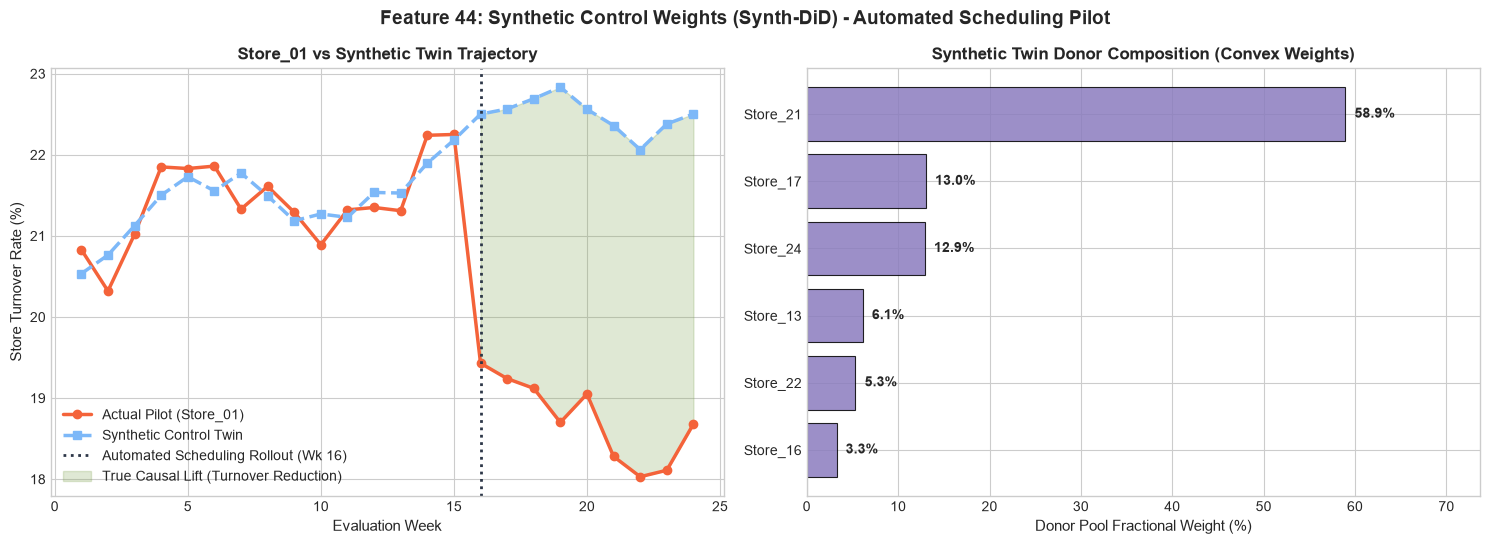

--- Synthetic Control Pilot Store Performance ---
pilot_unit  pre_rmspe  post_actual_mean  post_synthetic_mean  post_causal_lift  post_causal_lift_pct
  Store_01     0.2709            18.738               22.495            -3.757                -16.70
  Store_02     0.3014            12.466               16.593            -4.128                -24.88
  Store_03     0.2460            16.344               19.834            -3.490                -17.60
  Store_04     0.2375            12.568               17.354            -4.786                -27.58
  Store_05     0.2114            15.431               19.833            -4.402                -22.19

Aggregate Causal Lift across all 5 pilot stores: -4.11% turnover (-21.8%)


In [37]:
# Generate longitudinal retail scheduling pilot panel (30 stores, 24 weeks, 5 pilots)
pilot_stores = ['Store_01', 'Store_02', 'Store_03', 'Store_04', 'Store_05']
retail_df = generate_retail_scheduling_pilot_data(
    n_stores=30,
    n_weeks=24,
    pilot_stores=tuple(pilot_stores),
    rollout_week=16,
    seed=42,
)

# Build synthetic control twins and compute causal lift
synth_res = build_multi_pilot_synthetic_controls(
    df=retail_df,
    unit_col='store_id',
    time_col='week_idx',
    outcome_col='turnover_rate',
    pilot_units=pilot_stores,
    post_period_start=16,
)

# Extract Store_01 trajectory and donor weights for focused visualization
s01_traj = synth_res['trajectories_df'].query("store_id == 'Store_01'")
s01_weights = synth_res['weights_matrix'].loc['Store_01']
active_weights = s01_weights[s01_weights > 0.01].sort_values(ascending=True)

# 2-Panel Synthetic Control Visualization
fig, (ax_traj, ax_w) = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Synthetic Control Weights (Synth-DiD) - Automated Scheduling Pilot', fontsize=14, fontweight='bold')

# Panel 1: Longitudinal Pilot vs Synthetic Twin Trajectory
ax_traj.plot(s01_traj['week_idx'], s01_traj['actual_outcome'], marker='o', linewidth=2.5, color=PALETTE['salmon'], label='Actual Pilot (Store_01)')
ax_traj.plot(s01_traj['week_idx'], s01_traj['synthetic_twin'], marker='s', linewidth=2.5, linestyle='--', color=PALETTE['light_blue'], label='Synthetic Control Twin')
ax_traj.axvline(16, color=PALETTE['dark_slate'], linestyle=':', linewidth=2, label='Automated Scheduling Rollout (Wk 16)')
post_mask = s01_traj['week_idx'] >= 16
ax_traj.fill_between(s01_traj.loc[post_mask, 'week_idx'], s01_traj.loc[post_mask, 'actual_outcome'], s01_traj.loc[post_mask, 'synthetic_twin'], color=PALETTE['sage_green'], alpha=0.25, label='True Causal Lift (Turnover Reduction)')
ax_traj.set_xlabel('Evaluation Week')
ax_traj.set_ylabel('Store Turnover Rate (%)')
ax_traj.set_title('Store_01 vs Synthetic Twin Trajectory', fontweight='bold')
ax_traj.legend(loc='lower left')

# Panel 2: Convex Donor Weights Horizontal Bar Chart
y_pos = np.arange(len(active_weights))
bars = ax_w.barh(y_pos, active_weights.values * 100, color=PALETTE['lilac'], edgecolor='black', linewidth=0.8, alpha=0.85)
ax_w.set_yticks(y_pos)
ax_w.set_yticklabels(active_weights.index)
ax_w.set_xlabel('Donor Pool Fractional Weight (%)')
ax_w.set_title('Synthetic Twin Donor Composition (Convex Weights)', fontweight='bold')
for bar, val in zip(bars, active_weights.values * 100):
    ax_w.text(bar.get_width() + 1.0, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
ax_w.set_xlim(0, max(active_weights.values * 100) * 1.25)

plt.tight_layout()
plt.show()

# Print pilot evaluation summary
print('--- Synthetic Control Pilot Store Performance ---')
summary_table = synth_res['summary_df'][['pilot_unit', 'pre_rmspe', 'post_actual_mean', 'post_synthetic_mean', 'post_causal_lift', 'post_causal_lift_pct']]
print(summary_table.to_string(index=False))
print(f'\nAggregate Causal Lift across all 5 pilot stores: {synth_res["aggregate_causal_lift"]:+.2f}% turnover ({synth_res["aggregate_causal_lift_pct"]:+.1f}%)')


### Feature 45: Directed Causal Edge Weights (DAG Discovery & Confounder Untangling)

Correlation matrices only reveal that workforce variables move together, not the underlying direction of causation. In the classic **'Overtime vs Turnover' death spiral**, high correlation ($r > 0.65$) suggests overtime directly causes voluntary turnover. However, standard regression or correlation cannot determine if Overtime strictly causes Turnover, or if a third hidden variable—such as **Manager Absence** or **Understaffing Shocks**—is an upstream mutual confounder causing both.

#### Mathematical Formulation (NOTEARS Continuous DAG Learning):
The algorithm solves a continuous Augmented Lagrangian optimization over a linear Structural Equation Model (SEM) $X = X W + Z$:
$$\min_{W} \frac{1}{2n} \|X - X W\|_F^2 + \lambda_1 \|W\|_1 \quad \text{subject to } h(W) = \text{Tr}\left(\exp(W \circ W)\right) - d = 0$$

#### Total Causal Path Calculus:
Beyond direct edge weights $W$, the total causal effect of intervening on an upstream root cause across all direct and mediated pathways is calculated via Leontief path calculus:
$$\mathbf{T} = (\mathbf{I} - W)^{-1} - \mathbf{I} = \sum_{k=1}^\infty W^k$$

#### The People Analytics Application:
Learning the true DAG reveals whether overtime directly drives turnover or is mediated by burnout, while diagnosing whether managerial absences act as the true root cause. Feeding directed causal edge weights into downstream models ensures HR leadership optimizes for actual root drivers rather than treating symptom proxy metrics.

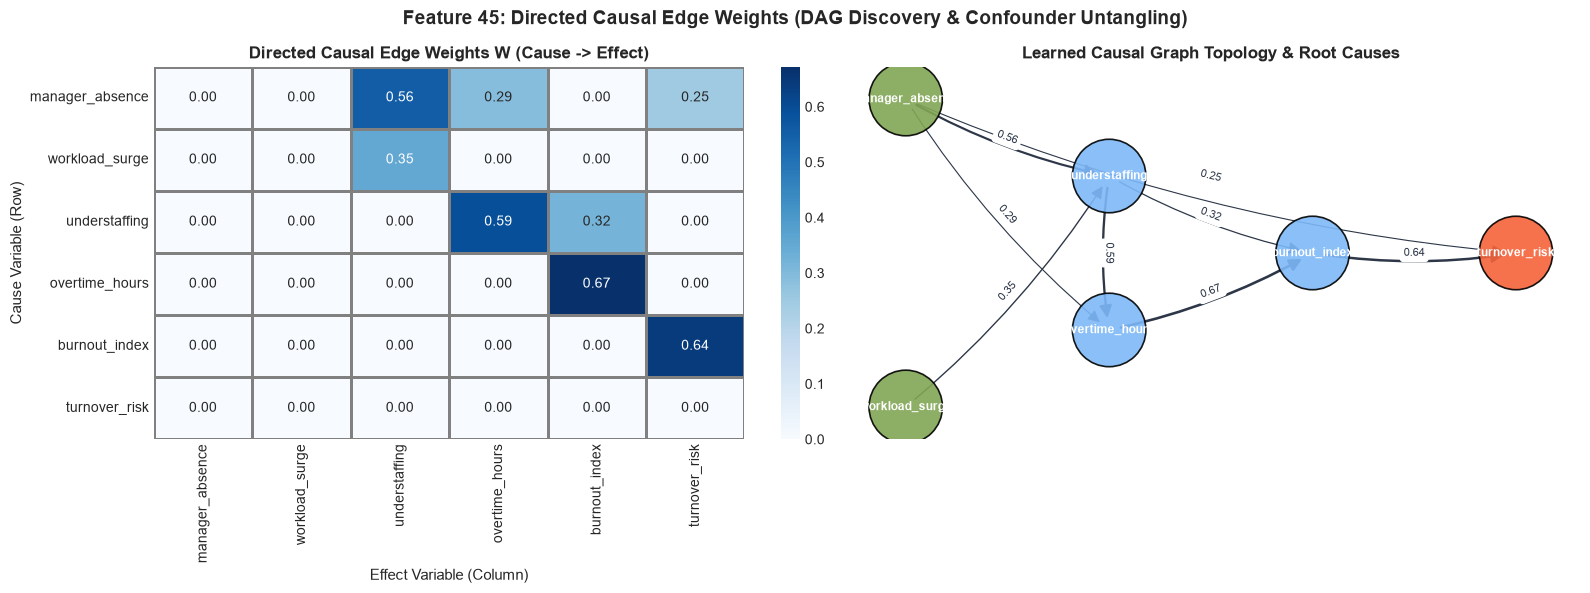

--- Causal DAG Discovery Results ---
Discovered Root Causes: ['manager_absence', 'workload_surge']
Discovered Sink Outcomes: ['turnover_risk']
Causal Topological Order: manager_absence -> workload_surge -> understaffing -> overtime_hours -> burnout_index -> turnover_risk

Confounder Diagnosis (Overtime vs Turnover):
  - Observed Pearson Correlation: r = 0.66
  - Direct Causal Weight:         w = 0.00
  - Common Upstream Confounders:  ['manager_absence', 'understaffing', 'workload_surge']
  - Diagnostic Verdict:           Mediated & Confounded: 'overtime_hours' impacts 'turnover_risk' through indirect pathway, but shared ancestors ['manager_absence', 'understaffing', 'workload_surge'] inflate correlation.


In [38]:
# Generate workforce observational dataset with known causal DAG
dag_df = generate_overtime_turnover_causal_dag_data(n_samples=1000, seed=42)

# Learn Directed Acyclic Graph (DAG) and directed causal edge weights
dag_res = compute_directed_causal_edge_weights(dag_df, lambda1=0.03, threshold=0.15)
W_df = dag_res['directed_weights_df']
corr_df = dag_res['correlation_matrix']

# Diagnose confounding in Overtime vs Turnover
diag = diagnose_causal_confounding(W_df, 'overtime_hours', 'turnover_risk', corr_matrix=corr_df)

# 2-Panel Causal Discovery Dashboard
fig, (ax_heat, ax_dag) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Directed Causal Edge Weights (DAG Discovery & Confounder Untangling)', fontsize=14, fontweight='bold')

# Panel 1: Heatmap of Directed Causal Edge Weights W (Row -> Column)
sns.heatmap(W_df, annot=True, fmt='.2f', cmap='Blues', ax=ax_heat, cbar=True, linewidths=0.8, linecolor='gray')
ax_heat.set_title('Directed Causal Edge Weights W (Cause -> Effect)', fontweight='bold')
ax_heat.set_xlabel('Effect Variable (Column)')
ax_heat.set_ylabel('Cause Variable (Row)')

# Panel 2: Discovered Directed Acyclic Graph (DAG) Network
G = dag_res['graph']
pos = {
    'manager_absence': (-1.0, 1.0),
    'workload_surge': (-1.0, -1.0),
    'understaffing': (0.0, 0.5),
    'overtime_hours': (0.0, -0.5),
    'burnout_index': (1.0, 0.0),
    'turnover_risk': (2.0, 0.0),
}
node_colors = []
for node in G.nodes():
    if node in dag_res['root_causes']:
        node_colors.append(PALETTE['sage_green'])  # Root cause
    elif node in dag_res['sink_outcomes']:
        node_colors.append(PALETTE['salmon'])      # Sink outcome
    else:
        node_colors.append(PALETTE['light_blue'])  # Mediator

nx.draw_networkx_nodes(G, pos, ax=ax_dag, node_color=node_colors, node_size=2800, alpha=0.9, edgecolors='black', linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax_dag, font_size=8.5, font_weight='bold', font_color='white')
edge_weights = [max(0.8, G[u][v]['weight'] * 2.8) for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, ax=ax_dag, width=edge_weights, arrowsize=18, arrowstyle='-|>', edge_color=PALETTE['dark_slate'], connectionstyle='arc3,rad=0.08')
edge_labels = {(u, v): f'{G[u][v]["weight"]:.2f}' for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax_dag, font_size=8, font_color=PALETTE['dark_slate'])
ax_dag.set_title('Learned Causal Graph Topology & Root Causes', fontweight='bold')
ax_dag.axis('off')

plt.tight_layout()
plt.show()

# Print diagnostics
print('--- Causal DAG Discovery Results ---')
print(f'Discovered Root Causes: {dag_res["root_causes"]}')
print(f'Discovered Sink Outcomes: {dag_res["sink_outcomes"]}')
print(f'Causal Topological Order: {" -> ".join(dag_res["topological_order"])}')
print(f'\nConfounder Diagnosis (Overtime vs Turnover):')
print(f'  - Observed Pearson Correlation: r = {diag["observed_correlation"]:.2f}')
print(f'  - Direct Causal Weight:         w = {diag["direct_causal_weight"]:.2f}')
print(f'  - Common Upstream Confounders:  {diag["common_confounders"]}')
print(f'  - Diagnostic Verdict:           {diag["verdict"]}')


## Part 11: Continuous-Time Trajectories & Heterogeneous Graph Representation Learning

Modeling the complex progression of an employee's career—encompassing promotions, lateral moves, and eventual attrition—requires advanced probabilistic techniques capable of handling irregular intervals and multi-state dynamics. Standard predictive models and discrete-time Markov chains inherently assume that state transitions occur at fixed, discrete intervals, severely misrepresenting the continuous and stochastic nature of professional mobility.

Part 11 introduces continuous-time stochastic modeling and heterogeneous multigraph representation learning:

### Feature 46: Continuous-Time Markov Chains (CTMC)
A CTMC is characterized by a state space $S$ and an infinitesimal generator transition rate matrix $Q \in \mathbb{R}^{M \times M}$:
- Off-diagonal elements $q_{ij} \ge 0$ ($i \neq j$) represent the instantaneous transition rate from state $i$ to state $j$.
- Diagonal elements $q_{ii} = -\sum_{j \neq i} q_{ij} \le 0$ ensure that each row sums to zero.

The transition probability matrix over any arbitrary continuous time horizon $t \ge 0$ is calculated via the matrix exponential:
$$P(t) = \exp(Q t) = \sum_{k=0}^{\infty} \frac{(Q t)^k}{k!}$$

The expected sojourn time—the duration an employee remains in state $i$ before transitioning—is:
$$\mathbb{E}[T_i] = \frac{1}{-q_{ii}} = \frac{1}{\sum_{j \neq i} q_{ij}}$$
This stochastic formulation isolates structural promotion bottlenecks and enables continuous career trajectory forecasting.

### Feature 47: Meta-Path Biased Random Walks on Heterogeneous Multigraphs
Enterprise ecosystems are heterogeneous multigraphs comprising diverse node types (Employees, Projects, Skills, Departments) and typed relations. Meta-path-biased random walks strictly govern sampling paths according to predefined composite relation schemas (e.g., $Employee \xrightarrow{assigned\_to} Project \xrightarrow{requires} Skill \xrightarrow{possessed\_by} Employee$), capturing multifaceted structural context that single-relation graphs miss.

### Feature 48: Metapath2Vec Graph Representation Learning & Complementarity
These structured walks are transformed into dense entity embedding vectors via shifted Positive Pointwise Mutual Information (SPPMI) low-rank matrix decomposition:
$$\text{SPPMI}(u, v) = \max\left(0, \log\left(\frac{\#(u, v) \cdot |\mathcal{D}|}{\#(u) \cdot \#(v) \cdot k}\right)\right)$$
Embeddings preserve semantic affinities, allowing cosine similarity to uncover cross-department talent complementarity and latent skill adjacencies.

### Feature 49: Dynamic Entity & Trajectory Self-Attention Aggregator
A multi-head scaled dot-product attention aggregator dynamically weights heterogeneous entity tokens (career trajectory state, historical projects, acquired skills) based on operational staffing criteria:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

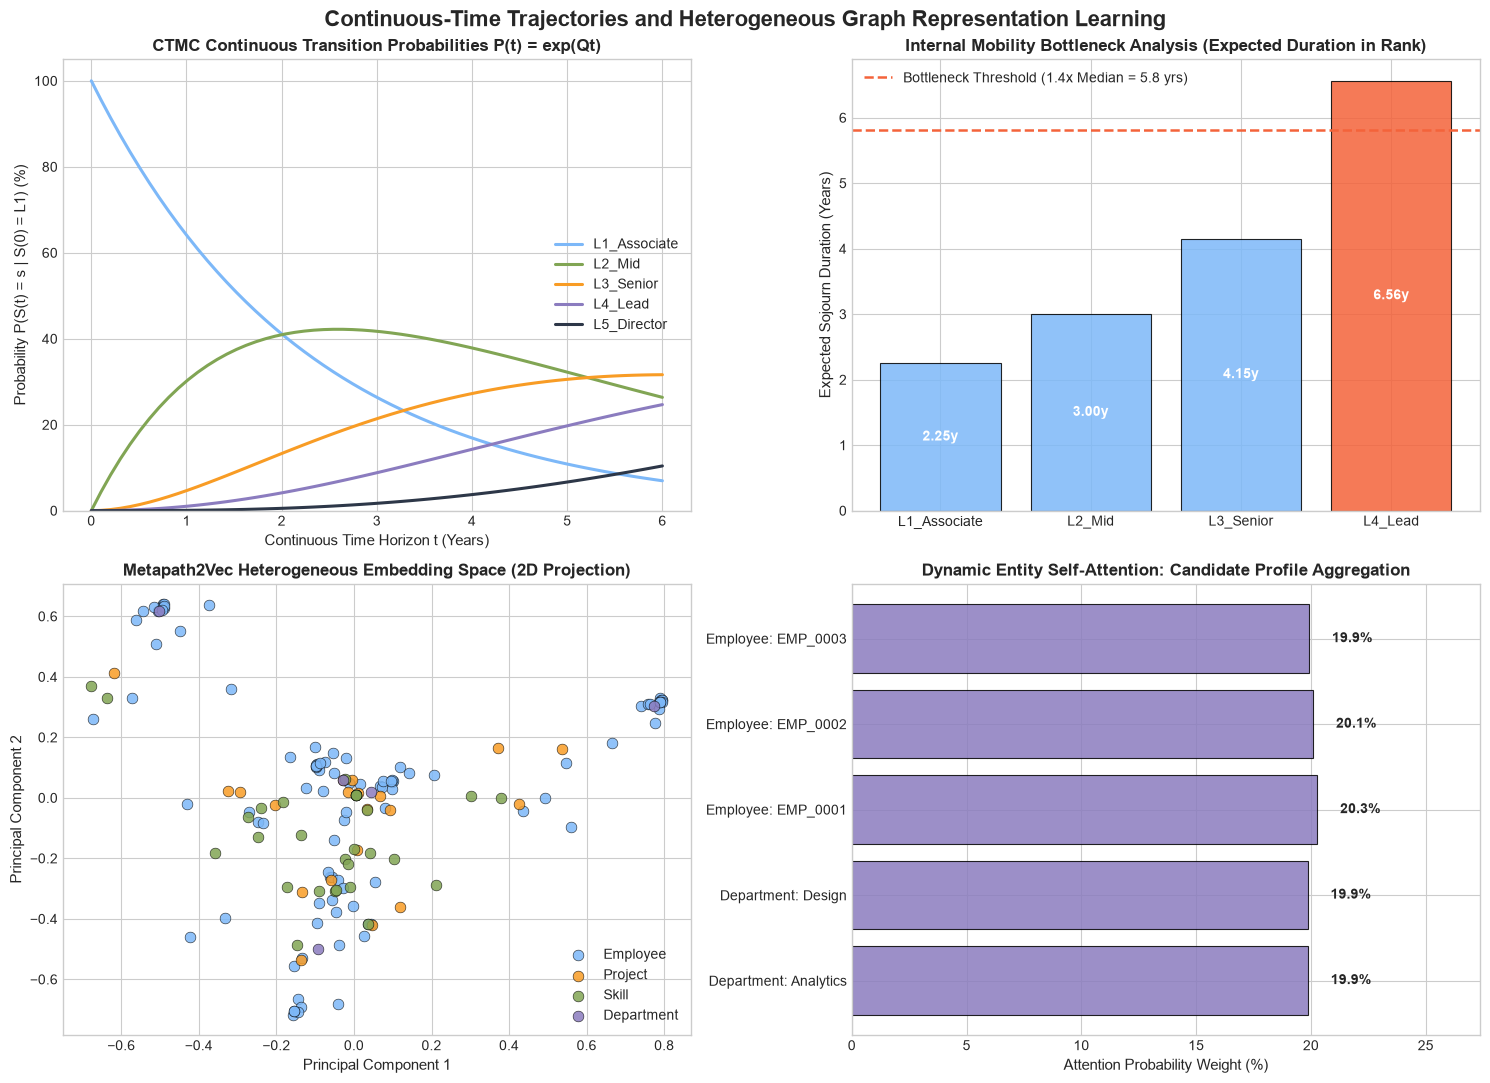

CTMC Infinitesimal Generator Matrix Q:
[[-0.444  0.444  0.     0.     0.   ]
 [ 0.    -0.333  0.294  0.039  0.   ]
 [ 0.     0.    -0.241  0.229  0.011]
 [ 0.     0.     0.    -0.152  0.152]
 [ 0.     0.     0.     0.    -0.   ]]

Expected Sojourn Times (Years):
L1_Associate    2.25
L2_Mid          3.00
L3_Senior       4.15
L4_Lead         6.56
L5_Director      inf
Name: expected_sojourn_years, dtype: float64

Identified Pipeline Bottlenecks: [np.str_('L4_Lead')]
Metapath2Vec Total Heterogeneous Entities Embedded: 155
Dynamic Self-Attention Context Vector Dimensions: 16


In [39]:
# Generate career event log and heterogeneous organizational multigraph
event_log = generate_career_trajectory_event_log(n_employees=600, max_years=8.0, seed=42)
G_het, nodes_df, edges_df = generate_heterogeneous_hcm_multigraph(n_employees=100, n_projects=20, n_skills=30, seed=42)

# 1. Continuous-Time Markov Chain (CTMC)
ctmc = ContinuousTimeMarkovChain()
ctmc.fit_from_event_log(event_log)
sojourn_df = ctmc.expected_sojourn_times()
bottlenecks_df = ctmc.identify_pipeline_bottlenecks()

# Continuous transition curves over t in [0, 6] years
t_eval = np.linspace(0.0, 6.0, 60)
p_curves = {s: [] for s in ctmc.state_labels}
for t in t_eval:
    dist = ctmc.predict_trajectory_distribution('L1_Associate', t=t)
    for s in ctmc.state_labels:
        p_curves[s].append(dist[s])

# 2. Metapath2Vec Graph Representation Learning
mp2v = Metapath2Vec(embedding_dim=16, walk_length=15, num_walks=6, window_size=3, random_state=42)
mp2v.fit(G_het)

# 2D PCA semantic projection
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
embed_2d = pca.fit_transform(mp2v.embeddings_.values)
embed_df = pd.DataFrame(embed_2d, index=mp2v.embeddings_.index, columns=['pca_1', 'pca_2'])
embed_df['node_type'] = [mp2v.node_types_.get(n, 'Unknown') for n in embed_df.index]

# 3. Dynamic Self-Attention Aggregation
sample_tokens = mp2v.embeddings_.iloc[:5].values
sample_labels = [f'{mp2v.node_types_.get(n, "")}: {n}' for n in mp2v.embeddings_.index[:5]]
attn_agg = DynamicEntitySelfAttention(n_heads=2, random_state=42)
attn_res = attn_agg.aggregate(sample_tokens)

# 4-Panel Visualization Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Continuous-Time Trajectories and Heterogeneous Graph Representation Learning', fontsize=16, fontweight='bold')

# Panel 1: CTMC Continuous Career Trajectory Evolution from L1_Associate
state_colors = [PALETTE['light_blue'], PALETTE['sage_green'], PALETTE['light_orange'], PALETTE['lilac'], PALETTE['dark_slate'], PALETTE['salmon']]
for (s, curve), color in zip(p_curves.items(), state_colors):
    axes[0, 0].plot(t_eval, np.array(curve) * 100, label=s, linewidth=2.2, color=color)
axes[0, 0].set_xlabel('Continuous Time Horizon t (Years)')
axes[0, 0].set_ylabel('Probability P(S(t) = s | S(0) = L1) (%)')
axes[0, 0].set_title('CTMC Continuous Transition Probabilities P(t) = exp(Qt)', fontweight='bold')
axes[0, 0].legend(loc='center right')
axes[0, 0].set_ylim(0, 105)

# Panel 2: Expected Sojourn Time & Internal Mobility Bottlenecks
transient_states = [s for s in ctmc.state_labels if s != 'Attrition']
sojourn_vals = [sojourn_df[s] for s in transient_states]
median_soj = np.median(sojourn_vals)
bar_colors = [PALETTE['salmon'] if bottlenecks_df.loc[s, 'is_mobility_bottleneck'] else PALETTE['light_blue'] for s in transient_states]
bars = axes[0, 1].bar(transient_states, sojourn_vals, color=bar_colors, edgecolor='black', linewidth=0.8, alpha=0.85)
axes[0, 1].axhline(median_soj * 1.4, color=PALETTE['salmon'], linestyle='--', linewidth=1.8, label=f'Bottleneck Threshold (1.4x Median = {median_soj*1.4:.1f} yrs)')
for bar in bars:
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{bar.get_height():.2f}y', ha='center', va='center', fontweight='bold', color='white', fontsize=10)
axes[0, 1].set_ylabel('Expected Sojourn Duration (Years)')
axes[0, 1].set_title('Internal Mobility Bottleneck Analysis (Expected Duration in Rank)', fontweight='bold')
axes[0, 1].legend(loc='upper left')

# Panel 3: Metapath2Vec 2D Semantic Space
type_palette = {'Employee': PALETTE['light_blue'], 'Project': PALETTE['light_orange'], 'Skill': PALETTE['sage_green'], 'Department': PALETTE['lilac']}
for n_type, color in type_palette.items():
    sub = embed_df[embed_df['node_type'] == n_type]
    axes[1, 0].scatter(sub['pca_1'], sub['pca_2'], label=n_type, color=color, alpha=0.85, s=60, edgecolors='black', linewidth=0.4)
axes[1, 0].set_xlabel('Principal Component 1')
axes[1, 0].set_ylabel('Principal Component 2')
axes[1, 0].set_title('Metapath2Vec Heterogeneous Embedding Space (2D Projection)', fontweight='bold')
axes[1, 0].legend(loc='lower right')

# Panel 4: Dynamic Self-Attention Token Weights
weights = attn_res['attention_weights'].values * 100
axes[1, 1].barh(sample_labels, weights, color=PALETTE['lilac'], edgecolor='black', linewidth=0.8, alpha=0.85)
for i, w in enumerate(weights):
    axes[1, 1].text(w + 1.0, i, f'{w:.1f}%', va='center', fontweight='bold', fontsize=10)
axes[1, 1].set_xlabel('Attention Probability Weight (%)')
axes[1, 1].set_title('Dynamic Entity Self-Attention: Candidate Profile Aggregation', fontweight='bold')
axes[1, 1].set_xlim(0, max(weights) * 1.35)

plt.tight_layout()
plt.show()

# Print summary diagnostics
print('CTMC Infinitesimal Generator Matrix Q:')
print(ctmc.generator_matrix_.round(3))
print('\nExpected Sojourn Times (Years):')
print(sojourn_df.round(2))
flagged_bottlenecks = bottlenecks_df[bottlenecks_df['is_mobility_bottleneck']].index.tolist()
print(f'\nIdentified Pipeline Bottlenecks: {flagged_bottlenecks}')
print(f'Metapath2Vec Total Heterogeneous Entities Embedded: {len(mp2v.embeddings_)}')
print(f'Dynamic Self-Attention Context Vector Dimensions: {len(attn_res["context_vector"])}')

# Summary: The 50 Advanced People Analytics Features

| # | Feature Name | Primary Problem Solved | Mathematical Foundation | People Analytics Business Value |
|---|---|---|---|---|
| 1 | **Bayesian Target Encoding** | Small cohort sample noise | Empirical Bayes Shrinkage | Stabilizes risk weights for newly opened stores |
| 2 | **Grouped LOO Z-Scores** | Severe outlier self-masking | Leave-One-Out Variance | Unmasks extreme overtime and performance anomalies |
| 3 | **Leave-One-Out Expected Differential (LOO-ED)** | Conflated shift advantages | Counterfactual Ridge Delta | Isolates true manager alpha from store foot traffic |
| 4 | **Fractional Differencing** | Stationarity vs memory trade-off | Binomial expansion $(1-L)^d$ | Retains multi-year historical headcount trends |
| 5 | **Weighted Weeks Since** | Flat static binary events | Continuous exponential decay | Models tiered recognition pulses (Gold/Silver/Bronze) |
| 6 | **EWMA & EWMS** | Ghost drops in rolling metrics | Recursive exponential smoothing | Rapid adaptation to operational shifts and event bursts |
| 7 | **Double & Triple Exponential Smoothing** | Trending and seasonal demand lag | Holt-Winters Multi-Component Decomposition | Forecasts holiday overtime while isolating secular headcount growth |
| 8 | **Hazard Embeddings** | Non-linear departure risk | Kaplan-Meier / Nelson-Aalen | Directly models 90-day & 1-year turnover cliffs |
| 9 | **Configuration-Driven Rolling Metrics** | Hardcoded distinct temporal features | Scalable Partitioned Rolling Pipeline $\mathbb{E}[X_{t-W:t} \mid \text{Cohort}]$ | Simultaneously generates 52-wk turnover, 13-wk labor baselines, and 4-wk fatigue variance |
| 10 | **Singular Spectrum Analysis (SSA)** | Erratic temporal noise & rolling phase lag | Trajectory Hankel Matrix & SVD Anti-Diagonal Averaging | Extracts clean, lag-free baseline curves from chaotic daily foot traffic |
| 11 | **Hierarchical Lag Features** | Target leakage & cross-cohort boundary pollution | Partition-Isolated Autoregressive Shift $X_{t-k}$ | Generates historical lags (1-wk, 4-wk, 52-wk) preserving cohort boundaries and row indices |
| 12 | **Multi-Horizon Differencing & Growth Rates** | Confounded seasonal trend vs real period-over-period delta | Discrete Difference $\Delta_s X_t$ & Safe Percent Change $(\Delta_s X_t / X_{t-s}) \times 100$ | Computes YoY, MoM, WoW net changes and growth rates with zero-division safeguard |
| 13 | **Rolling Shannon Entropy** | Hidden shift fragmentation | Information Theory $H(X)$ | Isolates erratic scheduling friction and burnout |
| 14 | **GARCH(1,1) Volatility** | Heteroskedasticity clustering | Autoregressive conditional variance | Quantifies regime operational instability |
| 15 | **Hawkes Process Intensity** | Event clustering & blast radius | Self-exciting point process | Models real-time absence and turnover contagion |
| 16 | **Hidden Markov Model (HMM)** | Structural regime extraction | Gaussian Mixture HMM | Distinguishes holiday peaks from crisis attrition spirals |
| 17 | **The Bradford Factor** | Scheduling friction & unpredictable call-outs | Absenteeism Spells Formula $B = S^2 \times D$ | Measures operational disruption of frequent short call-outs vs continuous leave |
| 18 | **Autoencoder Reconstruction Error** | Multi-metric dysfunction | Bottleneck Neural Reconstruction MSE | Detects structurally decoupled units |
| 19 | **Local Outlier Factor (LOF via PyOD)** | Local density vs global norms | $k$-Nearest Neighbors Reachability | Flags anomalous compensation velocity within peer cohorts |
| 20 | **KL Divergence** | Compositional staffing drift | Relative Entropy $D_{KL}(P \parallel Q)$ | Compares local store labor allocations to corporate ideal |
| 21 | **Dynamic Time Warping (DTW)** | Phase-shifted seasonal curves | Non-linear temporal path alignment | Identifies true seasonal curve mismatches |
| 22 | **LCSS & EDR** | Sequence matching with gaps | Longest Common Subsequence & Edit Distance | Matches career trajectories despite vacation leaves |
| 23 | **Log-Mean Decomposition (LMDI-I)** | Aggregate metric attribution | Logarithmic mean Divisia index | Proves Rate Effect vs Mix Effect with exact zero residuals |
| 24 | **SHAP Interaction Values** | Non-linear feature synergies | 2D Shapley Interaction Decomposition | Uncovers coupled risk combinations (New Assoc x New Mgr) |
| 25 | **Correlation Heatmap Table** | Uncalibrated correlation & unquantified sampling noise | Pairwise Correlation ($r, \rho, \tau$) with 95% CIs, $p$-values & Statistical Power | Statistically screens candidate predictors against workforce targets with conditional gradient formatting |
| 26 | **Movement Embeddings** | Succession planning & mobility | Transition Graph Diffusion & Cosine Geometry | Uncovers non-obvious cross-functional talent pools |
| 27 | **SHAP Inflection Thresholds** | Behavioral tipping points | 1D Surrogate Regression Zero-Crossing | Identifies exact threshold where metrics trigger turnover |
| 28 | **Time-in-Position (The Stagnation Index)** | Stagnant top performers & flight risk | Cohort 90th Percentile Benchmark & Attrition Surge | Triggers dynamic career-pathing when high-performer tenure exceeds cohort P90 |
| 29 | **Compa-Ratio** | Job level & market confounding | Base Salary / Band Midpoint | Evaluates internal pay equity and external market competitiveness |
| 30 | **Range Penetration** | Pay band progression opacity | $(Salary - Min) / (Max - Min)$ | Audits salary grade progression and red/green-circled compliance |
| 31 | **Betweenness Centrality** | Cross-functional disconnects | Shortest Path Fraction $\sum \sigma_{st}(v)/\sigma_{st}$ | Identifies informal organizational 'Brokers' bridging departments |
| 32 | **Eigenvector Centrality** | Hidden informal influence | Spectral Eigenvector $\mathbf{A}\mathbf{x} = \lambda \mathbf{x}$ | Identifies go-to 'Hubs' with deep institutional knowledge |
| 33 | **Burt's Constraint Index** | Structural holes & echo chambers | Dyadic & Triadic Redundancy $C_i$ | Predicts promotion velocity and innovation access |
| 34 | **Euler Centrality** | Enterprise structural redundancy | Leinster Metric Magnitude $\mathbf{Z}^{-1}\mathbf{1}$ | Measures an individual's global structural distinctiveness |
| 35 | **Span of Control (Managerial Load)** | Reduced 1-on-1 time & reorg flight risk | Reporting Graph In-Degree & Attention Dilution | Quantifies managerial load and associate flight risk surge during reorgs |
| 36 | **Oaxaca-Blinder Pay Decomposition** | Confounded pay disparities | Linear Econometric Gap Decomposition | Separates legitimate qualification returns from structural bias |
| 37 | **Demographic Parity Difference & Ratio** | Macro selection rate inequality | Constrained Minimax Optimization | Enforces equal selection rates across sensitive demographic groups |
| 38 | **Equalized Odds Constraint** | Unqualified inflation vs bias | Exponentiated Gradient Zero-Sum Reduction | Guarantees equal TPR and FPR for qualified candidates |
| 39 | **Individual Fairness & Local Consistency** | Micro-level arbitrary injustice | Lipschitz Neighborhood Concordance | Detects instance-level model memorization and localized bias |
| 40 | **Augmented IPW (AIPW)** | Confounded intervention evaluation | Doubly Robust Synthesized Estimator | Eliminates selection bias when estimating true intervention ATE |
| 41 | **Synthetic Difference-in-Differences (SDiD)** | Non-parallel pre-treatment trends | Regularized Unit & Time Weighting | Evaluates regional or department macro-policies on panel data |
| 42 | **Causal Forest with DML** | Homogeneous one-size-fits-all treatments | Robinson Orthogonalization & Honest Splitting | Identifies individual 'persuadables' to maximize intervention ROI |
| 43 | **Prescriptive Uplift Evaluation (Qini & AUUC)** | Unobservable counterfactual ground truth | Cumulative Incremental Gain & Doubly Robust $MSE_W$ | Validates uplift model ranking efficacy and prevents wasteful outreach |
| 44 | **Synthetic Control Weights (Synth-DiD)** | Lack of parallel control group in retail footprint | Convex Optimization $\min_W \|Y_{1, pre} - Y_{0, pre}W\|_2^2$ | Builds synthetic twin to compute true causal lift for store pilot rollouts |
| 45 | **Directed Causal Edge Weights (DAG Discovery)** | Spurious correlation vs true root causes | NOTEARS Smooth Acyclicity $\text{Tr}(e^{W \circ W}) - d = 0$ | Discovers causal DAG and untangles mutual confounders (e.g. Overtime vs Turnover) |
| 46 | **Continuous-Time Markov Chains (CTMC)** | Discrete-interval transition errors | Matrix Exponential $P(t) = \exp(Qt)$ | Forecasts promotion probabilities over arbitrary continuous horizons |
| 47 | **Meta-Path Biased Random Walks** | Heterogeneous schema blindness | Semantic Schema Graph Traversal | Preserves relational context across Employees, Projects, and Skills |
| 48 | **Metapath2Vec Representation Learning** | Unstructured entity isolation | Shifted Positive PMI Matrix Factorization | Uncovers latent skill adjacencies and team complementarity |
| 49 | **Dynamic Entity Self-Attention** | Rigid static profile pooling | Multi-Head Scaled Dot-Product Attention | Dynamically weights candidate trajectory and skills per project query |
| 50 | **Multivariate Mahalanobis Distance** | Correlated metric false alarms & masking | Covariance Ellipsoids & Chi-Squared Hypotheses ^2 \sim \chi^2_p$ | Detects joint multi-metric outliers and departmental peer anomalies with exact 569Xvalues |

All 50 features are available as modular functions in `people_analytics_toolkit`.